# Developed CNN Architecture (No Improving CNN Architecture + Bicubic Grayscale PNG + 5-Fold))

### 1.1 Libraries

In [2]:
%%time

import os
import pickle
import shutil
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Importar librerias de tensorflow
import tensorflow as tf
from tensorflow.keras.models import load_model
#from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

CPU times: user 711 µs, sys: 358 µs, total: 1.07 ms
Wall time: 1.09 ms


In [3]:
!nvidia-smi

Wed May 21 04:04:27 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.107.02             Driver Version: 550.107.02     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5500               Off |   00000000:1A:00.0 Off |                  Off |
| 30%   26C    P8             16W /  230W |   12949MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.config.experimental.get_visible_devices())


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:4', device_type='GPU')]
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:4', device_type='GPU')]


### 1.2. Sound and Source

In [5]:
from IPython.display import Audio
import time

def sound():
    beep_07a_path = '/notebooks/beep-07a.wav'
    beep_08b_path = '/notebooks/beep-08b.wav'

    for _ in range(2):
        sound_beep_07a = Audio(beep_07a_path, autoplay=True)
        display(sound_beep_07a)
        time.sleep(0.3)
        sound_beep_08b = Audio(beep_08b_path, autoplay=True)
        display(sound_beep_08b)
        time.sleep(0.3)
sound()

### 1.3. Create a dictionary to store samples by malware families

In [6]:
source = '/notebooks/train3/'
# Inicializar un diccionario para almacenar la cantidad de muestras por familia
malware_families_train, malware_families_valid, malware_families_test, malware_families = {}, {}, {}, {}
train_data_dir = os.path.join(source, 'centum_1500/train/')
valid_data_dir = os.path.join(source, 'centum_1500/valid/')
test_data_dir = os.path.join(source, 'centum_1500/test/')
# Recorrer los directorios de las familias de malware
for familia in os.listdir(train_data_dir):
    # Comprobar si es un directorio
    if os.path.isdir(os.path.join(train_data_dir, familia)):
        # Contar la cantidad de archivos en el directorio de la familia
        cantidad_muestras_train = len(os.listdir(os.path.join(train_data_dir, familia)))
        cantidad_muestras_valid = len(os.listdir(os.path.join(valid_data_dir, familia)))
        cantidad_muestras_test = len(os.listdir(os.path.join(test_data_dir, familia)))
        # Agregar la cantidad al diccionario con el nombre de la familia como clave
        malware_families_train[familia] = cantidad_muestras_train
        malware_families_valid[familia] = cantidad_muestras_valid
        malware_families_test[familia] = cantidad_muestras_test

for d in (malware_families_train, malware_families_valid, malware_families_test):
    for key, value in d.items():
        if key in malware_families:
            malware_families[key] += value
        else:
            malware_families[key] = value

# Ordenar las familias de mayor a menor según la cantidad de muestras
sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)
# Imprimir el diccionario resultante
sorted_families

[('sfone', 1500),
 ('sillyp2p', 1500),
 ('Allaple.A', 1500),
 ('Ramnit', 1500),
 ('wabot', 1500),
 ('mira', 1500),
 ('Kelihos_ver3', 1500),
 ('ganelp', 1500),
 ('Allaple.L', 1500),
 ('wacatac', 1500),
 ('dinwod', 1500),
 ('Lollipop', 1500),
 ('berbew', 1500),
 ('small', 1500),
 ('upatre', 1500)]

### 1.3. Create a dictionary to store samples by malware families

In [7]:
%%time

def copy_malware_families(source, num_experiments, sorted_families):
    
    # Crea el directorio que contendrá el malware
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    os.makedirs(experiment_dir, exist_ok=True)

    # Ordenar las familias de mayor a menor según la cantidad de muestras
    #sorted_families = sorted(malware_families.items(), key=lambda x: x[1], reverse=True)

    # Crear directorios train, test, y valid del experimento
    for data_type in ['train', 'test', 'valid']:
        data_dir = os.path.join(experiment_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        # Copiar las familias correspondientes
        for j in range(num_experiments):
            family_name, num_samples = sorted_families[j]
            family_dir = os.path.join(data_dir, family_name)
            os.makedirs(family_dir, exist_ok=True)
            source_dir = os.path.join(source, 'centum_1500', data_type, family_name)
            
            # Copiar las num_samples muestras de cada familia
            for filename in os.listdir(source_dir)[:num_samples]:
                source_path = os.path.join(source_dir, filename)
                dest_path = os.path.join(family_dir, filename)
                shutil.copy(source_path, dest_path)
    print("Familias de malware copiadas")
    #sound()

def delete_experiment_dir(source, num_experiments):
    experiment_dir = os.path.join(source, "all_malware", str(num_experiments))
    shutil.rmtree(experiment_dir)
    print(f"La carpeta {str(num_experiments)} fue eliminada.")

CPU times: user 10 µs, sys: 5 µs, total: 15 µs
Wall time: 26.7 µs


## 2. Convolutional Neural Network Decay Evaluation Metrics by Increase in Malware Families

### 2.1. Calculate Weights by Class

In [8]:
%%time

def weights_by_class(train_generator):
    # Calculate class weights using compute_class_weight
    class_weights = compute_class_weight(class_weight = 'balanced',
                         classes = np.unique(train_generator.classes), 
                         y = train_generator.classes)
    # Create a dictionary of class weights
    class_weight_dict = dict(enumerate(class_weights))
    # Print class weights
    print("Class Weights:", class_weight_dict)
    return class_weight_dict

CPU times: user 11 µs, sys: 0 ns, total: 11 µs
Wall time: 19.6 µs


### 2.2. Image generator (Training, validation, and testing)

In [9]:
%%time

def data_gen(source_cnn, train_data_dir, validation_data_dir, test_data_dir):
    # Settings for Data Generator
    train_datagen = ImageDataGenerator(rescale=1./255)
    validation_datagen = ImageDataGenerator(rescale=1./255)
    test_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
            train_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    validation_generator = validation_datagen.flow_from_directory(
            validation_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')

    test_generator = test_datagen.flow_from_directory(
            test_data_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            class_mode='categorical')
    return (train_generator, validation_generator, test_generator)

CPU times: user 6 µs, sys: 3 µs, total: 9 µs
Wall time: 14.8 µs


### 2.3. Creation of the Model Based on the Architecture

In [10]:
%%time

def new_model(num_classes):
    # Create the pre-trained MobileNet model
    base_model = MobileNet(weights=None,
                       include_top=False,
                       input_shape=(img_width, img_height, 3))

    # Freeze the convolutional layers of the pretrained model
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze only the last 5 convolutional layers
    for layer in base_model.layers[-5:]:
        layer.trainable = True

    # Malware classification head
    x = base_model.output
    #x = layers.Flatten()(x)
    x = layers.GlobalAveragePooling2D()(x)
    #x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    # Combining the pretrained model with the malware classification layer
    model = models.Model(inputs=base_model.input, outputs=predictions)

    # Unfreeze the last 10 layers of the MobileNet base model
    for layer in base_model.layers[-10:]:
        layer.trainable = True

    # Compile the model with an optimizer and learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

    
    # Calculate the total # parameters
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    # Print request info paramers
    print("Total params: {}".format(total_params))
    print("Trainable params: {}".format(trainable_params))
    print("Non-trainable params: {}".format(non_trainable_params))

    
    return model

CPU times: user 6 µs, sys: 3 µs, total: 9 µs
Wall time: 15.5 µs


### 2.4. Evaluate the model and graphs

#### 2.4.1. Get the accuracy and log loss of the model (Train, Validation and Test)

In [11]:
%%time

def prediction(model, train_generator, validation_generator, test_generator):
    # Obtener la precisión y la pérdida en el conjunto de datos de entrenamiento
    train_loss, train_acc = model.evaluate(train_generator, verbose=1)
    print('Train Accuracy:', train_acc)
    print('Train Log Loss:', train_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de validación
    val_loss, val_acc = model.evaluate(validation_generator, verbose=1)
    print('Validation Accuracy:', val_acc)
    print('Validation Log Loss:', val_loss)

    # Obtener la precisión y la pérdida en el conjunto de datos de prueba
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    print('Test Accuracy:', test_acc)
    print('Test Log Loss:', test_loss)
    
    # Return test_loss and test_acc
    return(test_acc, test_loss)

CPU times: user 6 µs, sys: 3 µs, total: 9 µs
Wall time: 15 µs


#### 2.4.2. Precision, Recall, Confusion Matrix and  AUC

In [12]:
%%time

def confu_matrix(model, test_generator):
# Get the total number of samples in the test builder
    total_samples = len(test_generator)
    print(f"Test labels: {test_generator.class_indices}")

    # Get test builder batch size
    batch_size = test_generator.batch_size

    # Create lists to store the actual and predicted labels
    true_labels = []
    predicted_labels = []

    # Iterate over all batches in the test builder
    for batch_index in range(total_samples):
        # Get a batch of data from the test builder
        batch_images, batch_labels = test_generator[batch_index]

        # Make predictions on the current batch
        batch_predictions = model.predict_on_batch(batch_images)

        # Get the actual labels of the current batch
        true_labels.extend(np.argmax(batch_labels, axis=1))

        # Get the predicted labels of the current batch
        predicted_labels.extend(np.argmax(batch_predictions, axis=1))

    # Convert lists of labels to numpy arrays
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Calculate the confusion matrix
    confusion_mtx = confusion_matrix(true_labels, predicted_labels)

    print("\nMatriz de Confusión:")
    print(confusion_mtx)
    print(f"True labels: {len(true_labels)}")
    print(f"Predicted labels: len(predicted_labels)")

    # Get the classification report
    class_report = classification_report(true_labels, predicted_labels)

    # Print the classification report
    print('\nClassification report:')
    print(class_report)

    # Get the predictions for the test dataset
    y_test_pred = model.predict(test_generator)

    # Get the AUC
    #test_auc = roc_auc_score(true_labels, y_test_pred, multi_class='ovr')
    #print('AUC:', test_auc)
    
    # Normalize the confusion matrix
    cm_norm = confusion_mtx.astype('float') / confusion_mtx.sum(axis=1)[:, np.newaxis]

    # Set up plot with 12x12 inch figure
    plt.figure(figsize=(12, 12))
    sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f')
    plt.show()
    
    crd = classification_report(true_labels, predicted_labels, output_dict=True)
    
    return crd['macro avg']['precision'], crd['macro avg']['recall'], crd['macro avg']['f1-score']
    

CPU times: user 14 µs, sys: 7 µs, total: 21 µs
Wall time: 27.4 µs


## 3. Decay Evaluation Metrics by Increase in Malware Families

### 3.1. Settings (Configurar)

In [13]:
%%time

# Experiment dir 
source = '/notebooks/train3/'

# Cambiar el nombre del modelo, empieza con ´fusion_'
nombre_modelo = 'fusion_'+'VGG16_basic_'
save_model = source + 'layer_contribution/vgg16_random/'
os.makedirs(save_model, exist_ok=True)

# Resize all images to 224x224
img_width, img_height = 224, 224

# Configuring the hyperparameters
batch_size = 32
num_epochs = 50
learning_rate = 0.0001
num_folds = 5

test_acc_list_all = []
test_loss_list_all = []
precision_list_all = []
recall_list_all = []
f1_score_list_all = []

sound()

CPU times: user 19 ms, sys: 1.51 ms, total: 20.6 ms
Wall time: 1.22 s


In [14]:
%%time

def exp(num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all):
    # Copiar las familias a ser clasificadas
    copy_malware_families(source, num_classes, sorted_families)
    
    ### SETTINGS ###
    source2 = os.path.join(source, 'all_malware',str(num_classes))
    print(f"source2: {source2}")
    name_save_model = nombre_modelo + str(num_classes)
    print(f"name_save_model: {name_save_model}")
    
    train_data_dir = source2 + '/train/'
    validation_data_dir = source2 + '/valid/'
    test_data_dir = source2 + '/test/'

    # Settings for Data Generator
    train_generator, validation_generator, test_generator = data_gen(source2, train_data_dir, 
                                                                     validation_data_dir, test_data_dir)

    # Print the familias to be classified
    print("Lista de clases de malware a ser analizadas:")
    source_dir = os.path.join(source2, 'train/')
    for  dir in os.listdir(source_dir):
        print("- "+dir)

    # Calculate class weights using compute_class_weight
    #class_weight_dict = weights_by_class(train_generator)

    # Calculate the callback ReduceLROnPlateau
    #reduce_lr = ReduceLROnPlateau(factor=0.1, patience=3)

    # Defines the number of folds for cross validation
    num_folds = 5

    # Split the data set into folds
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    # Lists to store the metrics of each fold
    fold_train_histories, fold_val_histories = [], []
    test_loss_list, test_acc_list = [], []
    precision_list, recall_list, f1_score_list = [], [], []

    for fold_idx, (train_index, val_index) in enumerate(skf.split(train_generator.filenames, train_generator.classes)):
        print('')
        print('=' * 100)
        print(f'TRAINING AND EVALUATING FOLD {fold_idx + 1}/{num_folds}...\n')

        # Create and Compile Xception model with an optimizer and learning rate
        model = new_model(num_classes)

        early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)

        # Training the malware classification layer with the ReduceLROnPlateau callback
        history_model = model.fit(
            train_generator,
            steps_per_epoch=train_generator.samples // batch_size,
            epochs=num_epochs,
            validation_data=validation_generator,
            validation_steps=validation_generator.samples // batch_size,
            #callbacks=[reduce_lr],
            #class_weight=class_weight_dict,
            #verbose=0,
            callbacks=[early_stopping],
        )

        sound()

        ##### SAVE MODEL, HISTORY AND METRICS #####
        #model.save(save_model+name_save_model+'_'+str(fold_idx + 1)+'.h5')
        # Save history
        with open(save_model+'history_'+name_save_model+'_'+str(fold_idx + 1)+'.pkl', 'wb') as file:
            pickle.dump(history_model.history, file)
        print("Model and History saved...")

        # Store training and validation metrics for this fold
        fold_train_histories.append(history_model.history['accuracy'])
        fold_val_histories.append(history_model.history['val_accuracy'])

        # Store Metrics
        test_acc, test_loss = prediction(model, train_generator, validation_generator, test_generator)
        test_acc_list.append(test_acc)
        test_loss_list.append(test_loss)
        precision, recall, f1_score = confu_matrix(model, test_generator)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)

    # Calcula el promedio de las métricas de todos los pliegues
    avg_train_accuracy = sum([max(hist) for hist in fold_train_histories]) / num_folds
    avg_val_accuracy = sum([max(hist) for hist in fold_val_histories]) / num_folds
    # Imprime el promedio de las métricas de entrenamiento y validación
    print(f'Average training accuracy in {num_folds}-fold: {avg_train_accuracy}')
    print(f'Average validation precision in {num_folds}-fold: {avg_val_accuracy}')

    print("/nTest Metrics")
    print(f"test_acc_list: {test_acc_list}")
    print(f'Average Test Accuracy with {num_folds}-fold: {sum(test_acc_list)/len(test_acc_list)}')
    print(f"test_loss_list: {test_loss_list}")
    print(f'Average Test Log Loss with {num_folds}-fold: {sum(test_loss_list)/len(test_loss_list)}')
    print(f'\nPrecision List: {precision_list}')
    print(f'Average Precision List with {num_folds}-fold: {sum(precision_list)/len(precision_list)}')
    print(f'Recall List: {recall_list}')
    print(f'Average Recall List with {num_folds}-fold: {sum(recall_list)/len(recall_list)}')
    print(f'F1 Score List: {f1_score_list}')
    print(f'Average F1 Score List with {num_folds}-fold: {sum(f1_score_list)/len(f1_score_list)}')

    print("\nMetrics List Store")
    test_acc_list_all.append(sum(test_acc_list)/len(test_acc_list))
    print(f'\ntest_acc_list_all = {test_acc_list_all}')
    test_loss_list_all.append(sum(test_loss_list)/len(test_loss_list))
    print(f'test_loss_list_all = {test_loss_list_all}')
    precission_list_all.append(sum(precision_list)/len(precision_list))
    print(f'precision_list_all = {precission_list_all}')
    recall_list_all.append(sum(recall_list)/len(recall_list))
    print(f'recall_list_all = {recall_list_all}')
    f1_score_list_all.append(sum(f1_score_list)/len(f1_score_list))
    print(f'f1_score_list_all = {f1_score_list_all}')

    # Eliminamos el directorio del experimento
    delete_experiment_dir(source, num_classes)

    return test_acc_list_all, test_loss_list_all, precission_list_all, recall_list_all, f1_score_list_all


CPU times: user 10 µs, sys: 0 ns, total: 10 µs
Wall time: 16 µs


## 4. Experiments

Familias de malware copiadas
source2: /notebooks/train3/all_malware/2
name_save_model: fusion_VGG16_basic_2
Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p

TRAINING AND EVALUATING FOLD 1/5...



2025-05-11 12:08:36.672042: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22449 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1a:00.0, compute capability: 8.6
2025-05-11 12:08:36.677966: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 11784 MB memory:  -> device: 1, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6
2025-05-11 12:08:36.685033: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 3457 MB memory:  -> device: 2, name: NVIDIA GeForce GTX 980, pci bus id: 0000:1b:00.0, compute capability: 5.2
2025-05-11 12:08:36.690192: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 3457 MB memory:  -> device: 3, name: NVIDIA GeForce GTX 980, pci bus id: 0000

Total params: 3756738
Trainable params: 2115074
Non-trainable params: 1641664
Epoch 1/50


2025-05-11 12:08:45.025880: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-05-11 12:08:50.232765: I external/local_xla/xla/service/service.cc:168] XLA service 0x7faf7f215870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-11 12:08:50.232810: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-11 12:08:50.232833: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-11 12:08:50.232841: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA GeForce GTX 980, Compute Capability 5.2
2025-05-11 12:08:50.232849: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (3): NVIDIA GeForce GTX 980, Compute Capability 5.2
2025-05-11 12:08:50.232857: I external/local_xla/xla/service/service.cc:176]   StreamExecut

65/65 [==============================] - 27s 195ms/step - loss: 6.5455 - accuracy: 0.5000 - val_loss: 5.6414 - val_accuracy: 0.5000
Epoch 2/50
65/65 [==============================] - 9s 137ms/step - loss: 4.9220 - accuracy: 0.5000 - val_loss: 4.2546 - val_accuracy: 0.5000
Epoch 3/50
65/65 [==============================] - 7s 107ms/step - loss: 3.7273 - accuracy: 0.4947 - val_loss: 3.2314 - val_accuracy: 0.5000
Epoch 4/50
65/65 [==============================] - 11s 159ms/step - loss: 2.8420 - accuracy: 0.4903 - val_loss: 2.4809 - val_accuracy: 0.5022
Epoch 5/50
65/65 [==============================] - 10s 159ms/step - loss: 2.1990 - accuracy: 0.4850 - val_loss: 1.9357 - val_accuracy: 0.5000
Epoch 6/50
65/65 [==============================] - 10s 153ms/step - loss: 1.7329 - accuracy: 0.4937 - val_loss: 1.5442 - val_accuracy: 0.5022
Epoch 7/50
65/65 [==============================] - 10s 153ms/step - loss: 1.4004 - accuracy: 0.4923 - val_loss: 1.2670 - val_accuracy: 0.5000
Epoch 8/50
6

Model and History saved...
66/66 [==============================] - 4s 57ms/step - loss: 0.6932 - accuracy: 0.5000
Train Accuracy: 0.5
Train Log Loss: 0.6931531429290771
15/15 [==============================] - 1s 90ms/step - loss: 0.6932 - accuracy: 0.5000
Validation Accuracy: 0.5
Validation Log Loss: 0.6931531429290771
15/15 [==============================] - 1s 60ms/step - loss: 0.6932 - accuracy: 0.5000
Test Accuracy: 0.5
Test Log Loss: 0.6931530833244324
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[  0 225]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.50      1.00      0.67       225

    accuracy                           0.50       450
   macro avg       0.25      0.50      0.33       450
weighted avg       0.25      0.50      0.33       450



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


15/15 [==============================] - 1s 54ms/step


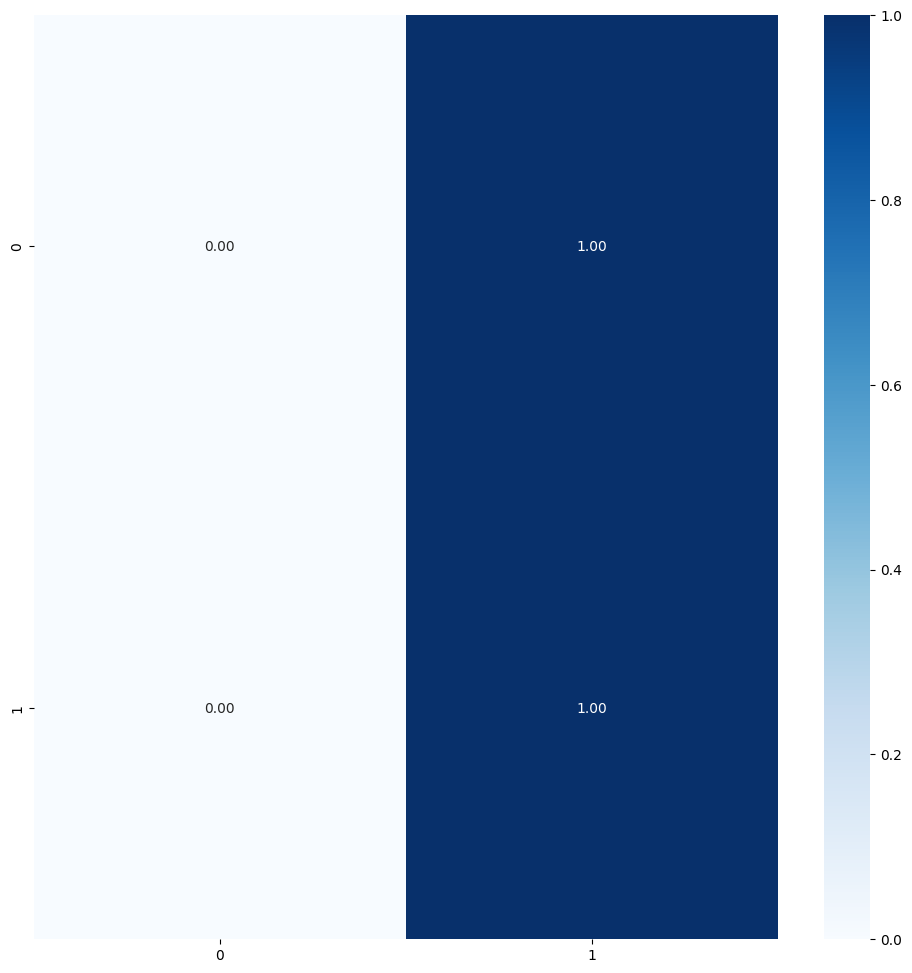

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3756738
Trainable params: 2115074
Non-trainable params: 1641664
Epoch 1/50
65/65 [==============================] - 9s 87ms/step - loss: 6.5526 - accuracy: 0.4889 - val_loss: 5.6438 - val_accuracy: 0.5022
Epoch 2/50
65/65 [==============================] - 5s 78ms/step - loss: 4.9274 - accuracy: 0.4932 - val_loss: 4.2566 - val_accuracy: 0.5022
Epoch 3/50
65/65 [==============================] - 5s 70ms/step - loss: 3.7247 - accuracy: 0.5000 - val_loss: 3.2331 - val_accuracy: 0.4978
Epoch 4/50
65/65 [==============================] - 5s 71ms/step - loss: 2.8434 - accuracy: 0.4807 - val_loss: 2.4824 - val_accuracy: 0.4978
Epoch 5/50
65/65 [==============================] - 5s 72ms/step - loss: 2.1977 - accuracy: 0.4937 - val_loss: 1.9369 - val_accuracy: 0.5000
Epoch 6/50
65/65 [==============================] - 5s 73ms/step - loss: 1.7325 - accuracy: 0.5000 - val_loss: 1.5451 - val_accuracy: 0.5000
Epoch 7/50
65/65 [====================

Model and History saved...
66/66 [==============================] - 9s 132ms/step - loss: 0.6931 - accuracy: 0.5000
Train Accuracy: 0.5
Train Log Loss: 0.693148136138916
15/15 [==============================] - 2s 121ms/step - loss: 0.6931 - accuracy: 0.5000
Validation Accuracy: 0.5
Validation Log Loss: 0.6931477189064026
15/15 [==============================] - 2s 127ms/step - loss: 0.6931 - accuracy: 0.5000
Test Accuracy: 0.5
Test Log Loss: 0.6931477189064026
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[  0 225]
 [  0 225]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.50      1.00      0.67       225

    accuracy                           0.50       450
   macro avg       0.25      0.50      0.33       450
weighted avg       0.25      0.50      0.33       450



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


15/15 [==============================] - 4s 121ms/step


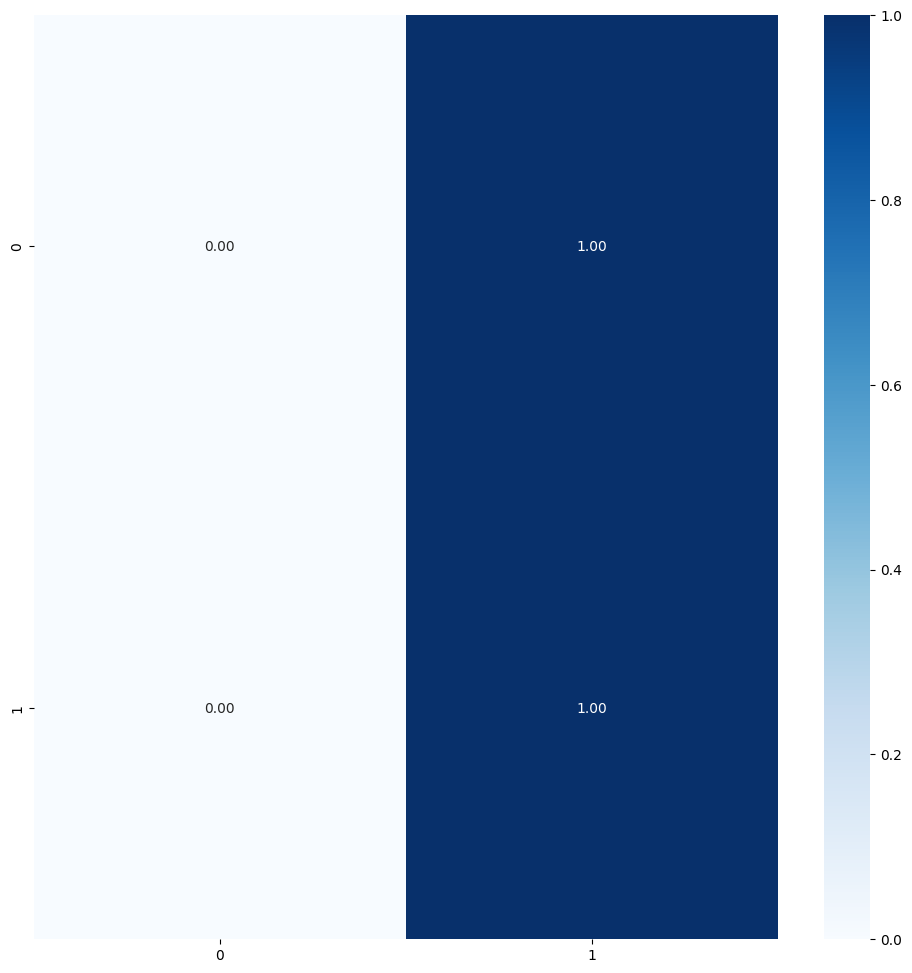

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3756738
Trainable params: 2115074
Non-trainable params: 1641664
Epoch 1/50
65/65 [==============================] - 17s 142ms/step - loss: 6.5585 - accuracy: 0.4918 - val_loss: 5.6499 - val_accuracy: 0.4978
Epoch 2/50
65/65 [==============================] - 9s 143ms/step - loss: 4.9286 - accuracy: 0.4995 - val_loss: 4.2612 - val_accuracy: 0.5022
Epoch 3/50
65/65 [==============================] - 9s 132ms/step - loss: 3.7320 - accuracy: 0.4865 - val_loss: 3.2364 - val_accuracy: 0.5022
Epoch 4/50
65/65 [==============================] - 10s 150ms/step - loss: 2.8459 - accuracy: 0.4773 - val_loss: 2.4847 - val_accuracy: 0.5022
Epoch 5/50
65/65 [==============================] - 9s 141ms/step - loss: 2.2010 - accuracy: 0.4840 - val_loss: 1.9384 - val_accuracy: 0.4978
Epoch 6/50
65/65 [==============================] - 10s 147ms/step - loss: 1.7337 - accuracy: 0.4845 - val_loss: 1.5461 - val_accuracy: 0.5022
Epoch 7/50
65/65 [===========

Model and History saved...
66/66 [==============================] - 8s 126ms/step - loss: 0.6932 - accuracy: 0.5000
Train Accuracy: 0.5
Train Log Loss: 0.6931571364402771
15/15 [==============================] - 2s 124ms/step - loss: 0.6932 - accuracy: 0.5000
Validation Accuracy: 0.5
Validation Log Loss: 0.6931572556495667
15/15 [==============================] - 2s 124ms/step - loss: 0.6932 - accuracy: 0.5000
Test Accuracy: 0.5
Test Log Loss: 0.6931571960449219
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [225   0]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       225
           1       0.00      0.00      0.00       225

    accuracy                           0.50       450
   macro avg       0.25      0.50      0.33       450
weighted avg       0.25      0.50      0.33       450



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


15/15 [==============================] - 3s 117ms/step


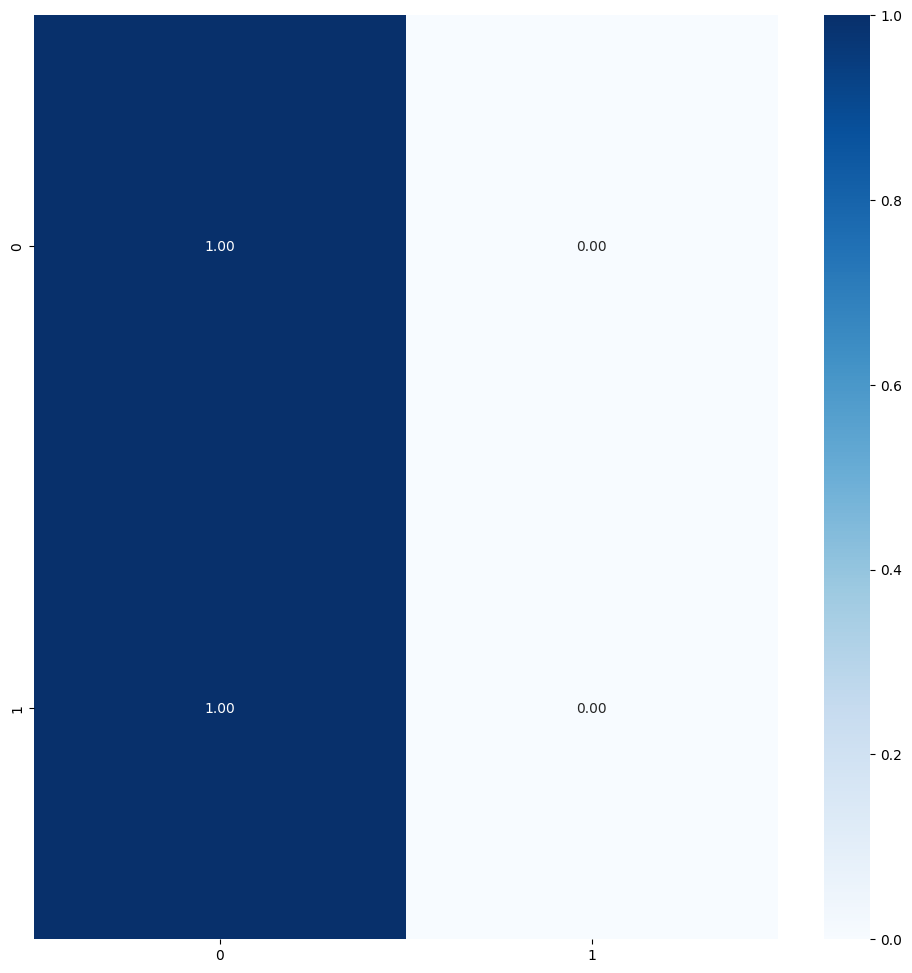

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3756738
Trainable params: 2115074
Non-trainable params: 1641664
Epoch 1/50
65/65 [==============================] - 21s 186ms/step - loss: 6.5601 - accuracy: 0.4947 - val_loss: 5.6502 - val_accuracy: 0.5022
Epoch 2/50
65/65 [==============================] - 10s 158ms/step - loss: 4.9338 - accuracy: 0.4889 - val_loss: 4.2610 - val_accuracy: 0.4978
Epoch 3/50
65/65 [==============================] - 10s 155ms/step - loss: 3.7278 - accuracy: 0.4956 - val_loss: 3.2360 - val_accuracy: 0.5000
Epoch 4/50
65/65 [==============================] - 11s 175ms/step - loss: 2.8480 - accuracy: 0.4923 - val_loss: 2.4842 - val_accuracy: 0.4978
Epoch 5/50
65/65 [==============================] - 10s 149ms/step - loss: 2.2016 - accuracy: 0.4990 - val_loss: 1.9381 - val_accuracy: 0.5000
Epoch 6/50
65/65 [==============================] - 7s 109ms/step - loss: 1.7333 - accuracy: 0.5044 - val_loss: 1.5459 - val_accuracy: 0.5000
Epoch 7/50
65/65 [=========

Model and History saved...
66/66 [==============================] - 7s 97ms/step - loss: 0.6932 - accuracy: 0.5000
Train Accuracy: 0.5
Train Log Loss: 0.6931557059288025
15/15 [==============================] - 2s 102ms/step - loss: 0.6932 - accuracy: 0.5000
Validation Accuracy: 0.5
Validation Log Loss: 0.6931554675102234
15/15 [==============================] - 2s 117ms/step - loss: 0.6932 - accuracy: 0.5000
Test Accuracy: 0.5
Test Log Loss: 0.6931555271148682
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [225   0]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       225
           1       0.00      0.00      0.00       225

    accuracy                           0.50       450
   macro avg       0.25      0.50      0.33       450
weighted avg       0.25      0.50      0.33       450



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


15/15 [==============================] - 3s 100ms/step


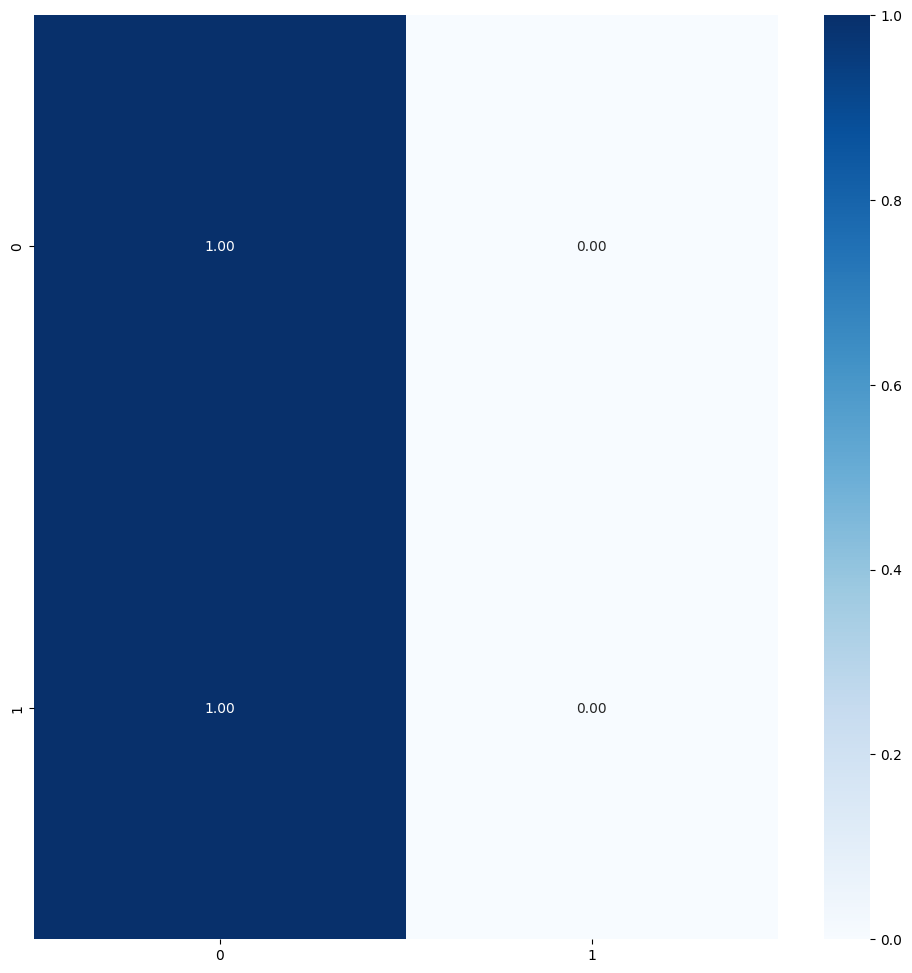

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3756738
Trainable params: 2115074
Non-trainable params: 1641664
Epoch 1/50
65/65 [==============================] - 18s 174ms/step - loss: 6.5502 - accuracy: 0.4855 - val_loss: 5.6432 - val_accuracy: 0.5000
Epoch 2/50
65/65 [==============================] - 9s 143ms/step - loss: 4.9236 - accuracy: 0.4923 - val_loss: 4.2556 - val_accuracy: 0.5000
Epoch 3/50
65/65 [==============================] - 10s 158ms/step - loss: 3.7262 - accuracy: 0.5019 - val_loss: 3.2319 - val_accuracy: 0.5000
Epoch 4/50
65/65 [==============================] - 12s 179ms/step - loss: 2.8430 - accuracy: 0.5019 - val_loss: 2.4812 - val_accuracy: 0.5022
Epoch 5/50
65/65 [==============================] - 11s 166ms/step - loss: 2.1993 - accuracy: 0.4918 - val_loss: 1.9359 - val_accuracy: 0.5000
Epoch 6/50
65/65 [==============================] - 11s 162ms/step - loss: 1.7321 - accuracy: 0.4985 - val_loss: 1.5444 - val_accuracy: 0.5000
Epoch 7/50
65/65 [=========

Model and History saved...
66/66 [==============================] - 8s 123ms/step - loss: 0.6931 - accuracy: 0.5000
Train Accuracy: 0.5
Train Log Loss: 0.6931477189064026
15/15 [==============================] - 2s 127ms/step - loss: 0.6931 - accuracy: 0.5000
Validation Accuracy: 0.5
Validation Log Loss: 0.6931476593017578
15/15 [==============================] - 2s 127ms/step - loss: 0.6931 - accuracy: 0.5000
Test Accuracy: 0.5
Test Log Loss: 0.6931476593017578
Test labels: {'sfone': 0, 'sillyp2p': 1}

Matriz de Confusión:
[[225   0]
 [225   0]]
True labels: 450
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67       225
           1       0.00      0.00      0.00       225

    accuracy                           0.50       450
   macro avg       0.25      0.50      0.33       450
weighted avg       0.25      0.50      0.33       450



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


15/15 [==============================] - 4s 135ms/step


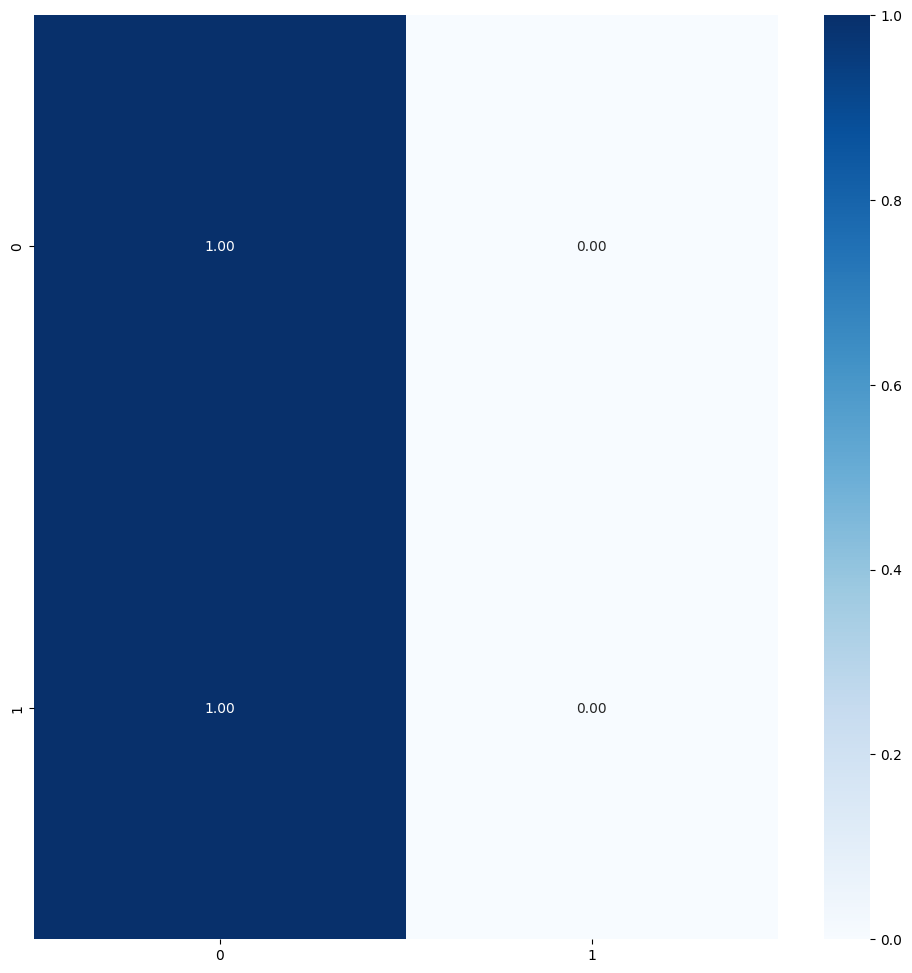

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.5147969126701355
Average validation precision in 5-fold: 0.5022321343421936
/nTest Metrics
test_acc_list: [0.5, 0.5, 0.5, 0.5, 0.5]
Average Test Accuracy with 5-fold: 0.5
test_loss_list: [0.6931530833244324, 0.6931477189064026, 0.6931571960449219, 0.6931555271148682, 0.6931476593017578]
Average Test Log Loss with 5-fold: 0.6931522369384766

Precision List: [0.25, 0.25, 0.25, 0.25, 0.25]
Average Precision List with 5-fold: 0.25
Recall List: [0.5, 0.5, 0.5, 0.5, 0.5]
Average Recall List with 5-fold: 0.5
F1 Score List: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Average F1 Score List with 5-fold: 0.3333333333333333

Metrics List Store

test_acc_list_all = [0.5]
test_loss_list_all = [0.6931522369384766]
precision_list_all = [0.25]
recall_list_all = [0.5]
f1_score_list_all = [0.3333333333333333]
La carpeta 2 fue eliminada.
CPU times: user 49min 12s, sys: 5min 20s, total: 54min 33s
Wall time: 44mi

In [19]:
%%time

num_classes = 2
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/3
name_save_model: fusion_VGG16_basic_3
Found 3150 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Found 675 images belonging to 3 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3757251
Trainable params: 2115587
Non-trainable params: 1641664
Epoch 1/50
98/98 [==============================] - 24s 178ms/step - loss: 6.5392 - accuracy: 0.3198 - val_loss: 5.3120 - val_accuracy: 0.3348
Epoch 2/50
98/98 [==============================] - 16s 163ms/step - loss: 4.4186 - accuracy: 0.3239 - val_loss: 3.6377 - val_accuracy: 0.3333
Epoch 3/50
98/98 [==============================] - 18s 185ms/step - loss: 3.0782 - accuracy: 0.3303 - val_loss: 2.5881 - val_accuracy: 0.3333
Epoch 4/50
98/98 [==============================] - 16s 166ms/step - loss: 2.2424 - accuracy: 0.3191 - val_loss: 1.9450 - val_accuracy: 0.3333
Epoc

Model and History saved...
99/99 [==============================] - 9s 92ms/step - loss: 1.0986 - accuracy: 0.3333
Train Accuracy: 0.3333333432674408
Train Log Loss: 1.0986137390136719
22/22 [==============================] - 3s 132ms/step - loss: 1.0986 - accuracy: 0.3333
Validation Accuracy: 0.3333333432674408
Validation Log Loss: 1.0986138582229614
22/22 [==============================] - 2s 88ms/step - loss: 1.0986 - accuracy: 0.3333
Test Accuracy: 0.3333333432674408
Test Log Loss: 1.0986137390136719
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[  0 225   0]
 [  0 225   0]
 [  0 225   0]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.33      1.00      0.50       225
           2       0.00      0.00      0.00       225

    accuracy                           0.33       675
   macro avg

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


22/22 [==============================] - 3s 88ms/step


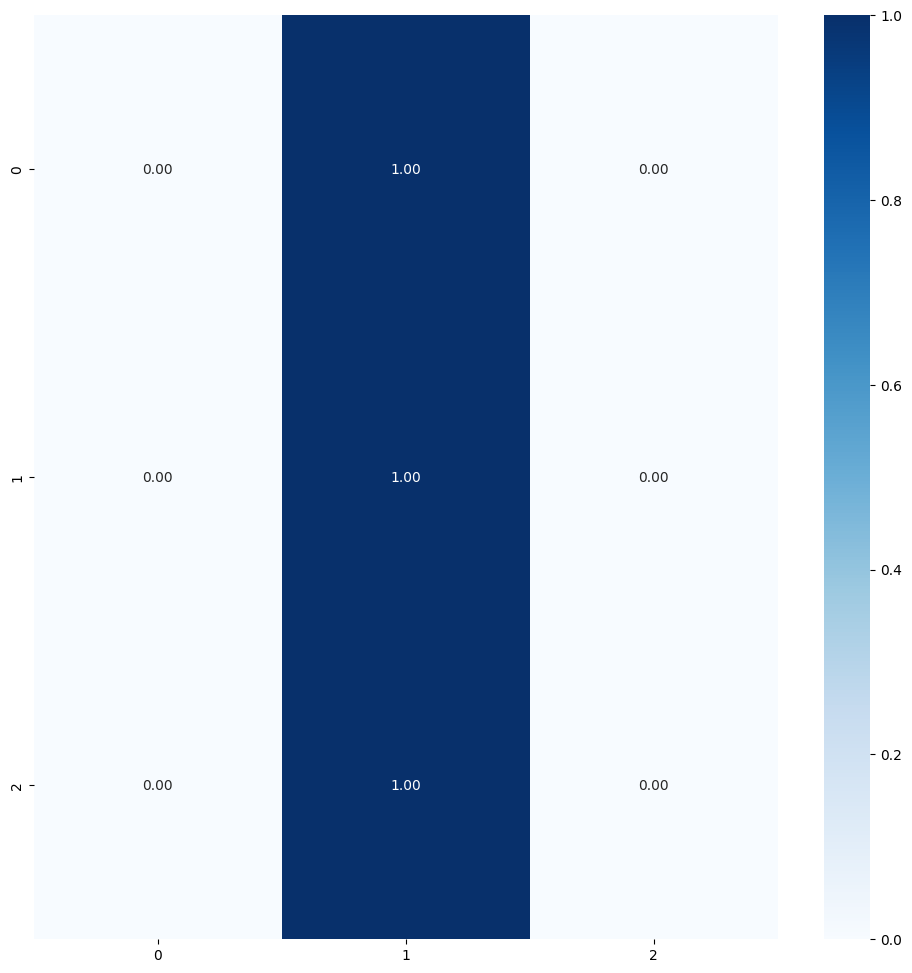

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3757251
Trainable params: 2115587
Non-trainable params: 1641664
Epoch 1/50
98/98 [==============================] - 25s 194ms/step - loss: 6.5320 - accuracy: 0.3162 - val_loss: 5.2951 - val_accuracy: 0.3348
Epoch 2/50
98/98 [==============================] - 17s 169ms/step - loss: 4.4069 - accuracy: 0.3210 - val_loss: 3.6262 - val_accuracy: 0.3333
Epoch 3/50
98/98 [==============================] - 16s 163ms/step - loss: 3.0688 - accuracy: 0.3348 - val_loss: 2.5807 - val_accuracy: 0.3333
Epoch 4/50
98/98 [==============================] - 16s 164ms/step - loss: 2.2370 - accuracy: 0.3339 - val_loss: 1.9404 - val_accuracy: 0.3333
Epoch 5/50
98/98 [==============================] - 11s 110ms/step - loss: 1.7357 - accuracy: 0.3284 - val_loss: 1.5598 - val_accuracy: 0.3333
Epoch 6/50
98/98 [==============================] - 16s 165ms/step - loss: 1.4417 - accuracy: 0.3329 - val_loss: 1.3414 - val_accuracy: 0.3348
Epoch 7/50
98/98 [========

Model and History saved...
99/99 [==============================] - 13s 124ms/step - loss: 1.0986 - accuracy: 0.3333
Train Accuracy: 0.3333333432674408
Train Log Loss: 1.0986133813858032
22/22 [==============================] - 3s 120ms/step - loss: 1.0986 - accuracy: 0.3333
Validation Accuracy: 0.3333333432674408
Validation Log Loss: 1.0986135005950928
22/22 [==============================] - 3s 127ms/step - loss: 1.0986 - accuracy: 0.3333
Test Accuracy: 0.3333333432674408
Test Log Loss: 1.0986137390136719
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[  0   0 225]
 [  0   0 225]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.00      0.00      0.00       225
           2       0.33      1.00      0.50       225

    accuracy                           0.33       675
   macro 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


22/22 [==============================] - 4s 118ms/step


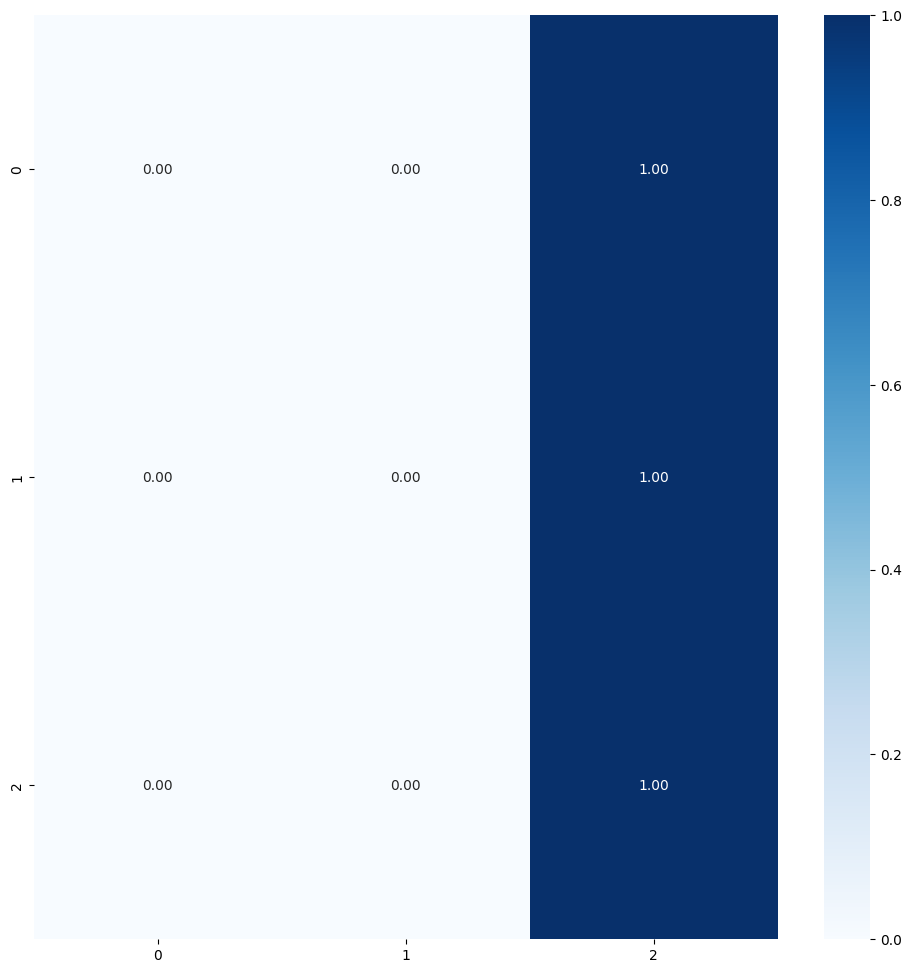

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3757251
Trainable params: 2115587
Non-trainable params: 1641664
Epoch 1/50
98/98 [==============================] - 26s 174ms/step - loss: 6.5358 - accuracy: 0.3239 - val_loss: 5.2993 - val_accuracy: 0.3333
Epoch 2/50
98/98 [==============================] - 10s 103ms/step - loss: 4.4072 - accuracy: 0.3313 - val_loss: 3.6289 - val_accuracy: 0.3318
Epoch 3/50
98/98 [==============================] - 15s 152ms/step - loss: 3.0719 - accuracy: 0.3258 - val_loss: 2.5824 - val_accuracy: 0.3333
Epoch 4/50
98/98 [==============================] - 15s 154ms/step - loss: 2.2384 - accuracy: 0.3332 - val_loss: 1.9414 - val_accuracy: 0.3348
Epoch 5/50
98/98 [==============================] - 15s 148ms/step - loss: 1.7365 - accuracy: 0.3384 - val_loss: 1.5603 - val_accuracy: 0.3318
Epoch 6/50
98/98 [==============================] - 14s 138ms/step - loss: 1.4420 - accuracy: 0.3265 - val_loss: 1.3417 - val_accuracy: 0.3348
Epoch 7/50
98/98 [========

Model and History saved...
99/99 [==============================] - 12s 119ms/step - loss: 1.0986 - accuracy: 0.3333
Train Accuracy: 0.3333333432674408
Train Log Loss: 1.0986196994781494
22/22 [==============================] - 3s 126ms/step - loss: 1.0986 - accuracy: 0.3333
Validation Accuracy: 0.3333333432674408
Validation Log Loss: 1.0986196994781494
22/22 [==============================] - 3s 128ms/step - loss: 1.0986 - accuracy: 0.3333
Test Accuracy: 0.3333333432674408
Test Log Loss: 1.0986199378967285
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[  0 225   0]
 [  0 225   0]
 [  0 225   0]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.33      1.00      0.50       225
           2       0.00      0.00      0.00       225

    accuracy                           0.33       675
   macro 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


22/22 [==============================] - 4s 123ms/step


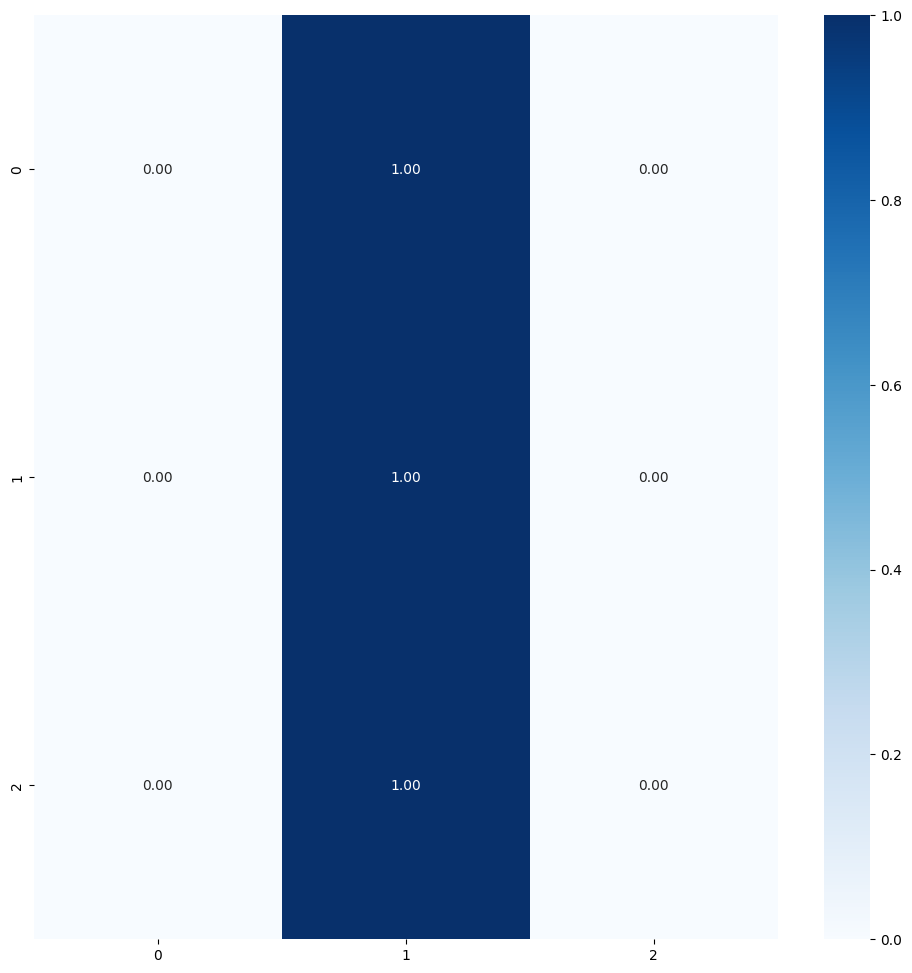

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3757251
Trainable params: 2115587
Non-trainable params: 1641664
Epoch 1/50
98/98 [==============================] - 26s 171ms/step - loss: 6.5431 - accuracy: 0.3294 - val_loss: 5.3133 - val_accuracy: 0.3333
Epoch 2/50
98/98 [==============================] - 11s 112ms/step - loss: 4.4246 - accuracy: 0.3198 - val_loss: 3.6396 - val_accuracy: 0.3333
Epoch 3/50
98/98 [==============================] - 13s 134ms/step - loss: 3.0779 - accuracy: 0.3300 - val_loss: 2.5901 - val_accuracy: 0.3333
Epoch 4/50
98/98 [==============================] - 15s 152ms/step - loss: 2.2444 - accuracy: 0.3297 - val_loss: 1.9467 - val_accuracy: 0.3304
Epoch 5/50
98/98 [==============================] - 15s 148ms/step - loss: 1.7412 - accuracy: 0.3207 - val_loss: 1.5637 - val_accuracy: 0.3333
Epoch 6/50
98/98 [==============================] - 14s 139ms/step - loss: 1.4445 - accuracy: 0.3265 - val_loss: 1.3438 - val_accuracy: 0.3333
Epoch 7/50
98/98 [========

Model and History saved...
99/99 [==============================] - 11s 113ms/step - loss: 1.0986 - accuracy: 0.3333
Train Accuracy: 0.3333333432674408
Train Log Loss: 1.098619818687439
22/22 [==============================] - 3s 108ms/step - loss: 1.0986 - accuracy: 0.3333
Validation Accuracy: 0.3333333432674408
Validation Log Loss: 1.0986194610595703
22/22 [==============================] - 3s 107ms/step - loss: 1.0986 - accuracy: 0.3333
Test Accuracy: 0.3333333432674408
Test Log Loss: 1.0986196994781494
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[  0   0 225]
 [  0   0 225]
 [  0   0 225]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.00      0.00      0.00       225
           2       0.33      1.00      0.50       225

    accuracy                           0.33       675
   macro a

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


22/22 [==============================] - 4s 105ms/step


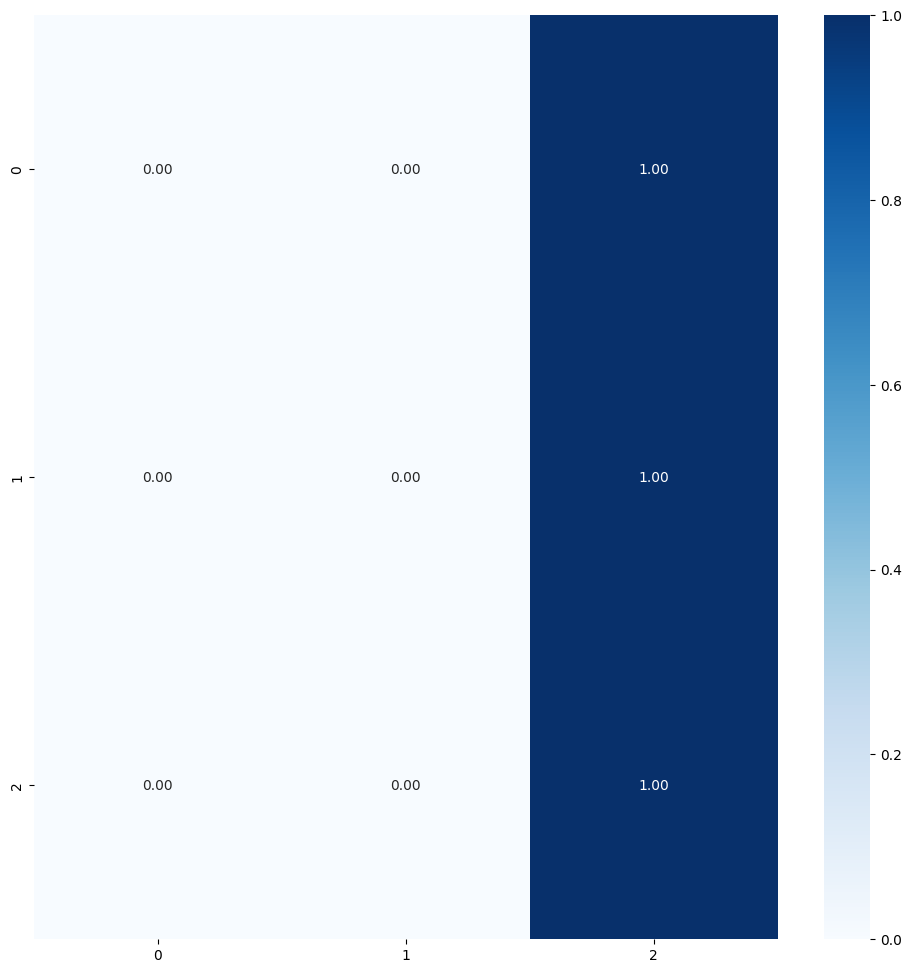

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3757251
Trainable params: 2115587
Non-trainable params: 1641664
Epoch 1/50
98/98 [==============================] - 22s 138ms/step - loss: 6.5278 - accuracy: 0.3303 - val_loss: 5.2978 - val_accuracy: 0.3348
Epoch 2/50
98/98 [==============================] - 13s 130ms/step - loss: 4.4115 - accuracy: 0.3092 - val_loss: 3.6283 - val_accuracy: 0.3348
Epoch 3/50
98/98 [==============================] - 15s 155ms/step - loss: 3.0697 - accuracy: 0.3323 - val_loss: 2.5823 - val_accuracy: 0.3333
Epoch 4/50
98/98 [==============================] - 15s 153ms/step - loss: 2.2369 - accuracy: 0.3303 - val_loss: 1.9415 - val_accuracy: 0.3304
Epoch 5/50
98/98 [==============================] - 15s 157ms/step - loss: 1.7367 - accuracy: 0.3082 - val_loss: 1.5605 - val_accuracy: 0.3318
Epoch 6/50
98/98 [==============================] - 15s 153ms/step - loss: 1.4423 - accuracy: 0.3339 - val_loss: 1.3418 - val_accuracy: 0.3348
Epoch 7/50
98/98 [========

Model and History saved...
99/99 [==============================] - 7s 69ms/step - loss: 1.0986 - accuracy: 0.3333
Train Accuracy: 0.3333333432674408
Train Log Loss: 1.0986275672912598
22/22 [==============================] - 1s 58ms/step - loss: 1.0986 - accuracy: 0.3333
Validation Accuracy: 0.3333333432674408
Validation Log Loss: 1.0986278057098389
22/22 [==============================] - 3s 118ms/step - loss: 1.0986 - accuracy: 0.3333
Test Accuracy: 0.3333333432674408
Test Log Loss: 1.0986278057098389
Test labels: {'Allaple.A': 0, 'sfone': 1, 'sillyp2p': 2}

Matriz de Confusión:
[[  0 225   0]
 [  0 225   0]
 [  0 225   0]]
True labels: 675
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.33      1.00      0.50       225
           2       0.00      0.00      0.00       225

    accuracy                           0.33       675
   macro avg

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


22/22 [==============================] - 4s 115ms/step


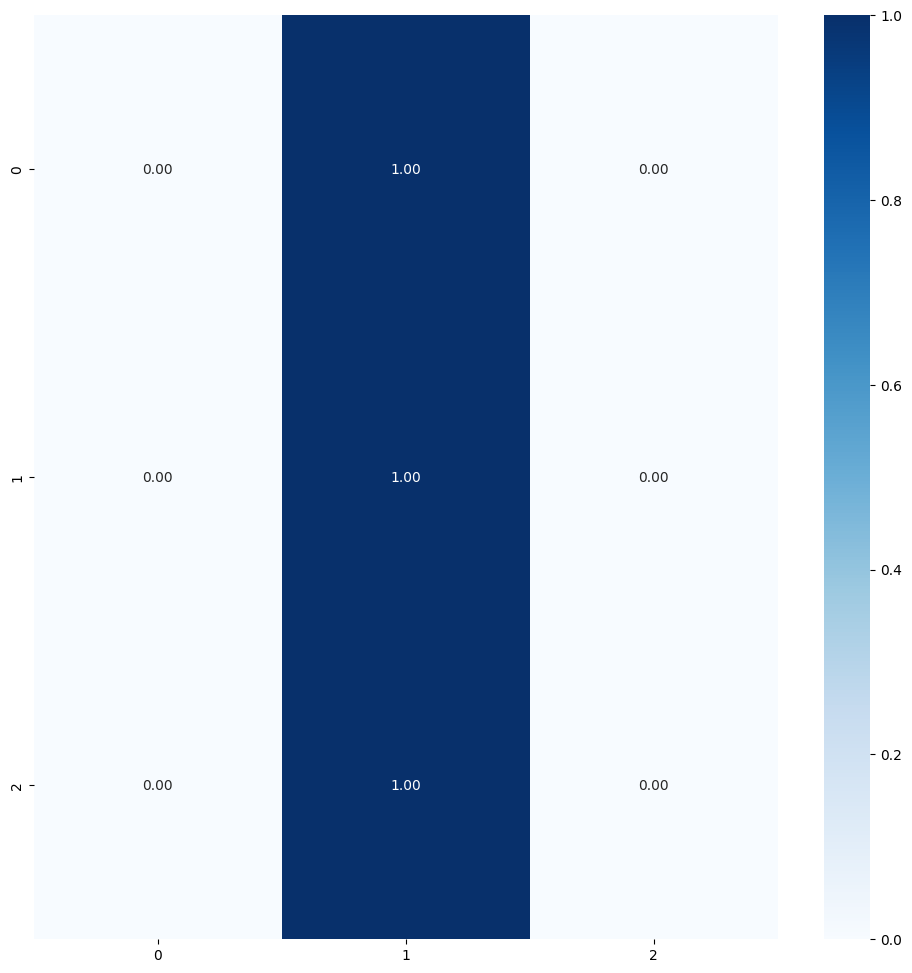

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.34169339537620547
Average validation precision in 5-fold: 0.3348214328289032
/nTest Metrics
test_acc_list: [0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408, 0.3333333432674408]
Average Test Accuracy with 5-fold: 0.3333333432674408
test_loss_list: [1.0986137390136719, 1.0986137390136719, 1.0986199378967285, 1.0986196994781494, 1.0986278057098389]
Average Test Log Loss with 5-fold: 1.098618984222412

Precision List: [0.1111111111111111, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111]
Average Precision List with 5-fold: 0.11111111111111112
Recall List: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Average Recall List with 5-fold: 0.3333333333333333
F1 Score List: [0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]
Average F1 Score List with 5-fold: 0.16666666666666666

Metrics List

In [20]:
%%time

num_classes = 3
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/4
name_save_model: fusion_VGG16_basic_4
Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3757764
Trainable params: 2116100
Non-trainable params: 1641664
Epoch 1/50
131/131 [==============================] - 33s 181ms/step - loss: 6.4412 - accuracy: 0.2397 - val_loss: 4.9515 - val_accuracy: 0.2500
Epoch 2/50
131/131 [==============================] - 19s 148ms/step - loss: 3.9770 - accuracy: 0.2409 - val_loss: 3.1663 - val_accuracy: 0.2500
Epoch 3/50
131/131 [==============================] - 18s 138ms/step - loss: 2.6493 - accuracy: 0.2430 - val_loss: 2.2281 - val_accuracy: 0.2511
Epoch 4/50
131/131 [==============================] - 18s 137ms/step - loss: 1.9661 - accuracy: 0.2486 - val_loss: 1.7595 - val_accu

Model and History saved...
132/132 [==============================] - 17s 126ms/step - loss: 1.3863 - accuracy: 0.2500
Train Accuracy: 0.25
Train Log Loss: 1.3862954378128052
29/29 [==============================] - 5s 166ms/step - loss: 1.3863 - accuracy: 0.2500
Validation Accuracy: 0.25
Validation Log Loss: 1.3862956762313843
29/29 [==============================] - 4s 127ms/step - loss: 1.3863 - accuracy: 0.2500
Test Accuracy: 0.25
Test Log Loss: 1.3862957954406738
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[  0   0 225   0]
 [  0   0 225   0]
 [  0   0 225   0]
 [  0   0 225   0]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.00      0.00      0.00       225
           2       0.25      1.00      0.40       225
           3       0.00      0.00      0.00       225

    a

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


29/29 [==============================] - 5s 128ms/step


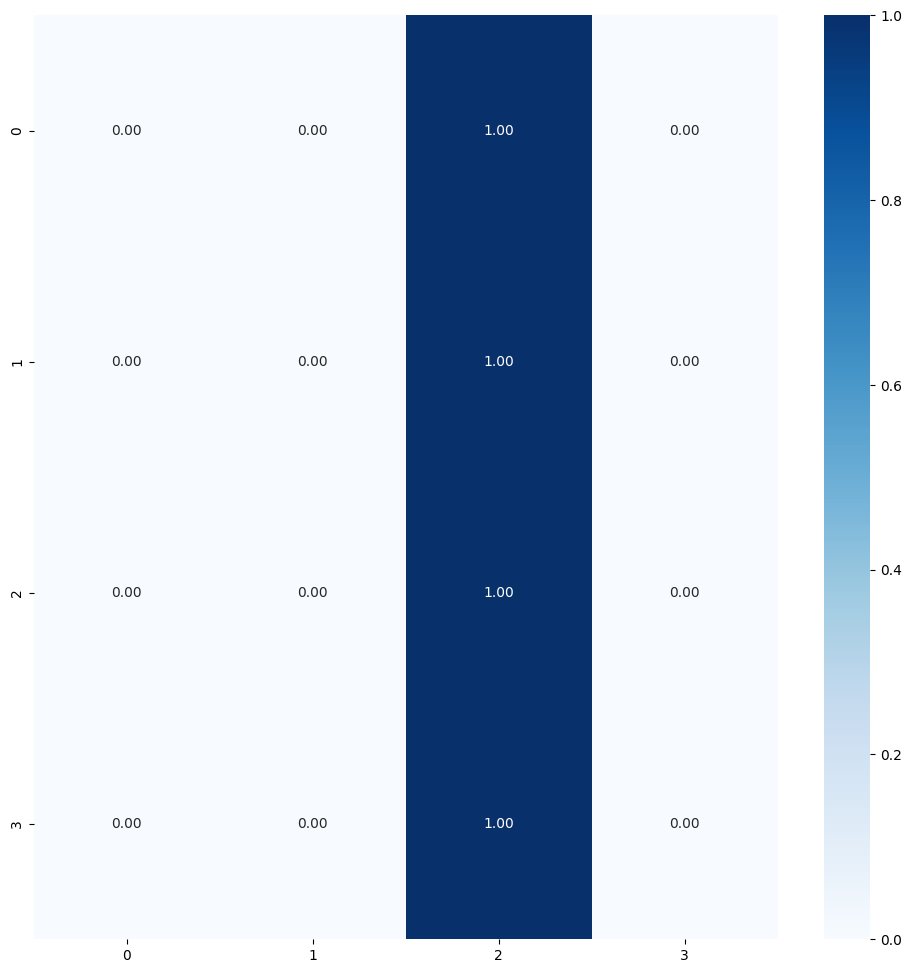

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3757764
Trainable params: 2116100
Non-trainable params: 1641664
Epoch 1/50
131/131 [==============================] - 34s 185ms/step - loss: 6.4213 - accuracy: 0.2430 - val_loss: 4.9367 - val_accuracy: 0.2511
Epoch 2/50
131/131 [==============================] - 15s 116ms/step - loss: 3.9571 - accuracy: 0.2445 - val_loss: 3.1588 - val_accuracy: 0.2500
Epoch 3/50
131/131 [==============================] - 21s 160ms/step - loss: 2.6449 - accuracy: 0.2488 - val_loss: 2.2248 - val_accuracy: 0.2500
Epoch 4/50
131/131 [==============================] - 21s 160ms/step - loss: 1.9647 - accuracy: 0.2445 - val_loss: 1.7582 - val_accuracy: 0.2500
Epoch 5/50
131/131 [==============================] - 20s 155ms/step - loss: 1.6360 - accuracy: 0.2430 - val_loss: 1.5396 - val_accuracy: 0.2478
Epoch 6/50
131/131 [==============================] - 20s 151ms/step - loss: 1.4855 - accuracy: 0.2346 - val_loss: 1.4446 - val_accuracy: 0.2489
Epoch 7/50
131

Model and History saved...
132/132 [==============================] - 17s 127ms/step - loss: 1.3863 - accuracy: 0.2500
Train Accuracy: 0.25
Train Log Loss: 1.3862991333007812
29/29 [==============================] - 4s 137ms/step - loss: 1.3863 - accuracy: 0.2500
Validation Accuracy: 0.25
Validation Log Loss: 1.3862996101379395
29/29 [==============================] - 4s 142ms/step - loss: 1.3863 - accuracy: 0.2500
Test Accuracy: 0.25
Test Log Loss: 1.3862992525100708
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[  0   0   0 225]
 [  0   0   0 225]
 [  0   0   0 225]
 [  0   0   0 225]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.00      0.00      0.00       225
           2       0.00      0.00      0.00       225
           3       0.25      1.00      0.40       225

    a

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


29/29 [==============================] - 6s 134ms/step


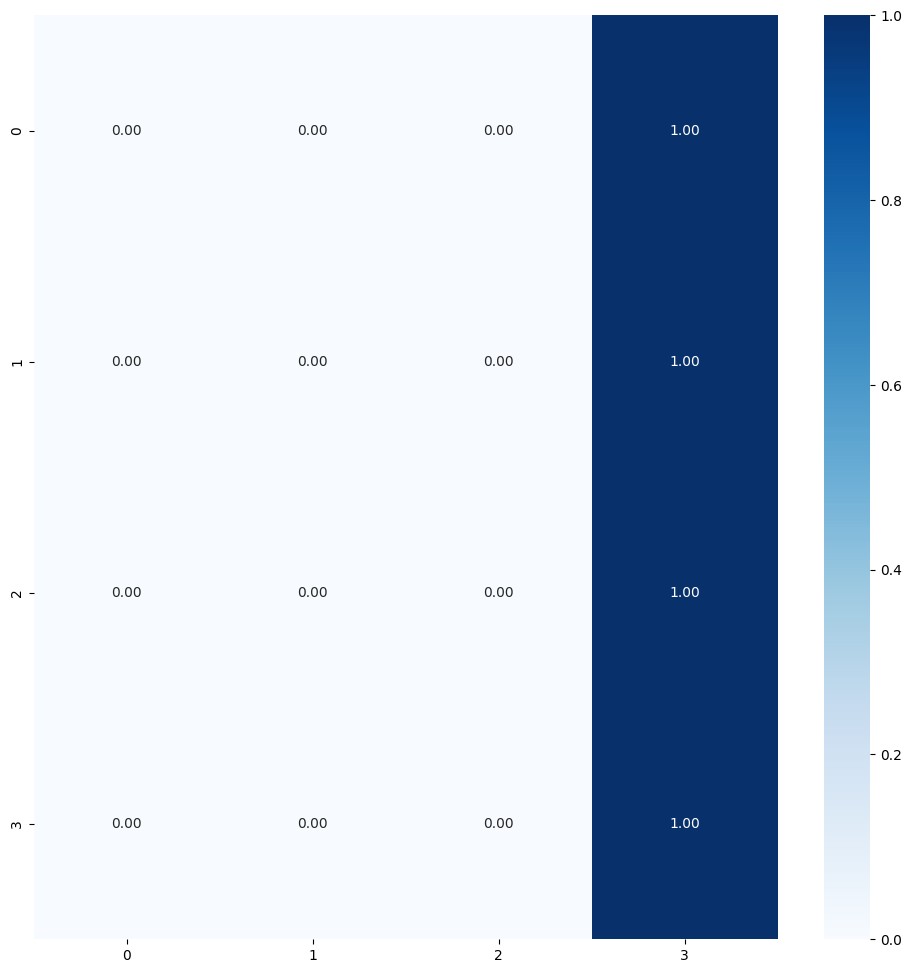

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3757764
Trainable params: 2116100
Non-trainable params: 1641664
Epoch 1/50
131/131 [==============================] - 36s 192ms/step - loss: 6.4202 - accuracy: 0.2462 - val_loss: 4.9370 - val_accuracy: 0.2511
Epoch 2/50
131/131 [==============================] - 20s 153ms/step - loss: 3.9639 - accuracy: 0.2442 - val_loss: 3.1585 - val_accuracy: 0.2500
Epoch 3/50
131/131 [==============================] - 20s 152ms/step - loss: 2.6449 - accuracy: 0.2382 - val_loss: 2.2243 - val_accuracy: 0.2511
Epoch 4/50
131/131 [==============================] - 21s 161ms/step - loss: 1.9650 - accuracy: 0.2486 - val_loss: 1.7578 - val_accuracy: 0.2500
Epoch 5/50
131/131 [==============================] - 20s 151ms/step - loss: 1.6354 - accuracy: 0.2454 - val_loss: 1.5394 - val_accuracy: 0.2500
Epoch 6/50
131/131 [==============================] - 20s 154ms/step - loss: 1.4855 - accuracy: 0.2502 - val_loss: 1.4445 - val_accuracy: 0.2511
Epoch 7/50
131

Model and History saved...
132/132 [==============================] - 17s 129ms/step - loss: 1.3863 - accuracy: 0.2500
Train Accuracy: 0.25
Train Log Loss: 1.386301875114441
29/29 [==============================] - 4s 119ms/step - loss: 1.3863 - accuracy: 0.2500
Validation Accuracy: 0.25
Validation Log Loss: 1.3863013982772827
29/29 [==============================] - 4s 126ms/step - loss: 1.3863 - accuracy: 0.2500
Test Accuracy: 0.25
Test Log Loss: 1.3863013982772827
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[  0 225   0   0]
 [  0 225   0   0]
 [  0 225   0   0]
 [  0 225   0   0]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.25      1.00      0.40       225
           2       0.00      0.00      0.00       225
           3       0.00      0.00      0.00       225

    ac

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


29/29 [==============================] - 4s 108ms/step


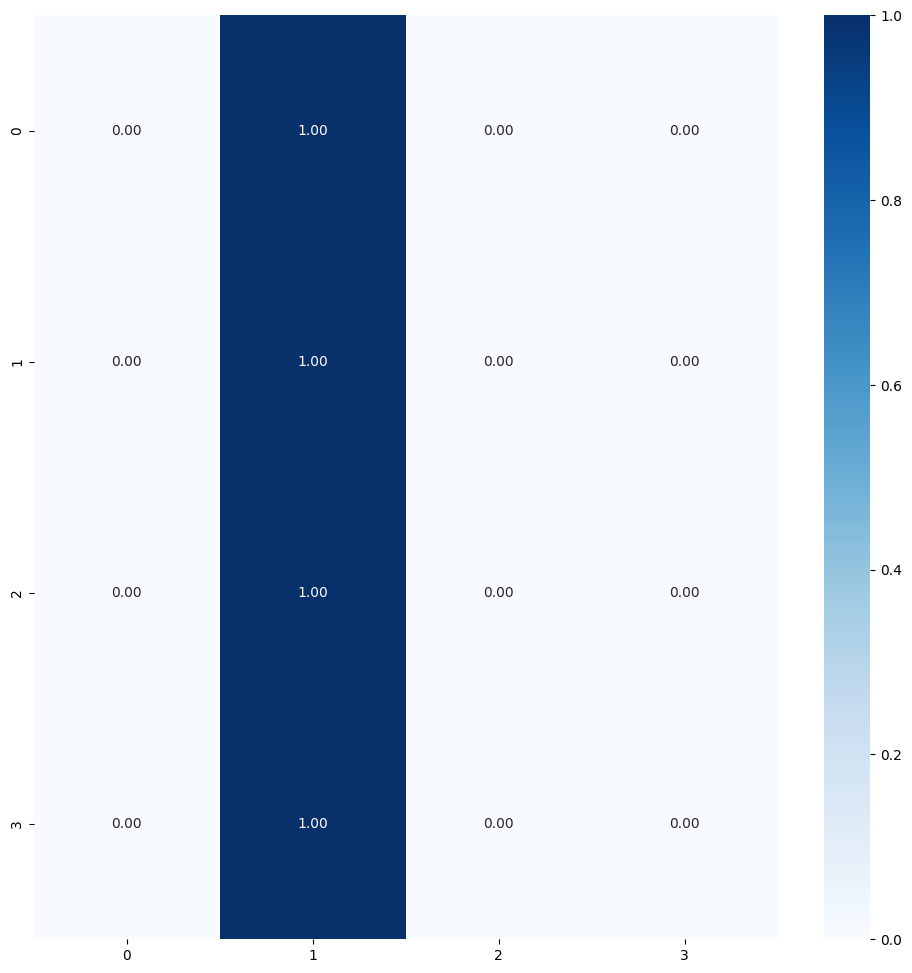

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3757764
Trainable params: 2116100
Non-trainable params: 1641664
Epoch 1/50
131/131 [==============================] - 29s 161ms/step - loss: 6.4245 - accuracy: 0.2378 - val_loss: 4.9387 - val_accuracy: 0.2511
Epoch 2/50
131/131 [==============================] - 15s 115ms/step - loss: 3.9677 - accuracy: 0.2397 - val_loss: 3.1592 - val_accuracy: 0.2489
Epoch 3/50
131/131 [==============================] - 21s 159ms/step - loss: 2.6443 - accuracy: 0.2447 - val_loss: 2.2246 - val_accuracy: 0.2500
Epoch 4/50
131/131 [==============================] - 21s 162ms/step - loss: 1.9664 - accuracy: 0.2354 - val_loss: 1.7581 - val_accuracy: 0.2489
Epoch 5/50
131/131 [==============================] - 21s 164ms/step - loss: 1.6358 - accuracy: 0.2404 - val_loss: 1.5395 - val_accuracy: 0.2511
Epoch 6/50
131/131 [==============================] - 23s 172ms/step - loss: 1.4854 - accuracy: 0.2519 - val_loss: 1.4445 - val_accuracy: 0.2500
Epoch 7/50
131

Model and History saved...
132/132 [==============================] - 12s 93ms/step - loss: 1.3863 - accuracy: 0.2500
Train Accuracy: 0.25
Train Log Loss: 1.3862967491149902
29/29 [==============================] - 3s 91ms/step - loss: 1.3863 - accuracy: 0.2500
Validation Accuracy: 0.25
Validation Log Loss: 1.3862965106964111
29/29 [==============================] - 3s 94ms/step - loss: 1.3863 - accuracy: 0.2500
Test Accuracy: 0.25
Test Log Loss: 1.3862965106964111
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [225   0   0   0]
 [225   0   0   0]
 [225   0   0   0]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.25      1.00      0.40       225
           1       0.00      0.00      0.00       225
           2       0.00      0.00      0.00       225
           3       0.00      0.00      0.00       225

    accu

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


29/29 [==============================] - 4s 88ms/step


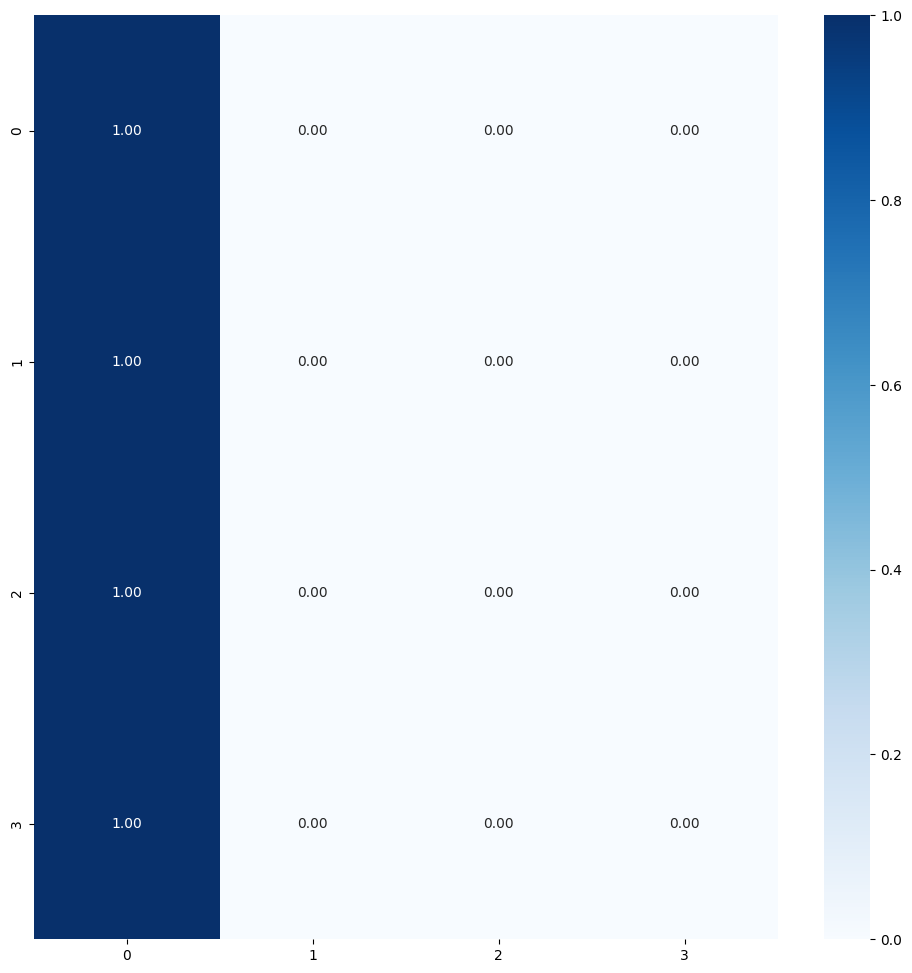

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3757764
Trainable params: 2116100
Non-trainable params: 1641664
Epoch 1/50
131/131 [==============================] - 32s 173ms/step - loss: 6.4387 - accuracy: 0.2346 - val_loss: 4.9448 - val_accuracy: 0.2500
Epoch 2/50
131/131 [==============================] - 20s 149ms/step - loss: 3.9722 - accuracy: 0.2502 - val_loss: 3.1631 - val_accuracy: 0.2500
Epoch 3/50
131/131 [==============================] - 16s 119ms/step - loss: 2.6452 - accuracy: 0.2418 - val_loss: 2.2268 - val_accuracy: 0.2511
Epoch 4/50
131/131 [==============================] - 22s 171ms/step - loss: 1.9673 - accuracy: 0.2421 - val_loss: 1.7591 - val_accuracy: 0.2500
Epoch 5/50
131/131 [==============================] - 21s 156ms/step - loss: 1.6355 - accuracy: 0.2500 - val_loss: 1.5400 - val_accuracy: 0.2511
Epoch 6/50
131/131 [==============================] - 20s 155ms/step - loss: 1.4860 - accuracy: 0.2322 - val_loss: 1.4447 - val_accuracy: 0.2489
Epoch 7/50
131

Model and History saved...
132/132 [==============================] - 18s 135ms/step - loss: 1.3863 - accuracy: 0.2500
Train Accuracy: 0.25
Train Log Loss: 1.386297583580017
29/29 [==============================] - 4s 129ms/step - loss: 1.3863 - accuracy: 0.2500
Validation Accuracy: 0.25
Validation Log Loss: 1.386297345161438
29/29 [==============================] - 4s 119ms/step - loss: 1.3863 - accuracy: 0.2500
Test Accuracy: 0.25
Test Log Loss: 1.3862974643707275
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3}

Matriz de Confusión:
[[225   0   0   0]
 [225   0   0   0]
 [225   0   0   0]
 [225   0   0   0]]
True labels: 900
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.25      1.00      0.40       225
           1       0.00      0.00      0.00       225
           2       0.00      0.00      0.00       225
           3       0.00      0.00      0.00       225

    acc

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


29/29 [==============================] - 6s 145ms/step


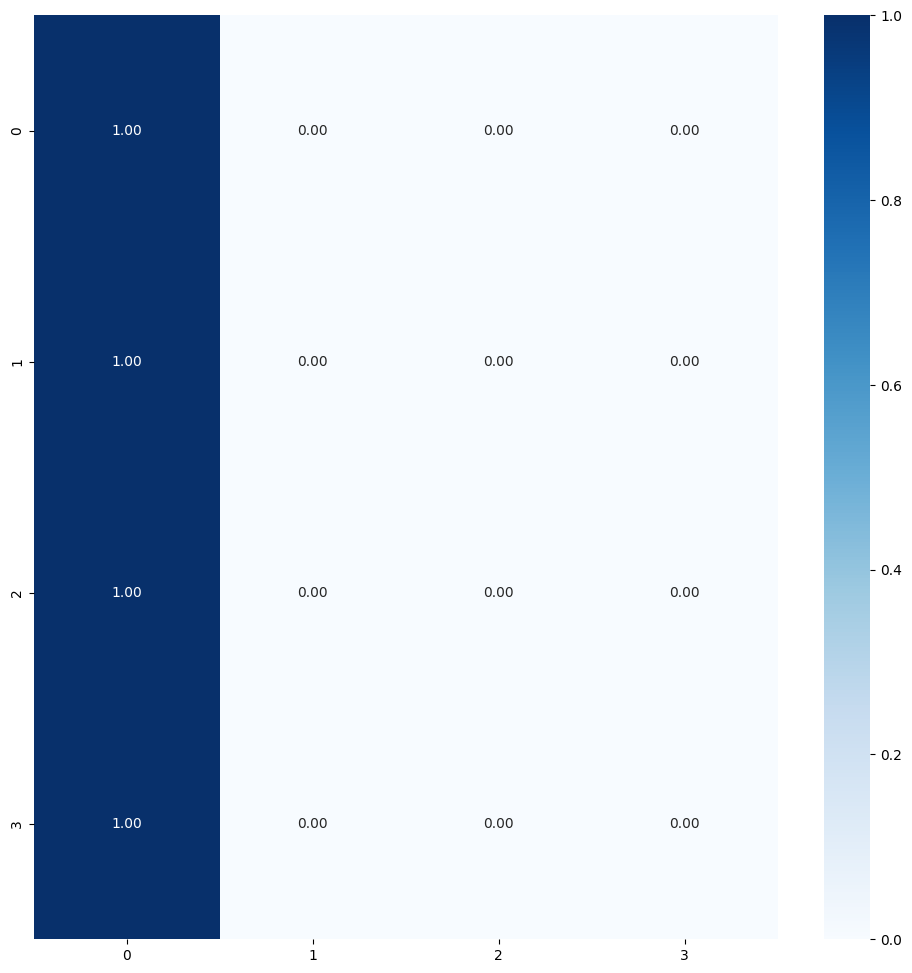

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.25652591586112977
Average validation precision in 5-fold: 0.2511160671710968
/nTest Metrics
test_acc_list: [0.25, 0.25, 0.25, 0.25, 0.25]
Average Test Accuracy with 5-fold: 0.25
test_loss_list: [1.3862957954406738, 1.3862992525100708, 1.3863013982772827, 1.3862965106964111, 1.3862974643707275]
Average Test Log Loss with 5-fold: 1.3862980842590331

Precision List: [0.0625, 0.0625, 0.0625, 0.0625, 0.0625]
Average Precision List with 5-fold: 0.0625
Recall List: [0.25, 0.25, 0.25, 0.25, 0.25]
Average Recall List with 5-fold: 0.25
F1 Score List: [0.1, 0.1, 0.1, 0.1, 0.1]
Average F1 Score List with 5-fold: 0.1

Metrics List Store

test_acc_list_all = [0.5, 0.3333333432674408, 0.25]
test_loss_list_all = [0.6931522369384766, 1.098618984222412, 1.3862980842590331]
precision_list_all = [0.25, 0.11111111111111112, 0.0625]
recall_list_all = [0.5, 0.3333333333333333, 0.25]
f1_score_list_all = [0.3333333333333333, 0.16666666666666666, 0.1]
La carpeta 4 fue elim

In [21]:
%%time

num_classes = 4
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/5
name_save_model: fusion_VGG16_basic_5
Found 5250 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Found 1125 images belonging to 5 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3758277
Trainable params: 2116613
Non-trainable params: 1641664
Epoch 1/50
164/164 [==============================] - 33s 144ms/step - loss: 6.3027 - accuracy: 0.1957 - val_loss: 4.6050 - val_accuracy: 0.2009
Epoch 2/50
164/164 [==============================] - 26s 156ms/step - loss: 3.6130 - accuracy: 0.1945 - val_loss: 2.8346 - val_accuracy: 0.2009
Epoch 3/50
164/164 [==============================] - 23s 138ms/step - loss: 2.3972 - accuracy: 0.1959 - val_loss: 2.0660 - val_accuracy: 0.1991
Epoch 4/50
164/164 [==============================] - 23s 143ms/step - loss: 1.8905 - accuracy: 0.1970 - val_loss: 1.7616 

Model and History saved...
165/165 [==============================] - 18s 108ms/step - loss: 1.6094 - accuracy: 0.2000
Train Accuracy: 0.20000000298023224
Train Log Loss: 1.6094449758529663
36/36 [==============================] - 6s 151ms/step - loss: 1.6094 - accuracy: 0.2000
Validation Accuracy: 0.20000000298023224
Validation Log Loss: 1.6094449758529663
36/36 [==============================] - 5s 122ms/step - loss: 1.6094 - accuracy: 0.2000
Test Accuracy: 0.20000000298023224
Test Log Loss: 1.6094448566436768
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[  0   0   0   0 225]
 [  0   0   0   0 225]
 [  0   0   0   0 225]
 [  0   0   0   0 225]
 [  0   0   0   0 225]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.00      0.00      0.00       225
           2     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


36/36 [==============================] - 6s 125ms/step


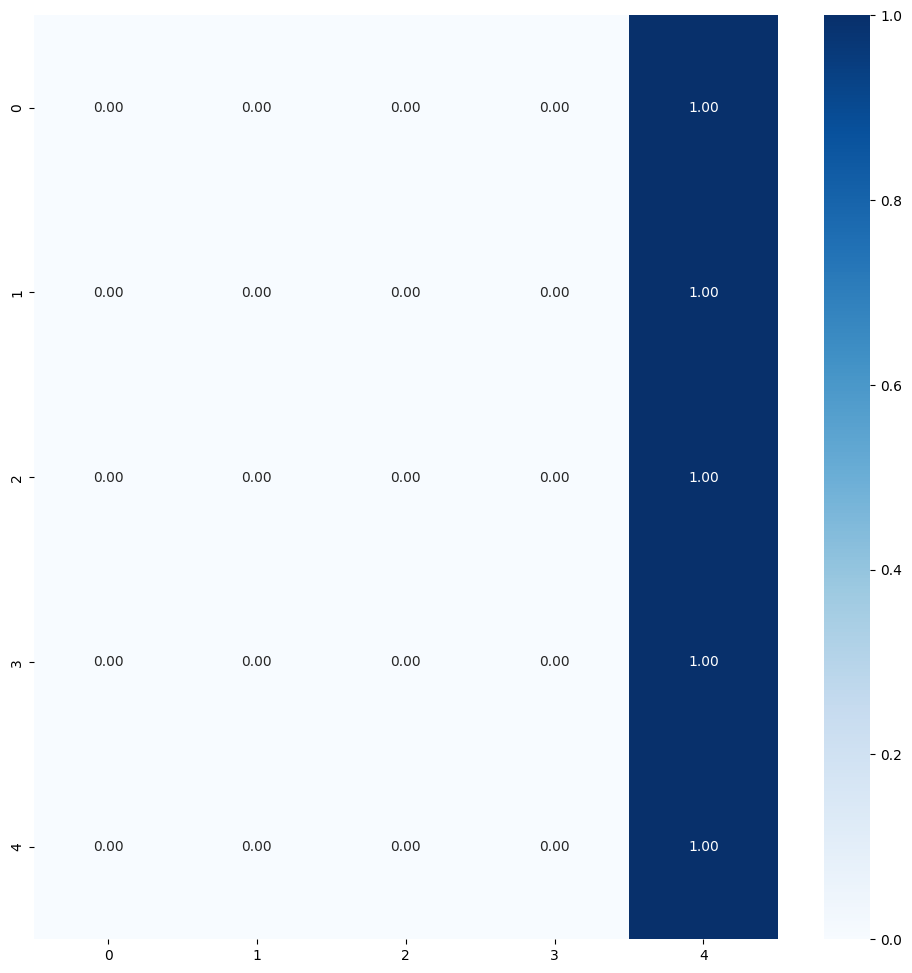

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3758277
Trainable params: 2116613
Non-trainable params: 1641664
Epoch 1/50
164/164 [==============================] - 36s 165ms/step - loss: 6.2822 - accuracy: 0.1922 - val_loss: 4.5998 - val_accuracy: 0.2009
Epoch 2/50
164/164 [==============================] - 23s 141ms/step - loss: 3.6089 - accuracy: 0.1920 - val_loss: 2.8322 - val_accuracy: 0.1991
Epoch 3/50
164/164 [==============================] - 22s 133ms/step - loss: 2.3970 - accuracy: 0.1936 - val_loss: 2.0649 - val_accuracy: 0.2009
Epoch 4/50
164/164 [==============================] - 25s 153ms/step - loss: 1.8900 - accuracy: 0.1987 - val_loss: 1.7613 - val_accuracy: 0.2009
Epoch 5/50
164/164 [==============================] - 23s 139ms/step - loss: 1.6983 - accuracy: 0.1976 - val_loss: 1.6540 - val_accuracy: 0.2000
Epoch 6/50
164/164 [==============================] - 19s 118ms/step - loss: 1.6343 - accuracy: 0.1957 - val_loss: 1.6208 - val_accuracy: 0.2000
Epoch 7/50
164

Model and History saved...
165/165 [==============================] - 20s 119ms/step - loss: 1.6095 - accuracy: 0.2000
Train Accuracy: 0.20000000298023224
Train Log Loss: 1.609452724456787
36/36 [==============================] - 3s 85ms/step - loss: 1.6095 - accuracy: 0.2000
Validation Accuracy: 0.20000000298023224
Validation Log Loss: 1.6094526052474976
36/36 [==============================] - 3s 82ms/step - loss: 1.6095 - accuracy: 0.2000
Test Accuracy: 0.20000000298023224
Test Log Loss: 1.609452247619629
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[225   0   0   0   0]
 [225   0   0   0   0]
 [225   0   0   0   0]
 [225   0   0   0   0]
 [225   0   0   0   0]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.20      1.00      0.33       225
           1       0.00      0.00      0.00       225
           2       0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


36/36 [==============================] - 6s 122ms/step


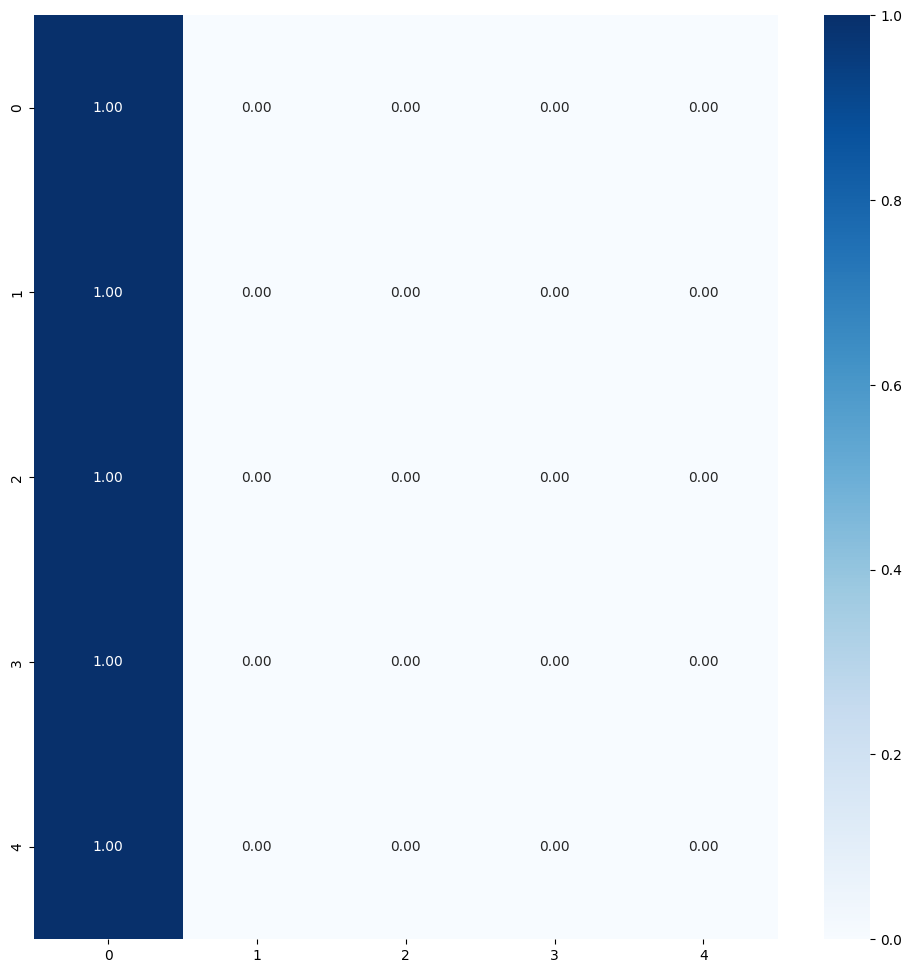

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3758277
Trainable params: 2116613
Non-trainable params: 1641664
Epoch 1/50
164/164 [==============================] - 37s 172ms/step - loss: 6.2887 - accuracy: 0.1863 - val_loss: 4.6061 - val_accuracy: 0.2009
Epoch 2/50
164/164 [==============================] - 26s 158ms/step - loss: 3.6068 - accuracy: 0.1920 - val_loss: 2.8353 - val_accuracy: 0.1991
Epoch 3/50
164/164 [==============================] - 28s 170ms/step - loss: 2.3993 - accuracy: 0.1987 - val_loss: 2.0663 - val_accuracy: 0.1991
Epoch 4/50
164/164 [==============================] - 27s 164ms/step - loss: 1.8912 - accuracy: 0.1928 - val_loss: 1.7618 - val_accuracy: 0.1991
Epoch 5/50
164/164 [==============================] - 30s 180ms/step - loss: 1.6989 - accuracy: 0.1951 - val_loss: 1.6542 - val_accuracy: 0.2000
Epoch 6/50
164/164 [==============================] - 28s 172ms/step - loss: 1.6345 - accuracy: 0.1970 - val_loss: 1.6209 - val_accuracy: 0.2000
Epoch 7/50
164

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



164/164 [==============================] - 23s 139ms/step - loss: 1.6097 - accuracy: 0.2018 - val_loss: 1.6095 - val_accuracy: 0.2000
Epoch 42/50
164/164 [==============================] - 26s 158ms/step - loss: 1.6096 - accuracy: 0.1957 - val_loss: 1.6094 - val_accuracy: 0.2000
Epoch 43/50
164/164 [==============================] - 24s 144ms/step - loss: 1.6096 - accuracy: 0.1985 - val_loss: 1.6095 - val_accuracy: 0.2000
Epoch 44/50
164/164 [==============================] - 24s 145ms/step - loss: 1.6095 - accuracy: 0.1915 - val_loss: 1.6094 - val_accuracy: 0.2009
Epoch 45/50
164/164 [==============================] - 25s 153ms/step - loss: 1.6097 - accuracy: 0.1984 - val_loss: 1.6094 - val_accuracy: 0.2000
Epoch 46/50
164/164 [==============================] - 23s 142ms/step - loss: 1.6096 - accuracy: 0.1978 - val_loss: 1.6094 - val_accuracy: 0.2000
Epoch 47/50
164/164 [==============================] - 24s 146ms/step - loss: 1.6095 - accuracy: 0.2035 - val_loss: 1.6094 - val_accurac

Model and History saved...
165/165 [==============================] - 16s 95ms/step - loss: 1.6094 - accuracy: 0.2000
Train Accuracy: 0.20000000298023224
Train Log Loss: 1.609447717666626
36/36 [==============================] - 2s 56ms/step - loss: 1.6094 - accuracy: 0.2000
Validation Accuracy: 0.20000000298023224
Validation Log Loss: 1.6094474792480469
36/36 [==============================] - 2s 60ms/step - loss: 1.6094 - accuracy: 0.2000
Test Accuracy: 0.20000000298023224
Test Log Loss: 1.6094475984573364
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'sfone': 2, 'sillyp2p': 3, 'wabot': 4}

Matriz de Confusión:
[[  0   0 225   0   0]
 [  0   0 225   0   0]
 [  0   0 225   0   0]
 [  0   0 225   0   0]
 [  0   0 225   0   0]]
True labels: 1125
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.00      0.00      0.00       225
           2       0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


36/36 [==============================] - 3s 58ms/step


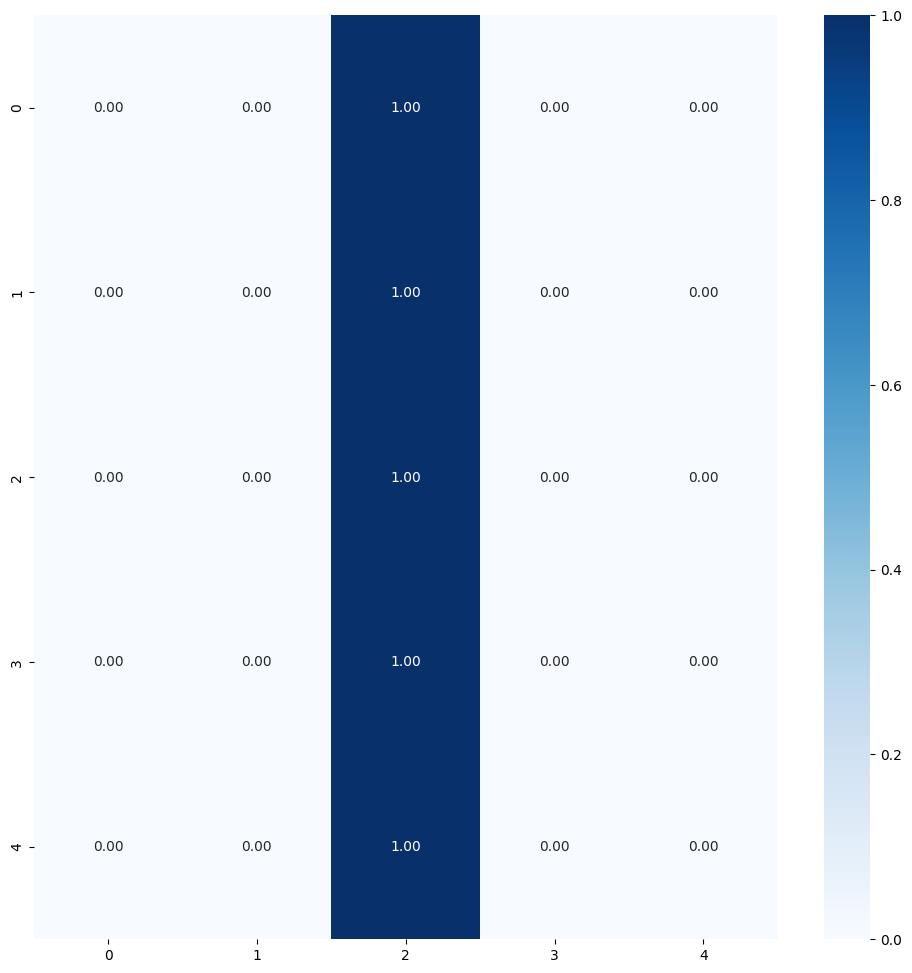

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.20502108037471772
Average validation precision in 5-fold: 0.2008928507566452
/nTest Metrics
test_acc_list: [0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224]
Average Test Accuracy with 5-fold: 0.20000000298023224
test_loss_list: [1.6094448566436768, 1.609452247619629, 1.6094447374343872, 1.6095046997070312, 1.6094475984573364]
Average Test Log Loss with 5-fold: 1.609458827972412

Precision List: [0.04, 0.04, 0.04, 0.04, 0.04]
Average Precision List with 5-fold: 0.04
Recall List: [0.2, 0.2, 0.2, 0.2, 0.2]
Average Recall List with 5-fold: 0.2
F1 Score List: [0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667]
Average F1 Score List with 5-fold: 0.06666666666666667

Metrics List Store

test_acc_list_all = [0.5, 0.3333333432674408, 0.25, 0.20000000298023224]
test_loss_list_all = [0.6931522369384766, 1.098618984222412, 1.3862980842590331, 1.609458

In [22]:
%%time

num_classes = 5
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/6
name_save_model: fusion_VGG16_basic_6
Found 6300 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Found 1350 images belonging to 6 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3758790
Trainable params: 2117126
Non-trainable params: 1641664
Epoch 1/50
196/196 [==============================] - 20s 81ms/step - loss: 6.1557 - accuracy: 0.1621 - val_loss: 4.3178 - val_accuracy: 0.1659
Epoch 2/50
196/196 [==============================] - 15s 75ms/step - loss: 3.3440 - accuracy: 0.1527 - val_loss: 2.6331 - val_accuracy: 0.1674
Epoch 3/50
196/196 [==============================] - 15s 76ms/step - loss: 2.2811 - accuracy: 0.1546 - val_loss: 2.0345 - val_accuracy: 0.1667
Epoch 4/50
196/196 [==============================] - 15s 75ms/step - loss: 1.9242 - accuracy: 0.1638 - val_loss: 1.85

Model and History saved...
197/197 [==============================] - 33s 165ms/step - loss: 1.7918 - accuracy: 0.1667
Train Accuracy: 0.1666666716337204
Train Log Loss: 1.7917711734771729
43/43 [==============================] - 8s 182ms/step - loss: 1.7918 - accuracy: 0.1667
Validation Accuracy: 0.1666666716337204
Validation Log Loss: 1.7917704582214355
43/43 [==============================] - 7s 146ms/step - loss: 1.7918 - accuracy: 0.1667
Test Accuracy: 0.1666666716337204
Test Log Loss: 1.7917708158493042
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[  0 225   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0 225   0   0   0   0]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


43/43 [==============================] - 8s 142ms/step


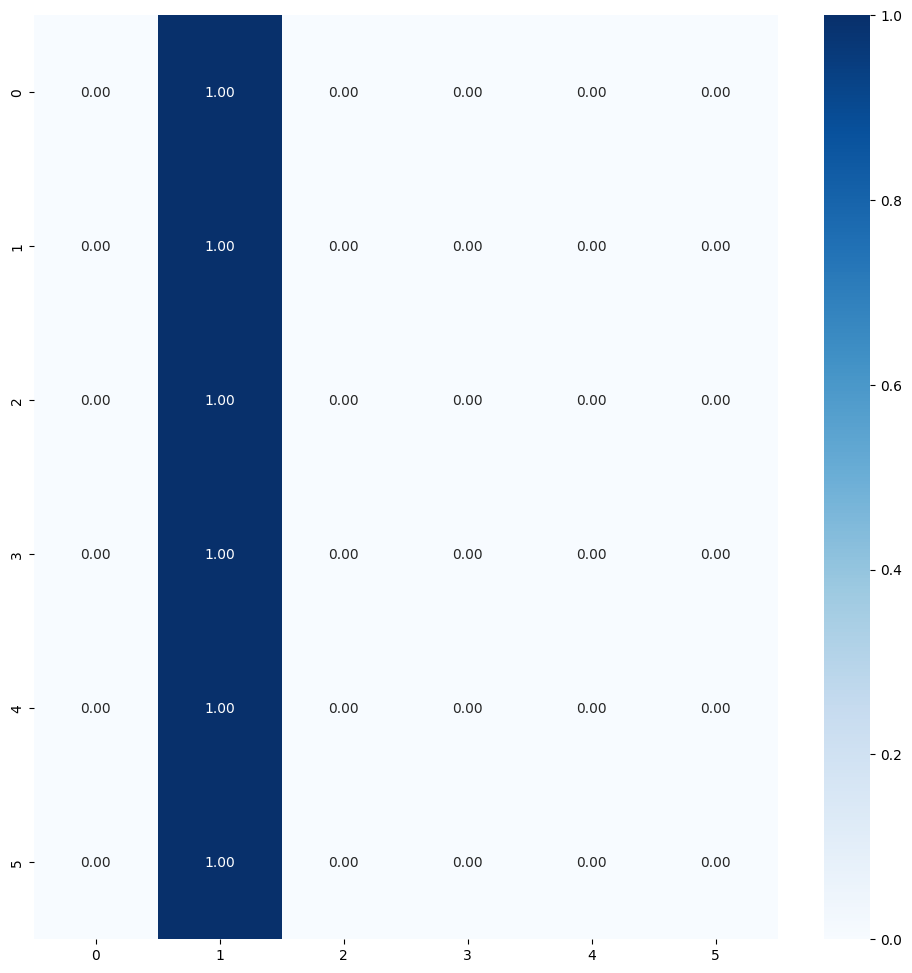

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3758790
Trainable params: 2117126
Non-trainable params: 1641664
Epoch 1/50
196/196 [==============================] - 36s 135ms/step - loss: 6.1616 - accuracy: 0.1610 - val_loss: 4.3212 - val_accuracy: 0.1667
Epoch 2/50
196/196 [==============================] - 28s 142ms/step - loss: 3.3471 - accuracy: 0.1587 - val_loss: 2.6349 - val_accuracy: 0.1674
Epoch 3/50
196/196 [==============================] - 27s 138ms/step - loss: 2.2826 - accuracy: 0.1592 - val_loss: 2.0353 - val_accuracy: 0.1667
Epoch 4/50
196/196 [==============================] - 29s 148ms/step - loss: 1.9247 - accuracy: 0.1594 - val_loss: 1.8510 - val_accuracy: 0.1659
Epoch 5/50
196/196 [==============================] - 26s 134ms/step - loss: 1.8219 - accuracy: 0.1594 - val_loss: 1.8036 - val_accuracy: 0.1659
Epoch 6/50
196/196 [==============================] - 31s 156ms/step - loss: 1.7975 - accuracy: 0.1591 - val_loss: 1.7937 - val_accuracy: 0.1667
Epoch 7/50
196

Model and History saved...
197/197 [==============================] - 30s 153ms/step - loss: 1.7918 - accuracy: 0.1667
Train Accuracy: 0.1666666716337204
Train Log Loss: 1.791759729385376
43/43 [==============================] - 6s 131ms/step - loss: 1.7918 - accuracy: 0.1667
Validation Accuracy: 0.1666666716337204
Validation Log Loss: 1.7917596101760864
43/43 [==============================] - 6s 135ms/step - loss: 1.7918 - accuracy: 0.1667
Test Accuracy: 0.1666666716337204
Test Log Loss: 1.7917598485946655
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[  0 225   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0 225   0   0   0   0]
 [  0 225   0   0   0   0]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


43/43 [==============================] - 5s 90ms/step


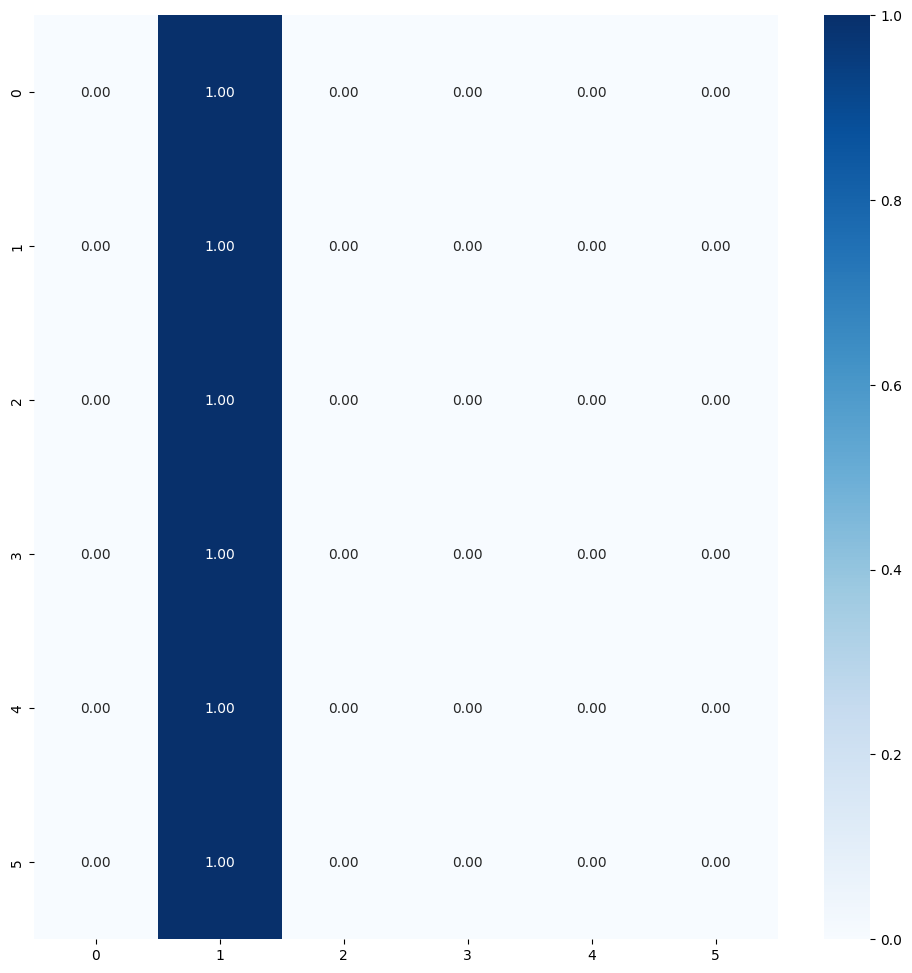

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3758790
Trainable params: 2117126
Non-trainable params: 1641664
Epoch 1/50
196/196 [==============================] - 45s 193ms/step - loss: 6.1661 - accuracy: 0.1597 - val_loss: 4.3244 - val_accuracy: 0.1667
Epoch 2/50
196/196 [==============================] - 31s 159ms/step - loss: 3.3493 - accuracy: 0.1600 - val_loss: 2.6357 - val_accuracy: 0.1674
Epoch 3/50
196/196 [==============================] - 31s 158ms/step - loss: 2.2830 - accuracy: 0.1642 - val_loss: 2.0354 - val_accuracy: 0.1667
Epoch 4/50
196/196 [==============================] - 26s 133ms/step - loss: 1.9247 - accuracy: 0.1591 - val_loss: 1.8509 - val_accuracy: 0.1674
Epoch 5/50
196/196 [==============================] - 31s 159ms/step - loss: 1.8220 - accuracy: 0.1554 - val_loss: 1.8036 - val_accuracy: 0.1652
Epoch 6/50
196/196 [==============================] - 30s 153ms/step - loss: 1.7974 - accuracy: 0.1650 - val_loss: 1.7936 - val_accuracy: 0.1667
Epoch 7/50
196

Model and History saved...
197/197 [==============================] - 27s 137ms/step - loss: 1.7918 - accuracy: 0.1667
Train Accuracy: 0.1666666716337204
Train Log Loss: 1.7917661666870117
43/43 [==============================] - 6s 134ms/step - loss: 1.7918 - accuracy: 0.1667
Validation Accuracy: 0.1666666716337204
Validation Log Loss: 1.7917659282684326
43/43 [==============================] - 6s 133ms/step - loss: 1.7918 - accuracy: 0.1667
Test Accuracy: 0.1666666716337204
Test Log Loss: 1.7917662858963013
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[  0   0 225   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0 225   0   0   0]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


43/43 [==============================] - 7s 132ms/step


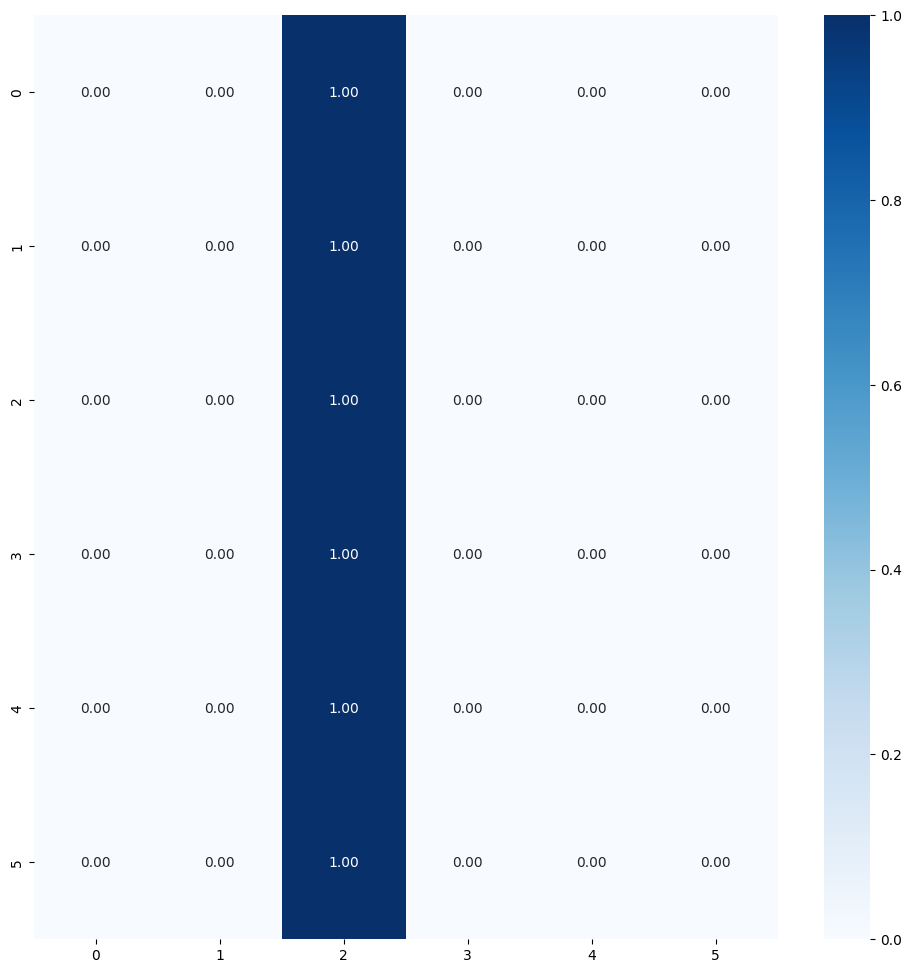

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3758790
Trainable params: 2117126
Non-trainable params: 1641664
Epoch 1/50
196/196 [==============================] - 39s 169ms/step - loss: 6.1658 - accuracy: 0.1634 - val_loss: 4.3247 - val_accuracy: 0.1667
Epoch 2/50
196/196 [==============================] - 33s 170ms/step - loss: 3.3494 - accuracy: 0.1578 - val_loss: 2.6363 - val_accuracy: 0.1659
Epoch 3/50
196/196 [==============================] - 26s 131ms/step - loss: 2.2834 - accuracy: 0.1556 - val_loss: 2.0357 - val_accuracy: 0.1674
Epoch 4/50
196/196 [==============================] - 24s 124ms/step - loss: 1.9249 - accuracy: 0.1607 - val_loss: 1.8510 - val_accuracy: 0.1667
Epoch 5/50
196/196 [==============================] - 30s 155ms/step - loss: 1.8220 - accuracy: 0.1618 - val_loss: 1.8036 - val_accuracy: 0.1659
Epoch 6/50
196/196 [==============================] - 33s 168ms/step - loss: 1.7975 - accuracy: 0.1615 - val_loss: 1.7937 - val_accuracy: 0.1667
Epoch 7/50
196

Model and History saved...
197/197 [==============================] - 21s 105ms/step - loss: 1.7918 - accuracy: 0.1667
Train Accuracy: 0.1666666716337204
Train Log Loss: 1.791761040687561
43/43 [==============================] - 5s 119ms/step - loss: 1.7918 - accuracy: 0.1667
Validation Accuracy: 0.1666666716337204
Validation Log Loss: 1.7917613983154297
43/43 [==============================] - 5s 118ms/step - loss: 1.7918 - accuracy: 0.1667
Test Accuracy: 0.1666666716337204
Test Log Loss: 1.7917616367340088
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[  0   0 225   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0 225   0   0   0]
 [  0   0 225   0   0   0]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


43/43 [==============================] - 7s 133ms/step


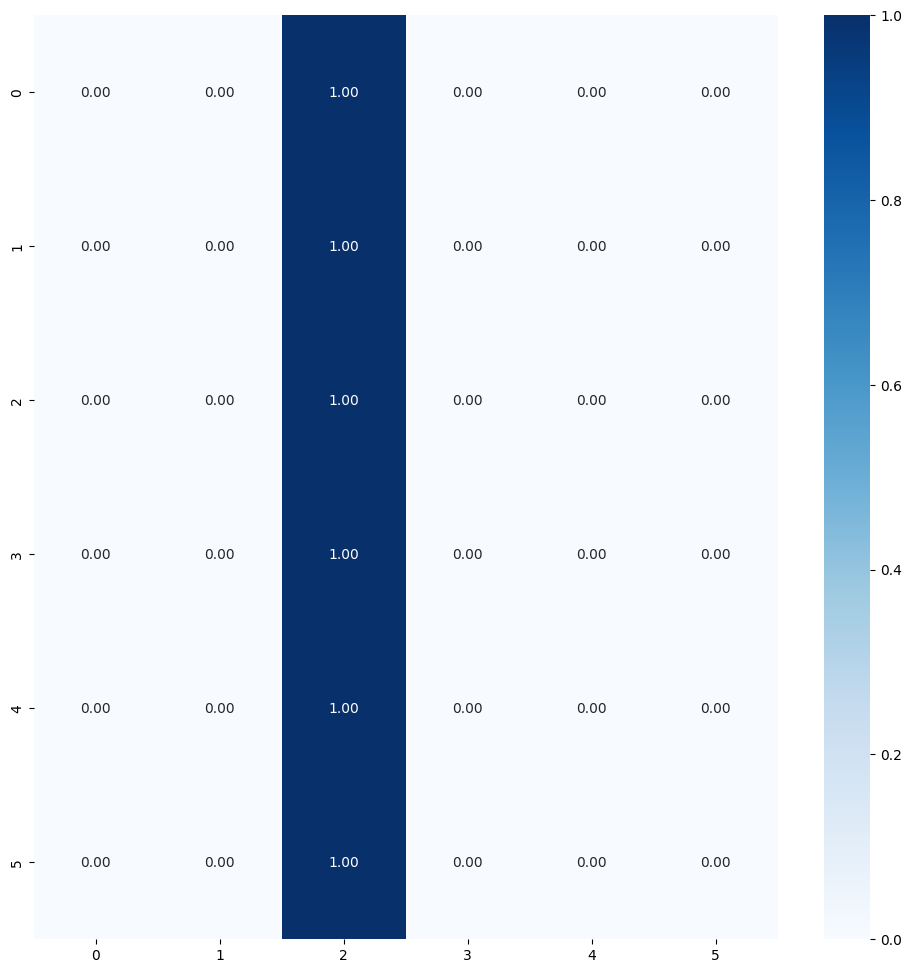

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3758790
Trainable params: 2117126
Non-trainable params: 1641664
Epoch 1/50
196/196 [==============================] - 43s 172ms/step - loss: 6.1601 - accuracy: 0.1568 - val_loss: 4.3209 - val_accuracy: 0.1652
Epoch 2/50
196/196 [==============================] - 25s 125ms/step - loss: 3.3469 - accuracy: 0.1557 - val_loss: 2.6344 - val_accuracy: 0.1667
Epoch 3/50
196/196 [==============================] - 25s 126ms/step - loss: 2.2822 - accuracy: 0.1587 - val_loss: 2.0350 - val_accuracy: 0.1667
Epoch 4/50
196/196 [==============================] - 31s 158ms/step - loss: 1.9244 - accuracy: 0.1520 - val_loss: 1.8508 - val_accuracy: 0.1652
Epoch 5/50
196/196 [==============================] - 31s 157ms/step - loss: 1.8219 - accuracy: 0.1541 - val_loss: 1.8036 - val_accuracy: 0.1659
Epoch 6/50
196/196 [==============================] - 26s 132ms/step - loss: 1.7974 - accuracy: 0.1642 - val_loss: 1.7937 - val_accuracy: 0.1674
Epoch 7/50
196

Model and History saved...
197/197 [==============================] - 27s 135ms/step - loss: 1.7918 - accuracy: 0.1667
Train Accuracy: 0.1666666716337204
Train Log Loss: 1.7917604446411133
43/43 [==============================] - 6s 131ms/step - loss: 1.7918 - accuracy: 0.1667
Validation Accuracy: 0.1666666716337204
Validation Log Loss: 1.7917605638504028
43/43 [==============================] - 6s 129ms/step - loss: 1.7918 - accuracy: 0.1667
Test Accuracy: 0.1666666716337204
Test Log Loss: 1.7917606830596924
Test labels: {'Allaple.A': 0, 'Ramnit': 1, 'mira': 2, 'sfone': 3, 'sillyp2p': 4, 'wabot': 5}

Matriz de Confusión:
[[  0   0   0   0   0 225]
 [  0   0   0   0   0 225]
 [  0   0   0   0   0 225]
 [  0   0   0   0   0 225]
 [  0   0   0   0   0 225]
 [  0   0   0   0   0 225]]
True labels: 1350
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


43/43 [==============================] - 7s 132ms/step


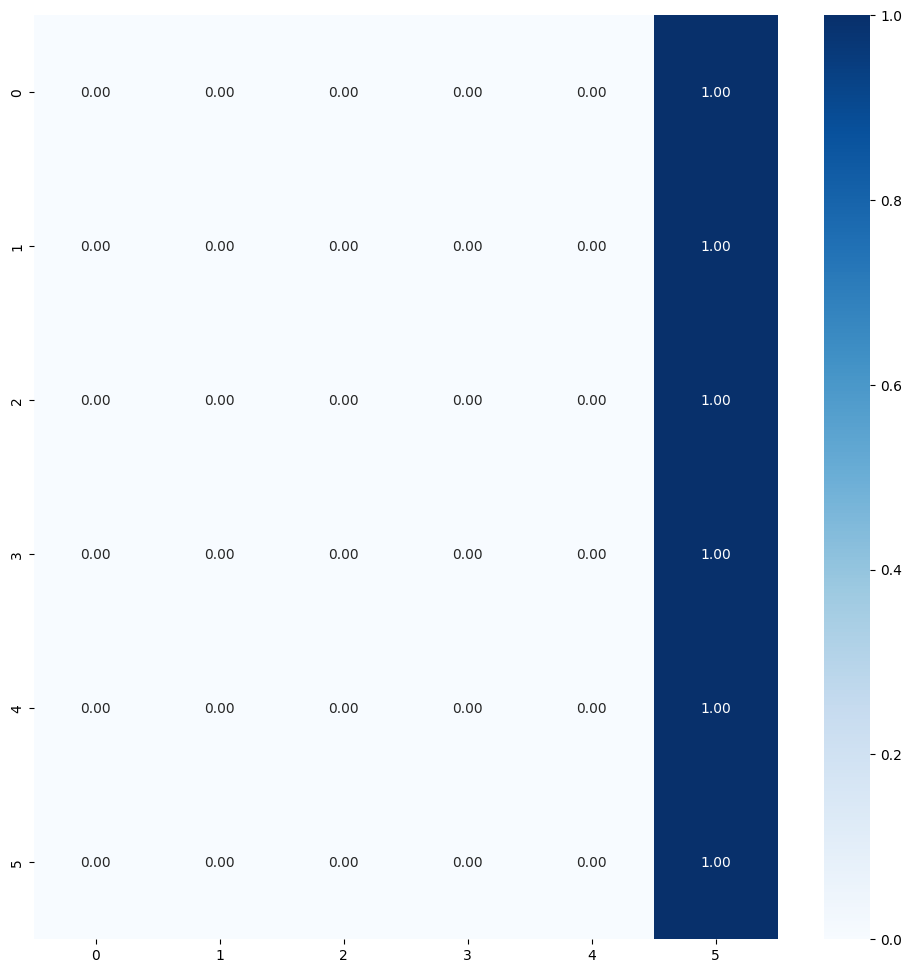

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.1702616482973099
Average validation precision in 5-fold: 0.1674107164144516
/nTest Metrics
test_acc_list: [0.1666666716337204, 0.1666666716337204, 0.1666666716337204, 0.1666666716337204, 0.1666666716337204]
Average Test Accuracy with 5-fold: 0.1666666716337204
test_loss_list: [1.7917708158493042, 1.7917598485946655, 1.7917662858963013, 1.7917616367340088, 1.7917606830596924]
Average Test Log Loss with 5-fold: 1.7917638540267944

Precision List: [0.027777777777777776, 0.027777777777777776, 0.027777777777777776, 0.027777777777777776, 0.027777777777777776]
Average Precision List with 5-fold: 0.02777777777777778
Recall List: [0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]
Average Recall List with 5-fold: 0.16666666666666666
F1 Score List: [0.047619047619047616, 0.047619047619047616, 0.047619047619047616, 0.047619047619047616, 0.047619047619047616]
Average F1 Score List with 5-fold: 0.0476190476

In [23]:
%%time

num_classes = 6
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/7
name_save_model: fusion_VGG16_basic_7
Found 7350 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Found 1575 images belonging to 7 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3759303
Trainable params: 2117639
Non-trainable params: 1641664
Epoch 1/50
229/229 [==============================] - 45s 153ms/step - loss: 6.0195 - accuracy: 0.1380 - val_loss: 4.0657 - val_accuracy: 0.1429
Epoch 2/50
229/229 [==============================] - 36s 155ms/step - loss: 3.1413 - accuracy: 0.1300 - val_loss: 2.5098 - val_accuracy: 0.1422
Epoch 3/50
229/229 [==============================] - 42s 182ms/step - loss: 2.2408 - accuracy: 0.1312 - val_loss: 2.0675 - val_accuracy: 0.1435
Epoch 4/50
229/229 [==============================] - 38s 167ms/step - loss: 2.0041 - accuracy: 0.13

Model and History saved...
230/230 [==============================] - 29s 125ms/step - loss: 1.9459 - accuracy: 0.1429
Train Accuracy: 0.1428571492433548
Train Log Loss: 1.945915937423706
50/50 [==============================] - 8s 159ms/step - loss: 1.9459 - accuracy: 0.1429
Validation Accuracy: 0.1428571492433548
Validation Log Loss: 1.9459162950515747
50/50 [==============================] - 8s 148ms/step - loss: 1.9459 - accuracy: 0.1429
Test Accuracy: 0.1428571492433548
Test Log Loss: 1.945915937423706
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[225   0   0   0   0   0   0]
 [225   0   0   0   0   0   0]
 [225   0   0   0   0   0   0]
 [225   0   0   0   0   0   0]
 [225   0   0   0   0   0   0]
 [225   0   0   0   0   0   0]
 [225   0   0   0   0   0   0]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   support

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


50/50 [==============================] - 9s 140ms/step


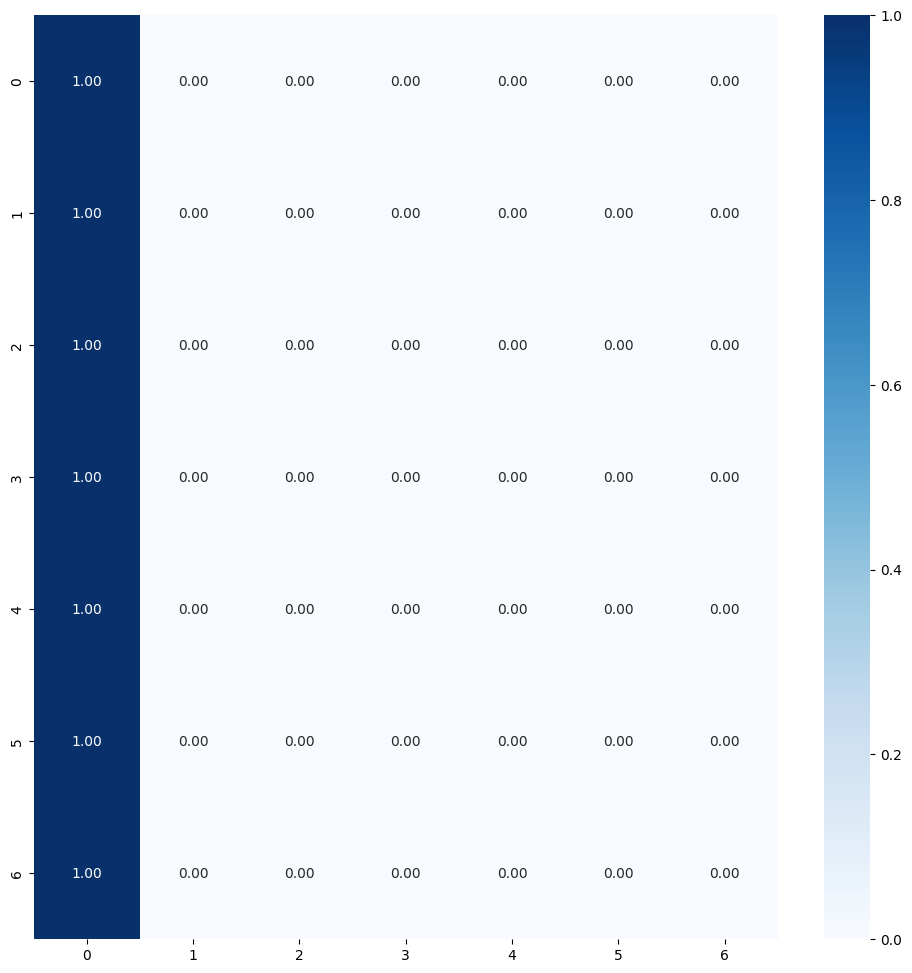

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3759303
Trainable params: 2117639
Non-trainable params: 1641664
Epoch 1/50
229/229 [==============================] - 50s 157ms/step - loss: 6.0169 - accuracy: 0.1349 - val_loss: 4.0622 - val_accuracy: 0.1435
Epoch 2/50
229/229 [==============================] - 38s 166ms/step - loss: 3.1404 - accuracy: 0.1325 - val_loss: 2.5089 - val_accuracy: 0.1422
Epoch 3/50
229/229 [==============================] - 35s 150ms/step - loss: 2.2403 - accuracy: 0.1425 - val_loss: 2.0673 - val_accuracy: 0.1429
Epoch 4/50
229/229 [==============================] - 41s 176ms/step - loss: 2.0041 - accuracy: 0.1354 - val_loss: 1.9663 - val_accuracy: 0.1422
Epoch 5/50
229/229 [==============================] - 32s 138ms/step - loss: 1.9549 - accuracy: 0.1364 - val_loss: 1.9485 - val_accuracy: 0.1422
Epoch 6/50
229/229 [==============================] - 39s 171ms/step - loss: 1.9470 - accuracy: 0.1405 - val_loss: 1.9461 - val_accuracy: 0.1429
Epoch 7/50
229

Model and History saved...
230/230 [==============================] - 30s 129ms/step - loss: 1.9459 - accuracy: 0.1429
Train Accuracy: 0.1428571492433548
Train Log Loss: 1.945920705795288
50/50 [==============================] - 7s 127ms/step - loss: 1.9459 - accuracy: 0.1429
Validation Accuracy: 0.1428571492433548
Validation Log Loss: 1.9459211826324463
50/50 [==============================] - 7s 141ms/step - loss: 1.9459 - accuracy: 0.1429
Test Accuracy: 0.1428571492433548
Test Log Loss: 1.9459210634231567
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[  0   0 225   0   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0 225   0   0   0   0]
 [  0   0 225   0   0   0   0]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   suppor

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


50/50 [==============================] - 9s 144ms/step


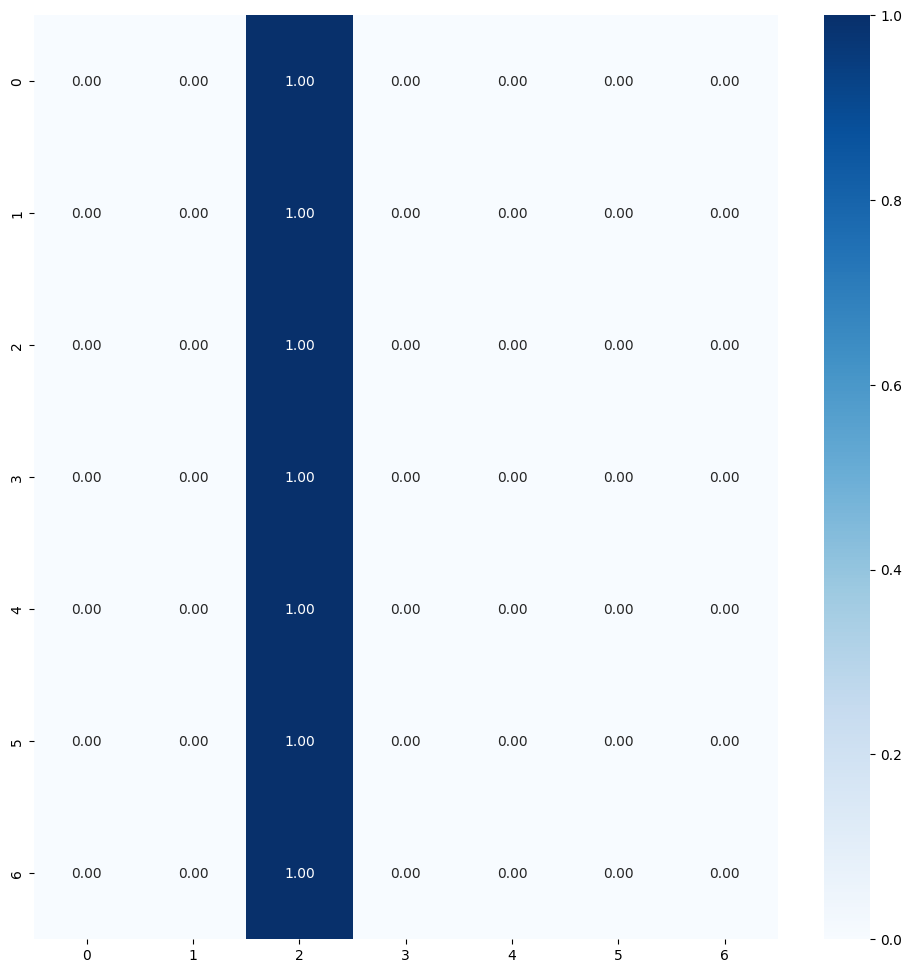

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3759303
Trainable params: 2117639
Non-trainable params: 1641664
Epoch 1/50
229/229 [==============================] - 45s 145ms/step - loss: 6.0206 - accuracy: 0.1384 - val_loss: 4.0650 - val_accuracy: 0.1409
Epoch 2/50
229/229 [==============================] - 37s 161ms/step - loss: 3.1420 - accuracy: 0.1379 - val_loss: 2.5101 - val_accuracy: 0.1422
Epoch 3/50
229/229 [==============================] - 40s 175ms/step - loss: 2.2413 - accuracy: 0.1380 - val_loss: 2.0677 - val_accuracy: 0.1422
Epoch 4/50
229/229 [==============================] - 34s 148ms/step - loss: 2.0043 - accuracy: 0.1365 - val_loss: 1.9663 - val_accuracy: 0.1435
Epoch 5/50
229/229 [==============================] - 36s 156ms/step - loss: 1.9550 - accuracy: 0.1366 - val_loss: 1.9485 - val_accuracy: 0.1429
Epoch 6/50
229/229 [==============================] - 40s 173ms/step - loss: 1.9471 - accuracy: 0.1312 - val_loss: 1.9462 - val_accuracy: 0.1429
Epoch 7/50
229

Model and History saved...
230/230 [==============================] - 24s 103ms/step - loss: 1.9459 - accuracy: 0.1429
Train Accuracy: 0.1428571492433548
Train Log Loss: 1.9459112882614136
50/50 [==============================] - 6s 106ms/step - loss: 1.9459 - accuracy: 0.1429
Validation Accuracy: 0.1428571492433548
Validation Log Loss: 1.945911169052124
50/50 [==============================] - 7s 133ms/step - loss: 1.9459 - accuracy: 0.1429
Test Accuracy: 0.1428571492433548
Test Log Loss: 1.9459112882614136
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[  0   0   0   0   0 225   0]
 [  0   0   0   0   0 225   0]
 [  0   0   0   0   0 225   0]
 [  0   0   0   0   0 225   0]
 [  0   0   0   0   0 225   0]
 [  0   0   0   0   0 225   0]
 [  0   0   0   0   0 225   0]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   suppor

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


50/50 [==============================] - 5s 84ms/step


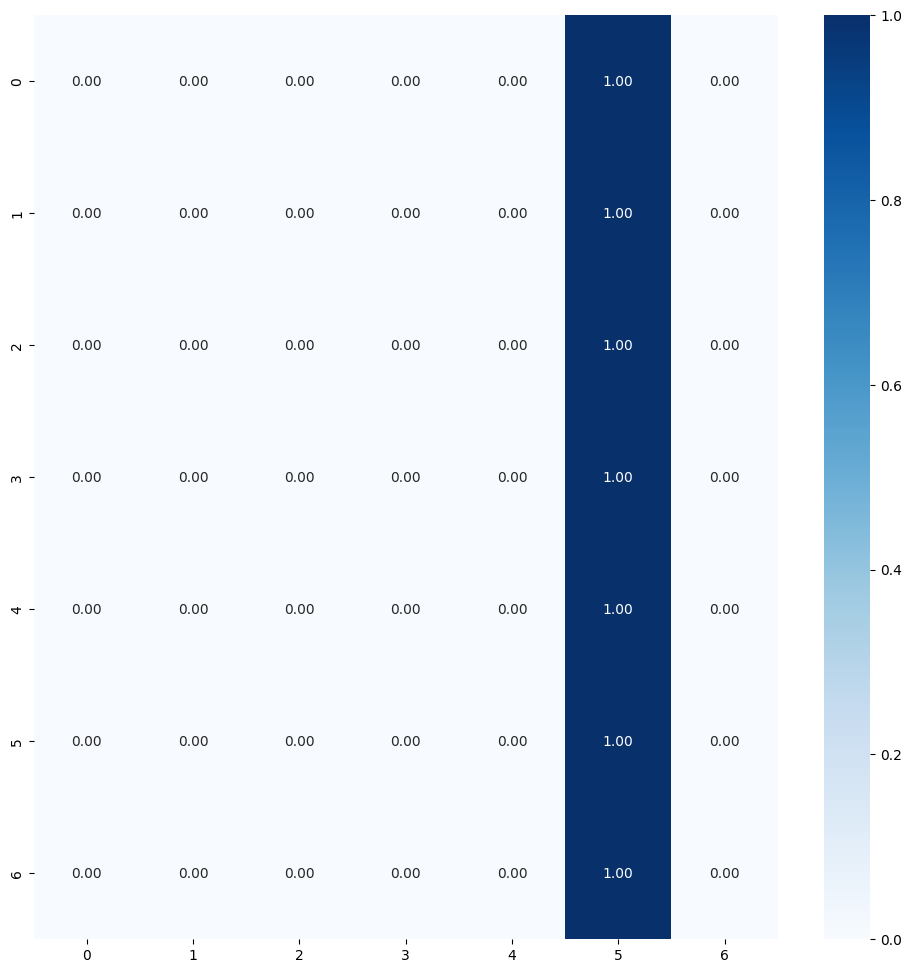

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3759303
Trainable params: 2117639
Non-trainable params: 1641664
Epoch 1/50
229/229 [==============================] - 47s 167ms/step - loss: 6.0202 - accuracy: 0.1350 - val_loss: 4.0636 - val_accuracy: 0.1429
Epoch 2/50
229/229 [==============================] - 35s 154ms/step - loss: 3.1407 - accuracy: 0.1395 - val_loss: 2.5093 - val_accuracy: 0.1435
Epoch 3/50
229/229 [==============================] - 30s 130ms/step - loss: 2.2406 - accuracy: 0.1358 - val_loss: 2.0674 - val_accuracy: 0.1429
Epoch 4/50
229/229 [==============================] - 34s 147ms/step - loss: 2.0043 - accuracy: 0.1335 - val_loss: 1.9663 - val_accuracy: 0.1435
Epoch 5/50
229/229 [==============================] - 32s 138ms/step - loss: 1.9549 - accuracy: 0.1327 - val_loss: 1.9485 - val_accuracy: 0.1435
Epoch 6/50
229/229 [==============================] - 36s 155ms/step - loss: 1.9470 - accuracy: 0.1433 - val_loss: 1.9462 - val_accuracy: 0.1429
Epoch 7/50
229

Model and History saved...
230/230 [==============================] - 31s 136ms/step - loss: 1.9459 - accuracy: 0.1429
Train Accuracy: 0.1428571492433548
Train Log Loss: 1.9459130764007568
50/50 [==============================] - 7s 127ms/step - loss: 1.9459 - accuracy: 0.1429
Validation Accuracy: 0.1428571492433548
Validation Log Loss: 1.9459125995635986
50/50 [==============================] - 7s 133ms/step - loss: 1.9459 - accuracy: 0.1429
Test Accuracy: 0.1428571492433548
Test Log Loss: 1.9459128379821777
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[  0   0   0 225   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0 225   0   0   0]
 [  0   0   0 225   0   0   0]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   suppo

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


50/50 [==============================] - 7s 110ms/step


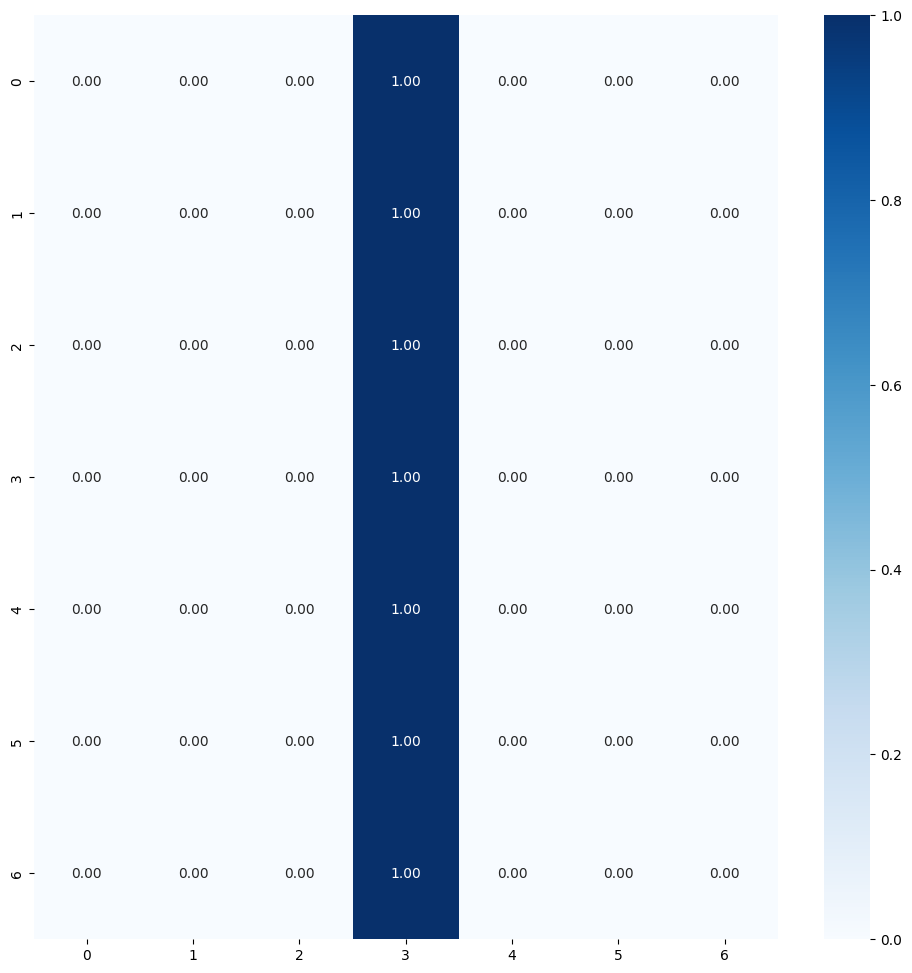

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3759303
Trainable params: 2117639
Non-trainable params: 1641664
Epoch 1/50
229/229 [==============================] - 40s 137ms/step - loss: 6.0227 - accuracy: 0.1343 - val_loss: 4.0664 - val_accuracy: 0.1435
Epoch 2/50
229/229 [==============================] - 38s 164ms/step - loss: 3.1431 - accuracy: 0.1293 - val_loss: 2.5102 - val_accuracy: 0.1429
Epoch 3/50
229/229 [==============================] - 32s 141ms/step - loss: 2.2410 - accuracy: 0.1392 - val_loss: 2.0676 - val_accuracy: 0.1435
Epoch 4/50
229/229 [==============================] - 33s 142ms/step - loss: 2.0043 - accuracy: 0.1349 - val_loss: 1.9663 - val_accuracy: 0.1429
Epoch 5/50
229/229 [==============================] - 35s 151ms/step - loss: 1.9549 - accuracy: 0.1362 - val_loss: 1.9485 - val_accuracy: 0.1429
Epoch 6/50
229/229 [==============================] - 37s 160ms/step - loss: 1.9471 - accuracy: 0.1432 - val_loss: 1.9461 - val_accuracy: 0.1429
Epoch 7/50
229

Model and History saved...
230/230 [==============================] - 26s 113ms/step - loss: 1.9459 - accuracy: 0.1429
Train Accuracy: 0.1428571492433548
Train Log Loss: 1.9459178447723389
50/50 [==============================] - 6s 114ms/step - loss: 1.9459 - accuracy: 0.1429
Validation Accuracy: 0.1428571492433548
Validation Log Loss: 1.945918321609497
50/50 [==============================] - 6s 123ms/step - loss: 1.9459 - accuracy: 0.1429
Test Accuracy: 0.1428571492433548
Test Log Loss: 1.9459184408187866
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'mira': 3, 'sfone': 4, 'sillyp2p': 5, 'wabot': 6}

Matriz de Confusión:
[[  0 225   0   0   0   0   0]
 [  0 225   0   0   0   0   0]
 [  0 225   0   0   0   0   0]
 [  0 225   0   0   0   0   0]
 [  0 225   0   0   0   0   0]
 [  0 225   0   0   0   0   0]
 [  0 225   0   0   0   0   0]]
True labels: 1575
Predicted labels: len(predicted_labels)

Classification report:
              precision    recall  f1-score   suppor

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


50/50 [==============================] - 7s 118ms/step


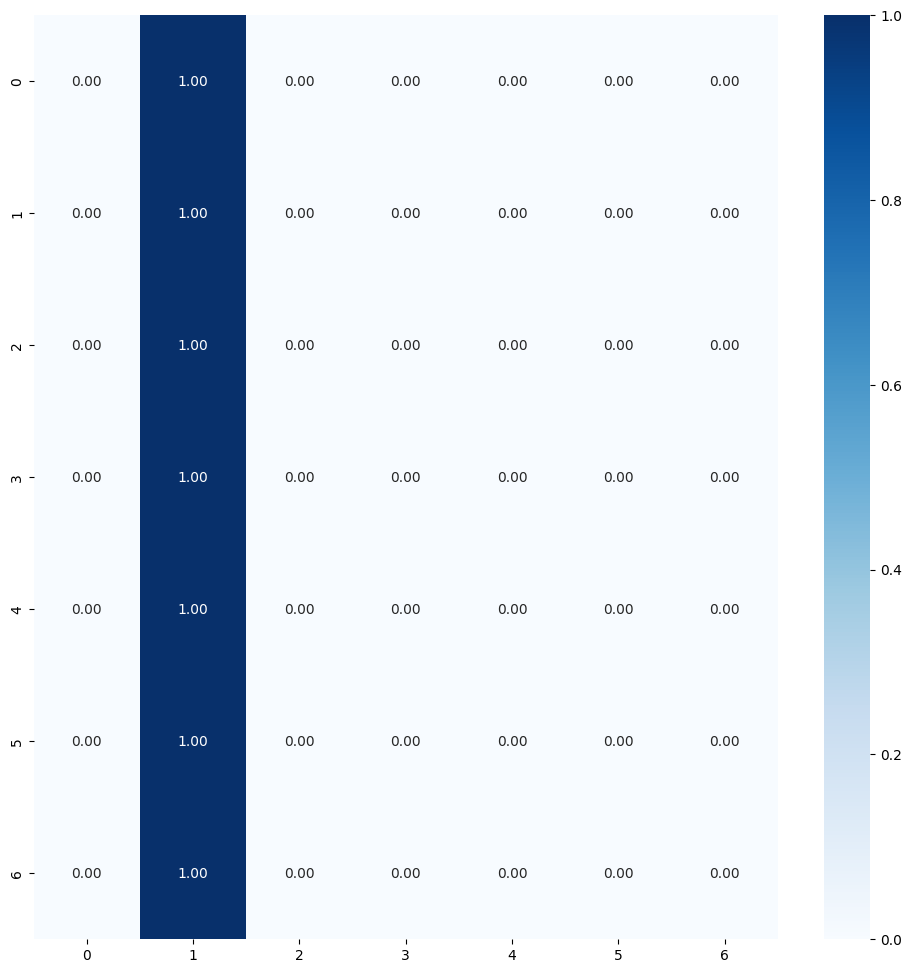

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.1472533494234085
Average validation precision in 5-fold: 0.14349490404129028
/nTest Metrics
test_acc_list: [0.1428571492433548, 0.1428571492433548, 0.1428571492433548, 0.1428571492433548, 0.1428571492433548]
Average Test Accuracy with 5-fold: 0.1428571492433548
test_loss_list: [1.945915937423706, 1.9459210634231567, 1.9459112882614136, 1.9459128379821777, 1.9459184408187866]
Average Test Log Loss with 5-fold: 1.9459159135818482

Precision List: [0.02040816326530612, 0.02040816326530612, 0.02040816326530612, 0.02040816326530612, 0.02040816326530612]
Average Precision List with 5-fold: 0.02040816326530612
Recall List: [0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285, 0.14285714285714285]
Average Recall List with 5-fold: 0.14285714285714285
F1 Score List: [0.03571428571428571, 0.03571428571428571, 0.03571428571428571, 0.03571428571428571, 0.03571428571428571]
Average F1 Score List with 5-fold: 0.03571428571428571

M

In [24]:
%%time

num_classes = 7
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

In [15]:
test_acc_list_all = [0.5, 0.3333333432674408, 0.25, 0.20000000298023224, 0.1666666716337204, 0.1428571492433548]
test_loss_list_all = [0.6931522369384766, 1.098618984222412, 1.3862980842590331, 1.609458827972412, 1.7917638540267944, 1.9459159135818482]
precision_list_all = [0.25, 0.11111111111111112, 0.0625, 0.04, 0.02777777777777778, 0.02040816326530612]
recall_list_all = [0.5, 0.3333333333333333, 0.25, 0.2, 0.16666666666666666, 0.14285714285714285]
f1_score_list_all = [0.3333333333333333, 0.16666666666666666, 0.1, 0.06666666666666667, 0.047619047619047616, 0.03571428571428571]

Familias de malware copiadas
source2: /notebooks/train3/all_malware/8
name_save_model: fusion_VGG16_basic_8
Found 8400 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Found 1800 images belonging to 8 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp

TRAINING AND EVALUATING FOLD 1/5...



2025-05-21 04:05:52.844985: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9504 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:1a:00.0, compute capability: 8.6
2025-05-21 04:05:52.845786: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22449 MB memory:  -> device: 1, name: NVIDIA RTX A5500, pci bus id: 0000:1d:00.0, compute capability: 8.6
2025-05-21 04:05:52.846507: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 3457 MB memory:  -> device: 2, name: NVIDIA GeForce GTX 980, pci bus id: 0000:1b:00.0, compute capability: 5.2
2025-05-21 04:05:52.847206: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 3457 MB memory:  -> device: 3, name: NVIDIA GeForce GTX 980, pci bus id: 0000:

Total params: 3759816
Trainable params: 2118152
Non-trainable params: 1641664
Epoch 1/50


2025-05-21 04:05:56.843099: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-05-21 04:05:59.833196: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f835e7cbaa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-21 04:05:59.833252: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-21 04:05:59.833268: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA RTX A5500, Compute Capability 8.6
2025-05-21 04:05:59.833281: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA GeForce GTX 980, Compute Capability 5.2
2025-05-21 04:05:59.833293: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (3): NVIDIA GeForce GTX 980, Compute Capability 5.2
2025-05-21 04:05:59.833304: I external/local_xla/xla/service/service.cc:176]   StreamExecut

262/262 [==============================] - 30s 83ms/step - loss: 5.8810 - accuracy: 0.1189 - val_loss: 3.8468 - val_accuracy: 0.1256
Epoch 2/50
262/262 [==============================] - 20s 75ms/step - loss: 2.9935 - accuracy: 0.1196 - val_loss: 2.4499 - val_accuracy: 0.1250
Epoch 3/50
262/262 [==============================] - 20s 74ms/step - loss: 2.2531 - accuracy: 0.1205 - val_loss: 2.1374 - val_accuracy: 0.1250
Epoch 4/50
262/262 [==============================] - 19s 73ms/step - loss: 2.1039 - accuracy: 0.1213 - val_loss: 2.0858 - val_accuracy: 0.1250
Epoch 5/50
262/262 [==============================] - 20s 76ms/step - loss: 2.0820 - accuracy: 0.1226 - val_loss: 2.0799 - val_accuracy: 0.1250
Epoch 6/50
262/262 [==============================] - 20s 75ms/step - loss: 2.0797 - accuracy: 0.1213 - val_loss: 2.0795 - val_accuracy: 0.1233
Epoch 7/50
262/262 [==============================] - 20s 76ms/step - loss: 2.0796 - accuracy: 0.1221 - val_loss: 2.0795 - val_accuracy: 0.1239
Epo

Model and History saved...
263/263 [==============================] - 32s 122ms/step - loss: 2.0794 - accuracy: 0.1250
Train Accuracy: 0.125
Train Log Loss: 2.0794448852539062
57/57 [==============================] - 9s 161ms/step - loss: 2.0794 - accuracy: 0.1250
Validation Accuracy: 0.125
Validation Log Loss: 2.0794453620910645
57/57 [==============================] - 8s 145ms/step - loss: 2.0794 - accuracy: 0.1250
Test Accuracy: 0.125
Test Log Loss: 2.0794456005096436
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classification report:
              

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


57/57 [==============================] - 9s 138ms/step


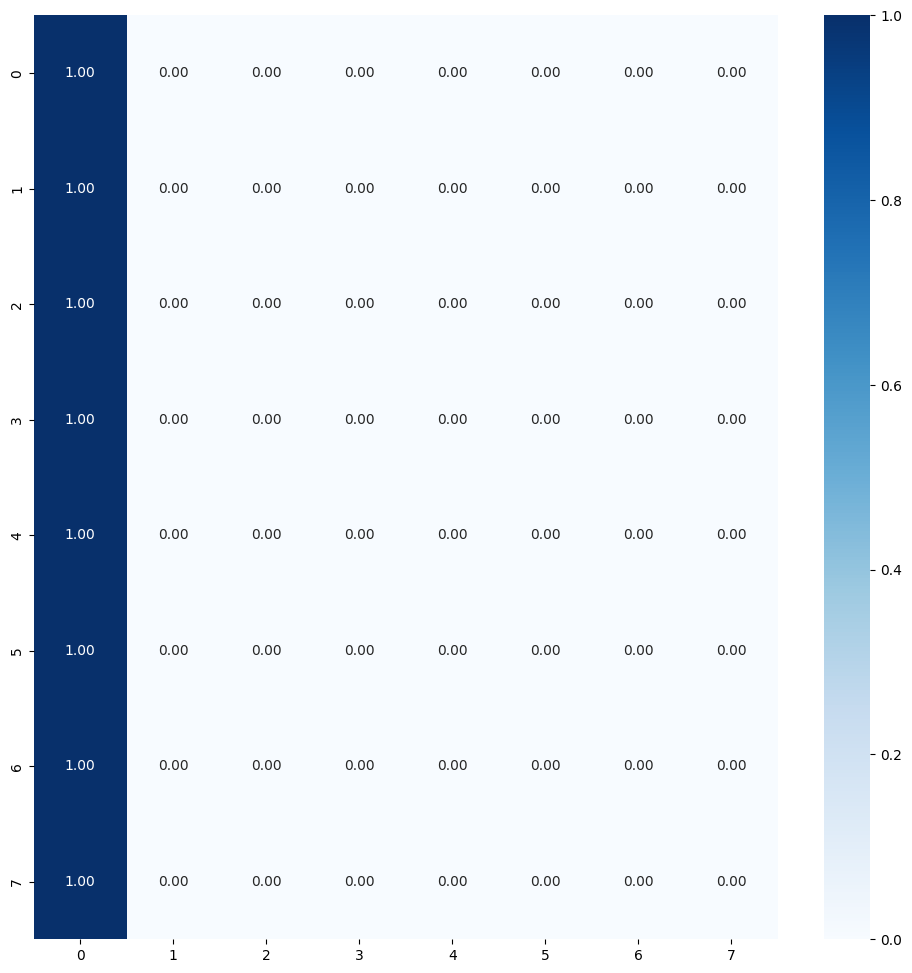

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3759816
Trainable params: 2118152
Non-trainable params: 1641664
Epoch 1/50
262/262 [==============================] - 50s 156ms/step - loss: 5.8860 - accuracy: 0.1170 - val_loss: 3.8486 - val_accuracy: 0.1244
Epoch 2/50
262/262 [==============================] - 44s 168ms/step - loss: 2.9957 - accuracy: 0.1176 - val_loss: 2.4502 - val_accuracy: 0.1239
Epoch 3/50
262/262 [==============================] - 46s 174ms/step - loss: 2.2534 - accuracy: 0.1156 - val_loss: 2.1374 - val_accuracy: 0.1256
Epoch 4/50
262/262 [==============================] - 40s 151ms/step - loss: 2.1037 - accuracy: 0.1205 - val_loss: 2.0858 - val_accuracy: 0.1250
Epoch 5/50
262/262 [==============================] - 45s 173ms/step - loss: 2.0820 - accuracy: 0.1157 - val_loss: 2.0799 - val_accuracy: 0.1250
Epoch 6/50
262/262 [==============================] - 46s 174ms/step - loss: 2.0798 - accuracy: 0.1224 - val_loss: 2.0795 - val_accuracy: 0.1250
Epoch 7/50
262

Model and History saved...
263/263 [==============================] - 31s 118ms/step - loss: 2.0795 - accuracy: 0.1250
Train Accuracy: 0.125
Train Log Loss: 2.0794565677642822
57/57 [==============================] - 6s 102ms/step - loss: 2.0795 - accuracy: 0.1250
Validation Accuracy: 0.125
Validation Log Loss: 2.0794565677642822
57/57 [==============================] - 8s 133ms/step - loss: 2.0795 - accuracy: 0.1250
Test Accuracy: 0.125
Test Log Loss: 2.0794565677642822
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[  0   0   0   0   0 225   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   0   0   0 225   0   0]
 [  0   0   0   0   0 225   0   0]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classification report:
              

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


57/57 [==============================] - 9s 136ms/step


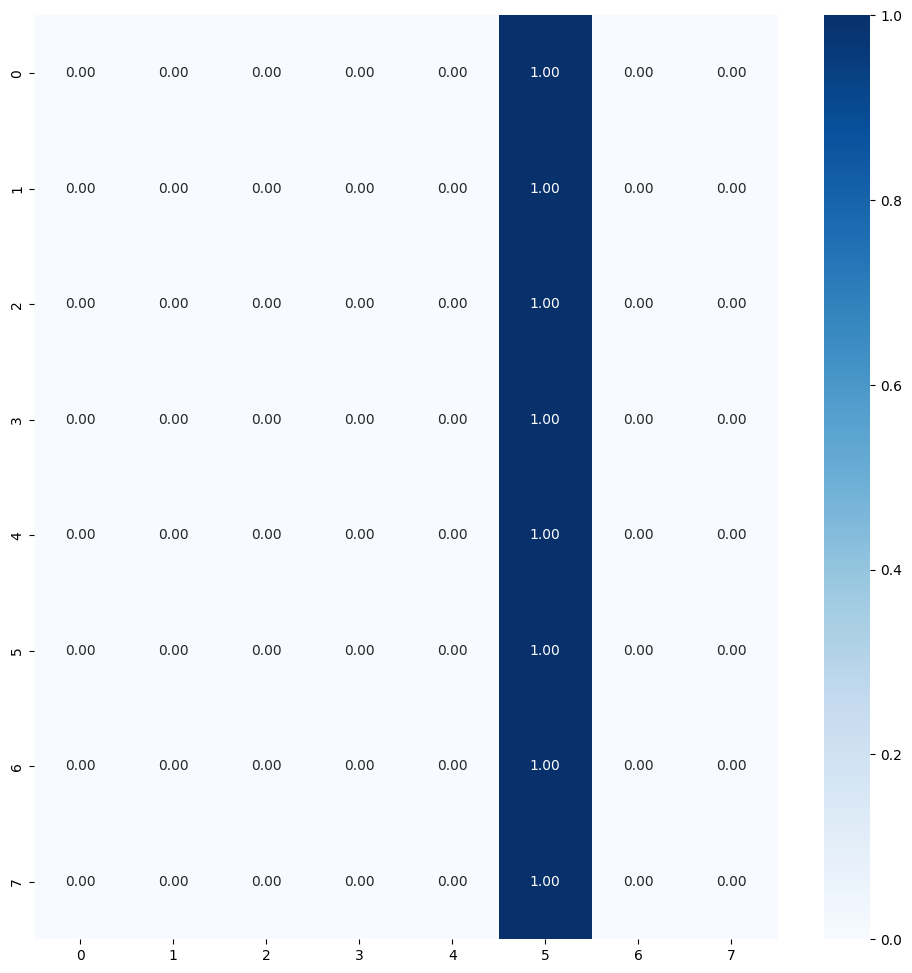

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3759816
Trainable params: 2118152
Non-trainable params: 1641664
Epoch 1/50
262/262 [==============================] - 54s 172ms/step - loss: 5.8851 - accuracy: 0.1196 - val_loss: 3.8478 - val_accuracy: 0.1250
Epoch 2/50
262/262 [==============================] - 37s 142ms/step - loss: 2.9955 - accuracy: 0.1217 - val_loss: 2.4498 - val_accuracy: 0.1250
Epoch 3/50
262/262 [==============================] - 42s 160ms/step - loss: 2.2529 - accuracy: 0.1221 - val_loss: 2.1374 - val_accuracy: 0.1250
Epoch 4/50
262/262 [==============================] - 43s 162ms/step - loss: 2.1038 - accuracy: 0.1187 - val_loss: 2.0858 - val_accuracy: 0.1256
Epoch 5/50
262/262 [==============================] - 39s 150ms/step - loss: 2.0820 - accuracy: 0.1153 - val_loss: 2.0799 - val_accuracy: 0.1244
Epoch 6/50
262/262 [==============================] - 43s 166ms/step - loss: 2.0798 - accuracy: 0.1164 - val_loss: 2.0795 - val_accuracy: 0.1256
Epoch 7/50
262

Model and History saved...
263/263 [==============================] - 35s 132ms/step - loss: 2.0795 - accuracy: 0.1250
Train Accuracy: 0.125
Train Log Loss: 2.0794503688812256
57/57 [==============================] - 8s 130ms/step - loss: 2.0795 - accuracy: 0.1250
Validation Accuracy: 0.125
Validation Log Loss: 2.0794503688812256
57/57 [==============================] - 7s 124ms/step - loss: 2.0795 - accuracy: 0.1250
Test Accuracy: 0.125
Test Log Loss: 2.0794503688812256
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classification report:
              

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


57/57 [==============================] - 9s 124ms/step


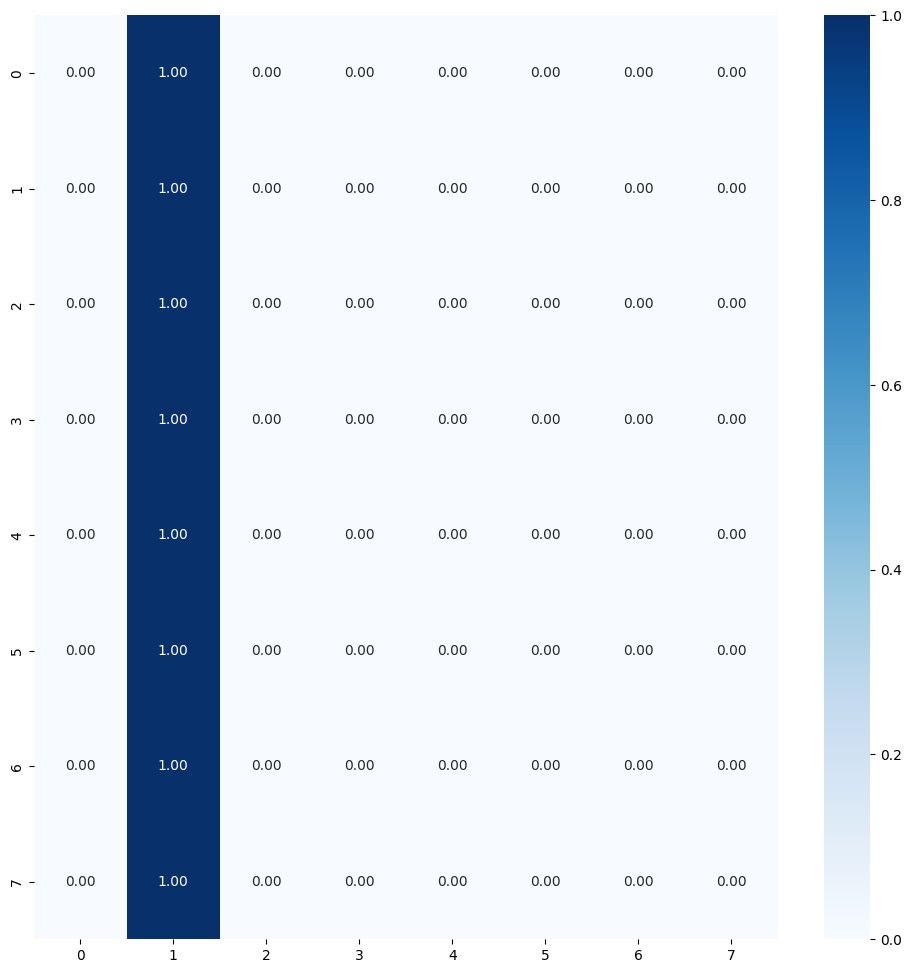

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3759816
Trainable params: 2118152
Non-trainable params: 1641664
Epoch 1/50
262/262 [==============================] - 52s 164ms/step - loss: 5.8954 - accuracy: 0.1224 - val_loss: 3.8531 - val_accuracy: 0.1250
Epoch 2/50
262/262 [==============================] - 42s 160ms/step - loss: 2.9966 - accuracy: 0.1208 - val_loss: 2.4511 - val_accuracy: 0.1250
Epoch 3/50
262/262 [==============================] - 35s 134ms/step - loss: 2.2537 - accuracy: 0.1225 - val_loss: 2.1376 - val_accuracy: 0.1256
Epoch 4/50
262/262 [==============================] - 43s 166ms/step - loss: 2.1039 - accuracy: 0.1182 - val_loss: 2.0858 - val_accuracy: 0.1256
Epoch 5/50
262/262 [==============================] - 39s 150ms/step - loss: 2.0820 - accuracy: 0.1234 - val_loss: 2.0799 - val_accuracy: 0.1256
Epoch 6/50
262/262 [==============================] - 27s 102ms/step - loss: 2.0797 - accuracy: 0.1248 - val_loss: 2.0795 - val_accuracy: 0.1250
Epoch 7/50
262

Model and History saved...
263/263 [==============================] - 30s 114ms/step - loss: 2.0794 - accuracy: 0.1250
Train Accuracy: 0.125
Train Log Loss: 2.079444646835327
57/57 [==============================] - 7s 120ms/step - loss: 2.0794 - accuracy: 0.1250
Validation Accuracy: 0.125
Validation Log Loss: 2.079444646835327
57/57 [==============================] - 8s 135ms/step - loss: 2.0794 - accuracy: 0.1250
Test Accuracy: 0.125
Test Log Loss: 2.079444646835327
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classification report:
              pre

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


57/57 [==============================] - 9s 128ms/step


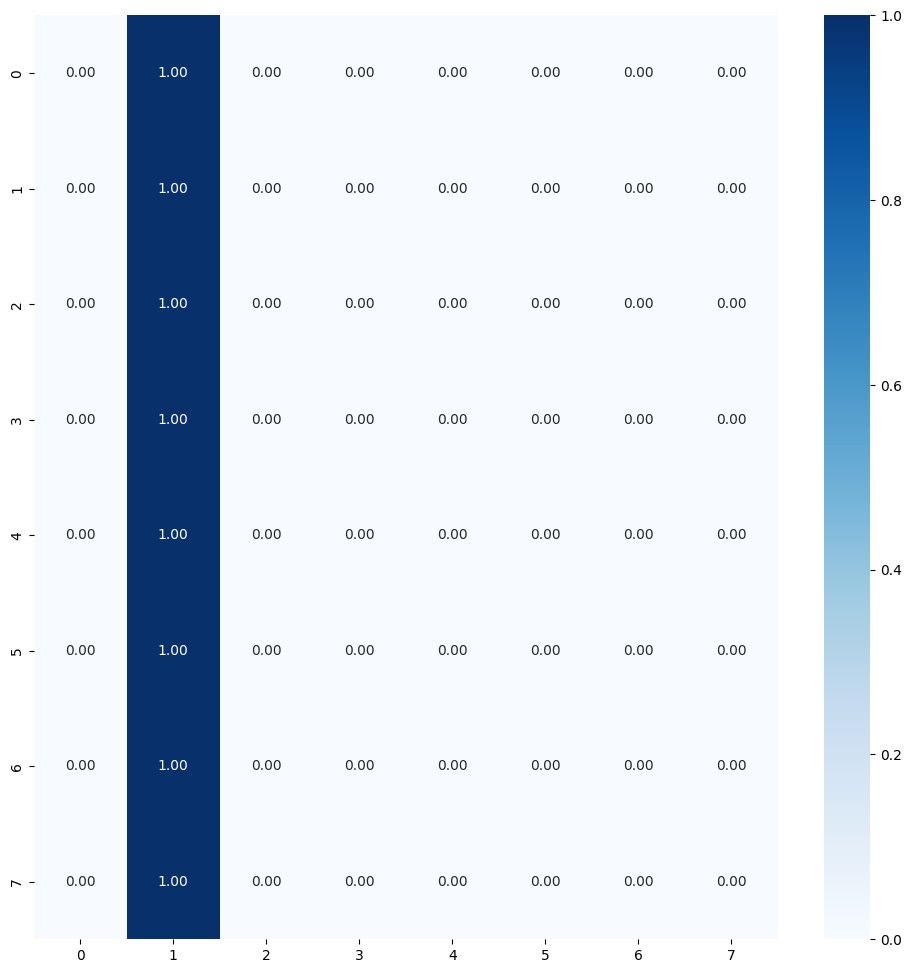

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3759816
Trainable params: 2118152
Non-trainable params: 1641664
Epoch 1/50
262/262 [==============================] - 54s 171ms/step - loss: 5.8856 - accuracy: 0.1164 - val_loss: 3.8488 - val_accuracy: 0.1250
Epoch 2/50
262/262 [==============================] - 37s 139ms/step - loss: 2.9965 - accuracy: 0.1200 - val_loss: 2.4502 - val_accuracy: 0.1250
Epoch 3/50
262/262 [==============================] - 41s 155ms/step - loss: 2.2533 - accuracy: 0.1195 - val_loss: 2.1375 - val_accuracy: 0.1250
Epoch 4/50
262/262 [==============================] - 43s 163ms/step - loss: 2.1038 - accuracy: 0.1188 - val_loss: 2.0859 - val_accuracy: 0.1244
Epoch 5/50
262/262 [==============================] - 36s 135ms/step - loss: 2.0820 - accuracy: 0.1202 - val_loss: 2.0799 - val_accuracy: 0.1244
Epoch 6/50
262/262 [==============================] - 42s 158ms/step - loss: 2.0799 - accuracy: 0.1206 - val_loss: 2.0795 - val_accuracy: 0.1256
Epoch 7/50
262

Model and History saved...
263/263 [==============================] - 34s 129ms/step - loss: 2.0795 - accuracy: 0.1250
Train Accuracy: 0.125
Train Log Loss: 2.0794517993927
57/57 [==============================] - 7s 128ms/step - loss: 2.0795 - accuracy: 0.1250
Validation Accuracy: 0.125
Validation Log Loss: 2.0794517993927
57/57 [==============================] - 7s 128ms/step - loss: 2.0795 - accuracy: 0.1250
Test Accuracy: 0.125
Test Log Loss: 2.079451560974121
Test labels: {'Allaple.A': 0, 'Kelihos_ver3': 1, 'Ramnit': 2, 'ganelp': 3, 'mira': 4, 'sfone': 5, 'sillyp2p': 6, 'wabot': 7}

Matriz de Confusión:
[[  0   0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0   0]
 [  0   0   0 225   0   0   0   0]]
True labels: 1800
Predicted labels: len(predicted_labels)

Classification report:
              precisi

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


57/57 [==============================] - 8s 118ms/step


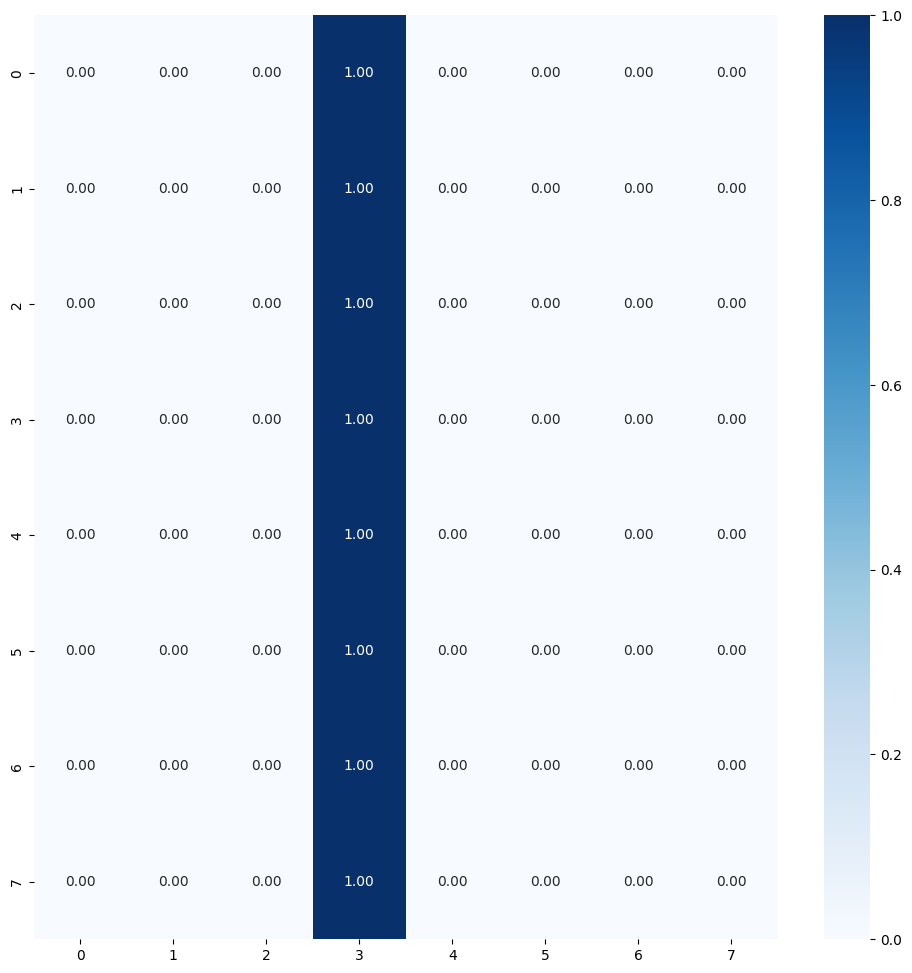

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.12927820384502411
Average validation precision in 5-fold: 0.1255580335855484
/nTest Metrics
test_acc_list: [0.125, 0.125, 0.125, 0.125, 0.125]
Average Test Accuracy with 5-fold: 0.125
test_loss_list: [2.0794456005096436, 2.0794565677642822, 2.0794503688812256, 2.079444646835327, 2.079451560974121]
Average Test Log Loss with 5-fold: 2.07944974899292

Precision List: [0.015625, 0.015625, 0.015625, 0.015625, 0.015625]
Average Precision List with 5-fold: 0.015625
Recall List: [0.125, 0.125, 0.125, 0.125, 0.125]
Average Recall List with 5-fold: 0.125
F1 Score List: [0.027777777777777776, 0.027777777777777776, 0.027777777777777776, 0.027777777777777776, 0.027777777777777776]
Average F1 Score List with 5-fold: 0.02777777777777778

Metrics List Store

test_acc_list_all = [0.5, 0.3333333432674408, 0.25, 0.20000000298023224, 0.1666666716337204, 0.1428571492433548, 0.125]
test_loss_list_all = [0.6931522369384766, 1.098618984222412, 1.3862980842590331, 1.6094

In [16]:
%%time

num_classes = 8
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/9
name_save_model: fusion_VGG16_basic_9
Found 9450 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Found 2025 images belonging to 9 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3760329
Trainable params: 2118665
Non-trainable params: 1641664
Epoch 1/50
295/295 [==============================] - 58s 167ms/step - loss: 5.7666 - accuracy: 0.1061 - val_loss: 3.6751 - val_accuracy: 0.1111
Epoch 2/50
295/295 [==============================] - 41s 137ms/step - loss: 2.9006 - accuracy: 0.1109 - val_loss: 2.4380 - val_accuracy: 0.1116
Epoch 3/50
295/295 [==============================] - 51s 171ms/step - loss: 2.2982 - accuracy: 0.1094 - val_loss: 2.2238 - val_accuracy: 0.1096
Epoch 4/50
295/295 [==============================] - 41s 139ms/step - loss: 2.

Model and History saved...
296/296 [==============================] - 38s 128ms/step - loss: 2.1972 - accuracy: 0.1111
Train Accuracy: 0.1111111119389534
Train Log Loss: 2.197237491607666
64/64 [==============================] - 8s 116ms/step - loss: 2.1972 - accuracy: 0.1111
Validation Accuracy: 0.1111111119389534
Validation Log Loss: 2.197237491607666
64/64 [==============================] - 6s 87ms/step - loss: 2.1972 - accuracy: 0.1111
Test Accuracy: 0.1111111119389534
Test Log Loss: 2.197237491607666
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


64/64 [==============================] - 9s 121ms/step


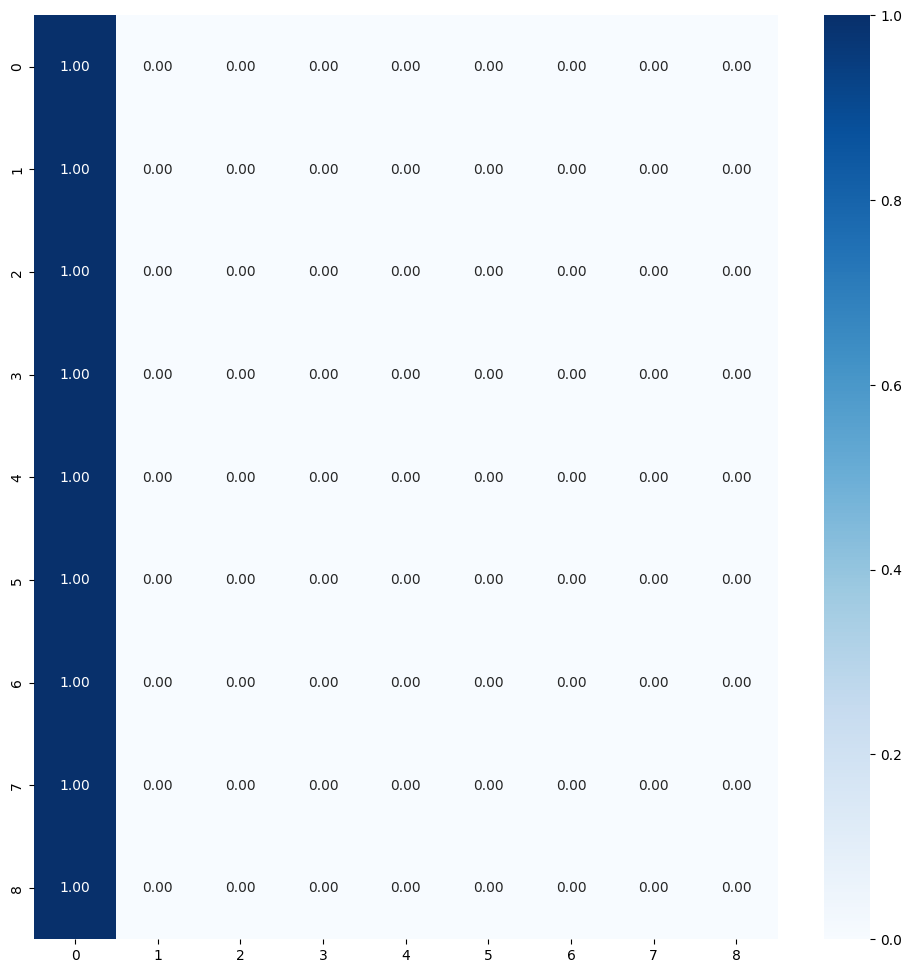

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3760329
Trainable params: 2118665
Non-trainable params: 1641664
Epoch 1/50
295/295 [==============================] - 57s 162ms/step - loss: 5.7570 - accuracy: 0.1101 - val_loss: 3.6683 - val_accuracy: 0.1116
Epoch 2/50
295/295 [==============================] - 39s 133ms/step - loss: 2.8949 - accuracy: 0.1051 - val_loss: 2.4364 - val_accuracy: 0.1106
Epoch 3/50
295/295 [==============================] - 45s 154ms/step - loss: 2.2976 - accuracy: 0.1114 - val_loss: 2.2235 - val_accuracy: 0.1106
Epoch 4/50
295/295 [==============================] - 45s 154ms/step - loss: 2.2070 - accuracy: 0.1070 - val_loss: 2.1990 - val_accuracy: 0.1111
Epoch 5/50
295/295 [==============================] - 40s 135ms/step - loss: 2.1980 - accuracy: 0.1068 - val_loss: 2.1973 - val_accuracy: 0.1116
Epoch 6/50
295/295 [==============================] - 48s 162ms/step - loss: 2.1974 - accuracy: 0.1058 - val_loss: 2.1972 - val_accuracy: 0.1111
Epoch 7/50
295

Model and History saved...
296/296 [==============================] - 36s 122ms/step - loss: 2.1972 - accuracy: 0.1111
Train Accuracy: 0.1111111119389534
Train Log Loss: 2.197230577468872
64/64 [==============================] - 5s 83ms/step - loss: 2.1972 - accuracy: 0.1111
Validation Accuracy: 0.1111111119389534
Validation Log Loss: 2.197230577468872
64/64 [==============================] - 6s 99ms/step - loss: 2.1972 - accuracy: 0.1111
Test Accuracy: 0.1111111119389534
Test Log Loss: 2.197230577468872
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


64/64 [==============================] - 10s 127ms/step


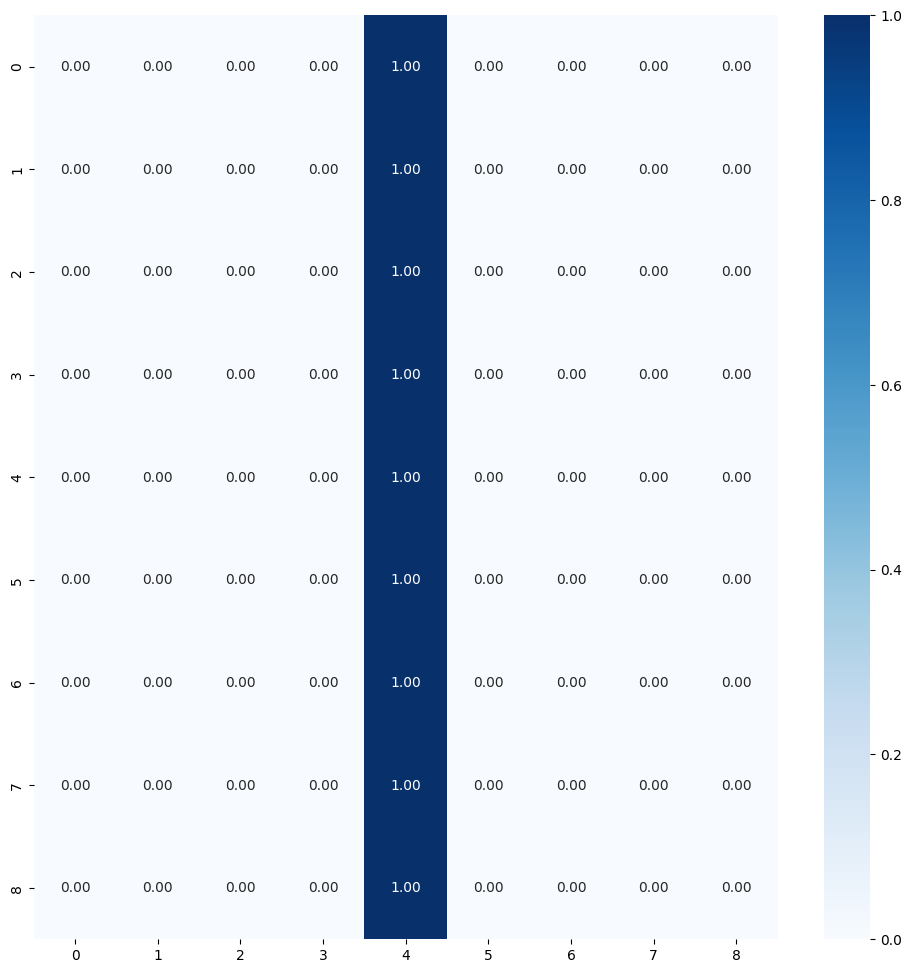

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3760329
Trainable params: 2118665
Non-trainable params: 1641664
Epoch 1/50
295/295 [==============================] - 58s 160ms/step - loss: 5.7581 - accuracy: 0.1084 - val_loss: 3.6707 - val_accuracy: 0.1111
Epoch 2/50
295/295 [==============================] - 39s 132ms/step - loss: 2.8976 - accuracy: 0.0997 - val_loss: 2.4364 - val_accuracy: 0.1111
Epoch 3/50
295/295 [==============================] - 46s 155ms/step - loss: 2.2976 - accuracy: 0.1056 - val_loss: 2.2235 - val_accuracy: 0.1111
Epoch 4/50
295/295 [==============================] - 41s 137ms/step - loss: 2.2070 - accuracy: 0.1060 - val_loss: 2.1990 - val_accuracy: 0.1116
Epoch 5/50
295/295 [==============================] - 45s 154ms/step - loss: 2.1980 - accuracy: 0.1017 - val_loss: 2.1973 - val_accuracy: 0.1111
Epoch 6/50
295/295 [==============================] - 45s 152ms/step - loss: 2.1975 - accuracy: 0.1083 - val_loss: 2.1972 - val_accuracy: 0.1116
Epoch 7/50
295

Model and History saved...
296/296 [==============================] - 29s 97ms/step - loss: 2.1972 - accuracy: 0.1111
Train Accuracy: 0.1111111119389534
Train Log Loss: 2.1972336769104004
64/64 [==============================] - 5s 80ms/step - loss: 2.1972 - accuracy: 0.1111
Validation Accuracy: 0.1111111119389534
Validation Log Loss: 2.197233200073242
64/64 [==============================] - 5s 82ms/step - loss: 2.1972 - accuracy: 0.1111
Test Accuracy: 0.1111111119389534
Test Log Loss: 2.197233200073242
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[  0   0 225   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0]
 [  0   0 225  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


64/64 [==============================] - 6s 79ms/step


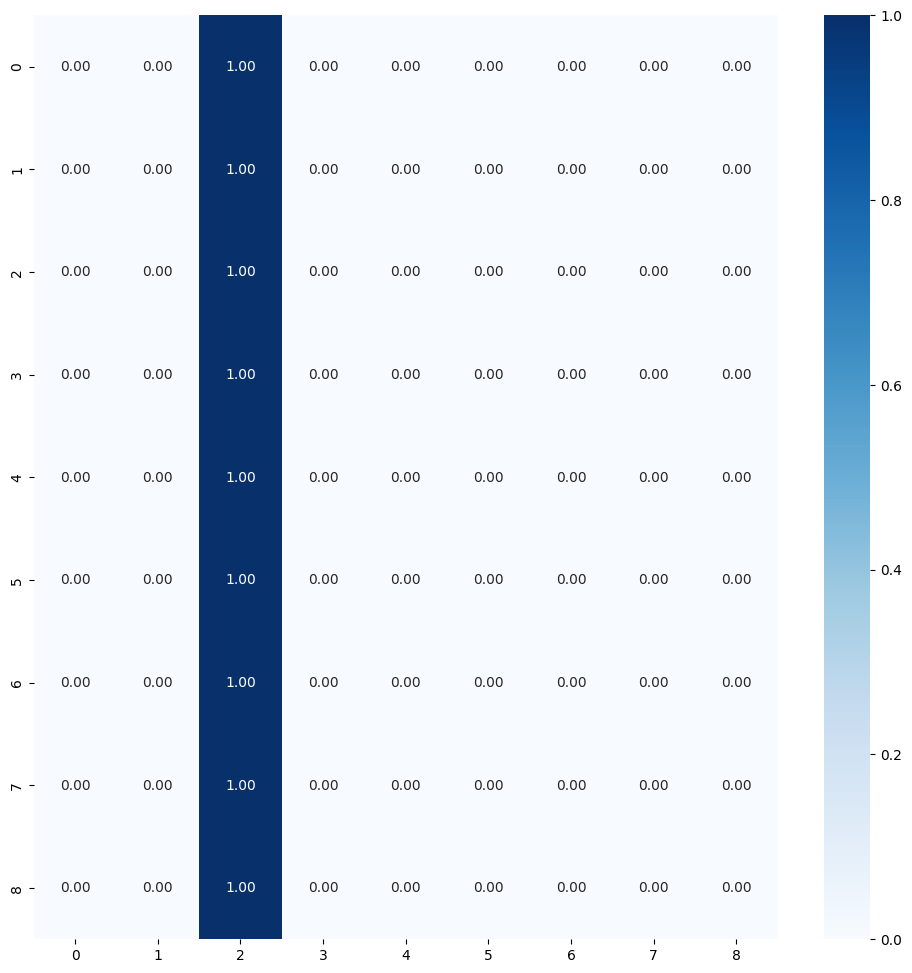

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3760329
Trainable params: 2118665
Non-trainable params: 1641664
Epoch 1/50
295/295 [==============================] - 39s 115ms/step - loss: 5.7561 - accuracy: 0.1048 - val_loss: 3.6736 - val_accuracy: 0.1111
Epoch 2/50
295/295 [==============================] - 46s 154ms/step - loss: 2.8979 - accuracy: 0.1079 - val_loss: 2.4373 - val_accuracy: 0.1111
Epoch 3/50
295/295 [==============================] - 46s 155ms/step - loss: 2.2980 - accuracy: 0.1006 - val_loss: 2.2237 - val_accuracy: 0.1101
Epoch 4/50
295/295 [==============================] - 39s 131ms/step - loss: 2.2070 - accuracy: 0.1063 - val_loss: 2.1990 - val_accuracy: 0.1111
Epoch 5/50
295/295 [==============================] - 47s 157ms/step - loss: 2.1980 - accuracy: 0.1080 - val_loss: 2.1973 - val_accuracy: 0.1111
Epoch 6/50
295/295 [==============================] - 41s 139ms/step - loss: 2.1974 - accuracy: 0.1054 - val_loss: 2.1972 - val_accuracy: 0.1116
Epoch 7/50
295

Model and History saved...
296/296 [==============================] - 38s 128ms/step - loss: 2.1972 - accuracy: 0.1111
Train Accuracy: 0.1111111119389534
Train Log Loss: 2.197226047515869
64/64 [==============================] - 9s 134ms/step - loss: 2.1972 - accuracy: 0.1111
Validation Accuracy: 0.1111111119389534
Validation Log Loss: 2.1972274780273438
64/64 [==============================] - 8s 128ms/step - loss: 2.1972 - accuracy: 0.1111
Test Accuracy: 0.1111111119389534
Test Log Loss: 2.197227954864502
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0]
 [  0   0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


64/64 [==============================] - 10s 128ms/step


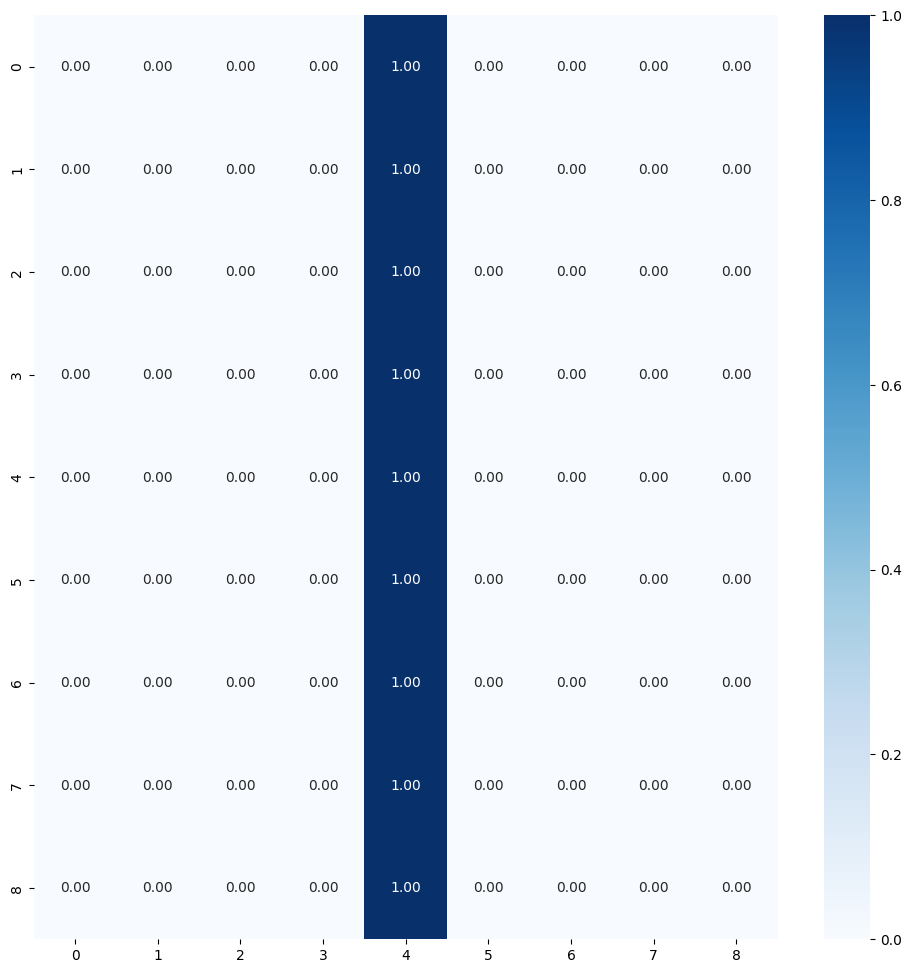

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3760329
Trainable params: 2118665
Non-trainable params: 1641664
Epoch 1/50
295/295 [==============================] - 51s 144ms/step - loss: 5.7571 - accuracy: 0.1052 - val_loss: 3.6735 - val_accuracy: 0.1111
Epoch 2/50
295/295 [==============================] - 46s 154ms/step - loss: 2.8982 - accuracy: 0.1058 - val_loss: 2.4374 - val_accuracy: 0.1106
Epoch 3/50
295/295 [==============================] - 46s 156ms/step - loss: 2.2980 - accuracy: 0.1073 - val_loss: 2.2237 - val_accuracy: 0.1101
Epoch 4/50
295/295 [==============================] - 40s 135ms/step - loss: 2.2070 - accuracy: 0.1084 - val_loss: 2.1990 - val_accuracy: 0.1116
Epoch 5/50
295/295 [==============================] - 45s 153ms/step - loss: 2.1980 - accuracy: 0.1053 - val_loss: 2.1973 - val_accuracy: 0.1116
Epoch 6/50
295/295 [==============================] - 43s 145ms/step - loss: 2.1974 - accuracy: 0.1081 - val_loss: 2.1972 - val_accuracy: 0.1116
Epoch 7/50
295

Model and History saved...
296/296 [==============================] - 37s 125ms/step - loss: 2.1972 - accuracy: 0.1111
Train Accuracy: 0.1111111119389534
Train Log Loss: 2.1972274780273438
64/64 [==============================] - 8s 124ms/step - loss: 2.1972 - accuracy: 0.1111
Validation Accuracy: 0.1111111119389534
Validation Log Loss: 2.197227716445923
64/64 [==============================] - 8s 122ms/step - loss: 2.1972 - accuracy: 0.1111
Test Accuracy: 0.1111111119389534
Test Log Loss: 2.1972267627716064
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0]
 [225   0  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


64/64 [==============================] - 9s 125ms/step


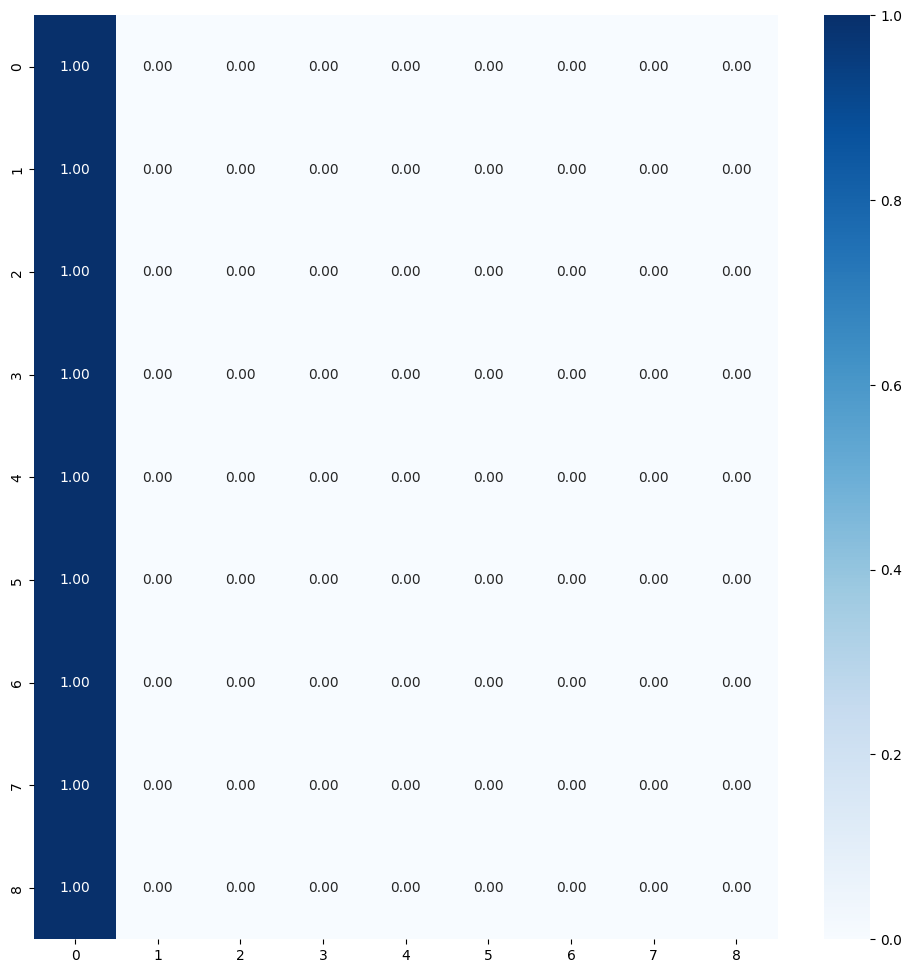

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.11335740089416504
Average validation precision in 5-fold: 0.1116071417927742
/nTest Metrics
test_acc_list: [0.1111111119389534, 0.1111111119389534, 0.1111111119389534, 0.1111111119389534, 0.1111111119389534]
Average Test Accuracy with 5-fold: 0.1111111119389534
test_loss_list: [2.197237491607666, 2.197230577468872, 2.197233200073242, 2.197227954864502, 2.1972267627716064]
Average Test Log Loss with 5-fold: 2.1972311973571776

Precision List: [0.012345679012345678, 0.012345679012345678, 0.012345679012345678, 0.012345679012345678, 0.012345679012345678]
Average Precision List with 5-fold: 0.012345679012345678
Recall List: [0.1111111111111111, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111, 0.1111111111111111]
Average Recall List with 5-fold: 0.11111111111111112
F1 Score List: [0.022222222222222223, 0.022222222222222223, 0.022222222222222223, 0.022222222222222223, 0.022222222222222223]
Average F1 Score List with 5-fold: 0.02222222222222222

In [17]:
%%time

num_classes = 9
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/10
name_save_model: fusion_VGG16_basic_10
Found 10500 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Found 2250 images belonging to 10 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3760842
Trainable params: 2119178
Non-trainable params: 1641664
Epoch 1/50
328/328 [==============================] - 57s 157ms/step - loss: 5.6403 - accuracy: 0.0927 - val_loss: 3.5253 - val_accuracy: 0.1000
Epoch 2/50
328/328 [==============================] - 50s 152ms/step - loss: 2.8363 - accuracy: 0.0946 - val_loss: 2.4545 - val_accuracy: 0.1000
Epoch 3/50
328/328 [==============================] - 48s 146ms/step - loss: 2.3596 - accuracy: 0.0926 - val_loss: 2.3140 - val_accuracy: 0.1004
Epoch 4/50
328/328 [==============================] - 50s 153ms

Model and History saved...
329/329 [==============================] - 43s 131ms/step - loss: 2.3026 - accuracy: 0.1000
Train Accuracy: 0.10000000149011612
Train Log Loss: 2.3025963306427
71/71 [==============================] - 10s 132ms/step - loss: 2.3026 - accuracy: 0.1000
Validation Accuracy: 0.10000000149011612
Validation Log Loss: 2.3025946617126465
71/71 [==============================] - 10s 131ms/step - loss: 2.3026 - accuracy: 0.1000
Test Accuracy: 0.10000000149011612
Test Log Loss: 2.302595376968384
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0 225]
 [  0 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


71/71 [==============================] - 10s 131ms/step


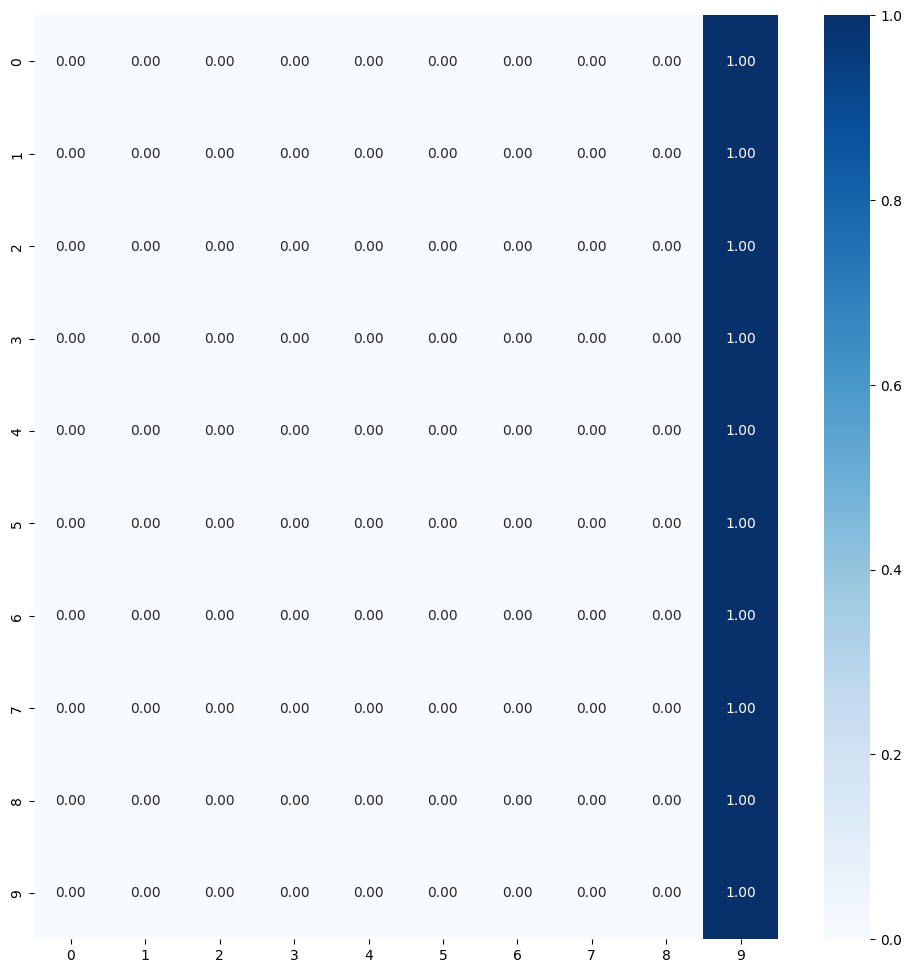

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3760842
Trainable params: 2119178
Non-trainable params: 1641664
Epoch 1/50
328/328 [==============================] - 62s 162ms/step - loss: 5.6448 - accuracy: 0.0928 - val_loss: 3.5268 - val_accuracy: 0.1004
Epoch 2/50
328/328 [==============================] - 46s 139ms/step - loss: 2.8373 - accuracy: 0.0946 - val_loss: 2.4546 - val_accuracy: 0.1004
Epoch 3/50
328/328 [==============================] - 50s 153ms/step - loss: 2.3597 - accuracy: 0.0966 - val_loss: 2.3140 - val_accuracy: 0.1000
Epoch 4/50
328/328 [==============================] - 52s 158ms/step - loss: 2.3063 - accuracy: 0.0972 - val_loss: 2.3031 - val_accuracy: 0.1000
Epoch 5/50
328/328 [==============================] - 51s 156ms/step - loss: 2.3030 - accuracy: 0.0951 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 6/50
328/328 [==============================] - 51s 157ms/step - loss: 2.3028 - accuracy: 0.0925 - val_loss: 2.3026 - val_accuracy: 0.1004
Epoch 7/50
328

Model and History saved...
329/329 [==============================] - 41s 125ms/step - loss: 2.3026 - accuracy: 0.1000
Train Accuracy: 0.10000000149011612
Train Log Loss: 2.30259108543396
71/71 [==============================] - 9s 127ms/step - loss: 2.3026 - accuracy: 0.1000
Validation Accuracy: 0.10000000149011612
Validation Log Loss: 2.3025918006896973
71/71 [==============================] - 9s 123ms/step - loss: 2.3026 - accuracy: 0.1000
Test Accuracy: 0.10000000149011612
Test Log Loss: 2.3025920391082764
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[  0 225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0]
 [  0 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


71/71 [==============================] - 10s 125ms/step


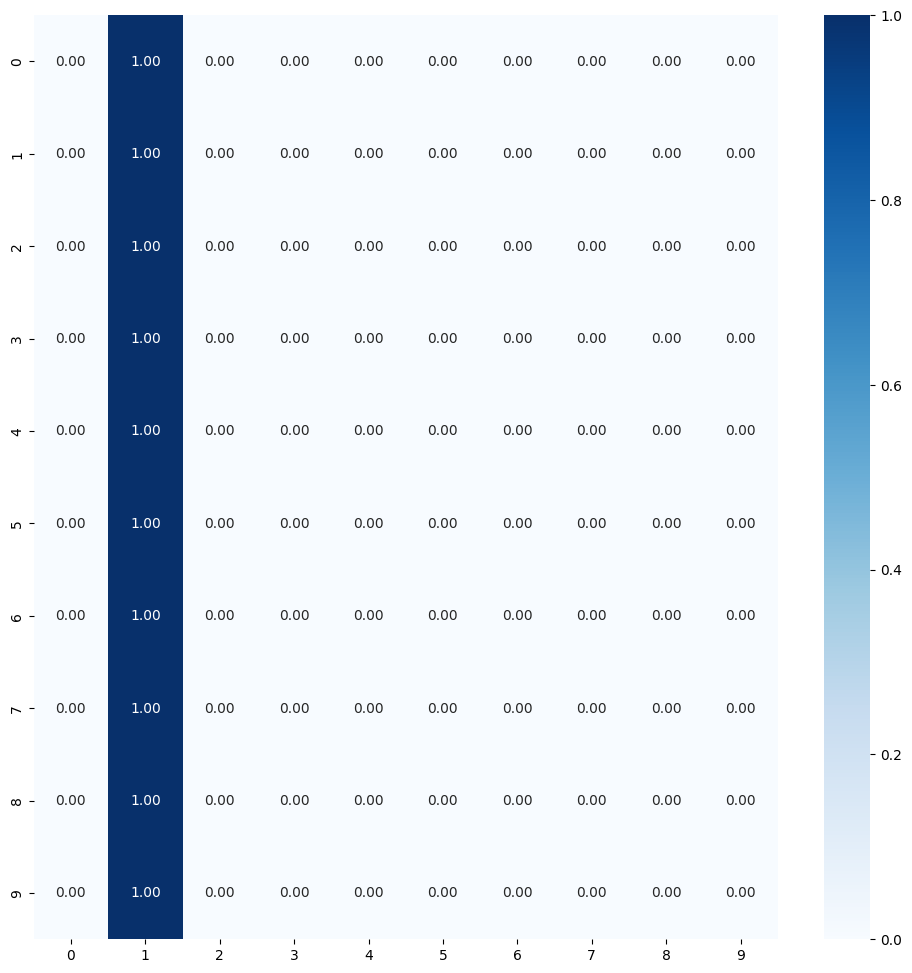

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3760842
Trainable params: 2119178
Non-trainable params: 1641664
Epoch 1/50
328/328 [==============================] - 58s 150ms/step - loss: 5.6470 - accuracy: 0.0989 - val_loss: 3.5261 - val_accuracy: 0.0996
Epoch 2/50
328/328 [==============================] - 50s 152ms/step - loss: 2.8366 - accuracy: 0.0916 - val_loss: 2.4545 - val_accuracy: 0.1000
Epoch 3/50
328/328 [==============================] - 45s 136ms/step - loss: 2.3595 - accuracy: 0.0956 - val_loss: 2.3140 - val_accuracy: 0.1000
Epoch 4/50
328/328 [==============================] - 51s 157ms/step - loss: 2.3063 - accuracy: 0.0970 - val_loss: 2.3030 - val_accuracy: 0.1004
Epoch 5/50
328/328 [==============================] - 45s 137ms/step - loss: 2.3029 - accuracy: 0.0964 - val_loss: 2.3026 - val_accuracy: 0.1004
Epoch 6/50
328/328 [==============================] - 52s 158ms/step - loss: 2.3028 - accuracy: 0.0889 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 7/50
328

Model and History saved...
329/329 [==============================] - 41s 123ms/step - loss: 2.3026 - accuracy: 0.1000
Train Accuracy: 0.10000000149011612
Train Log Loss: 2.302593946456909
71/71 [==============================] - 9s 127ms/step - loss: 2.3026 - accuracy: 0.1000
Validation Accuracy: 0.10000000149011612
Validation Log Loss: 2.302593946456909
71/71 [==============================] - 9s 126ms/step - loss: 2.3026 - accuracy: 0.1000
Test Accuracy: 0.10000000149011612
Test Log Loss: 2.30259370803833
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[  0   0   0 225   0   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0   0   0]
 [  0   0   0 225   0   0   0   0   0   0]
 [  0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


71/71 [==============================] - 10s 123ms/step


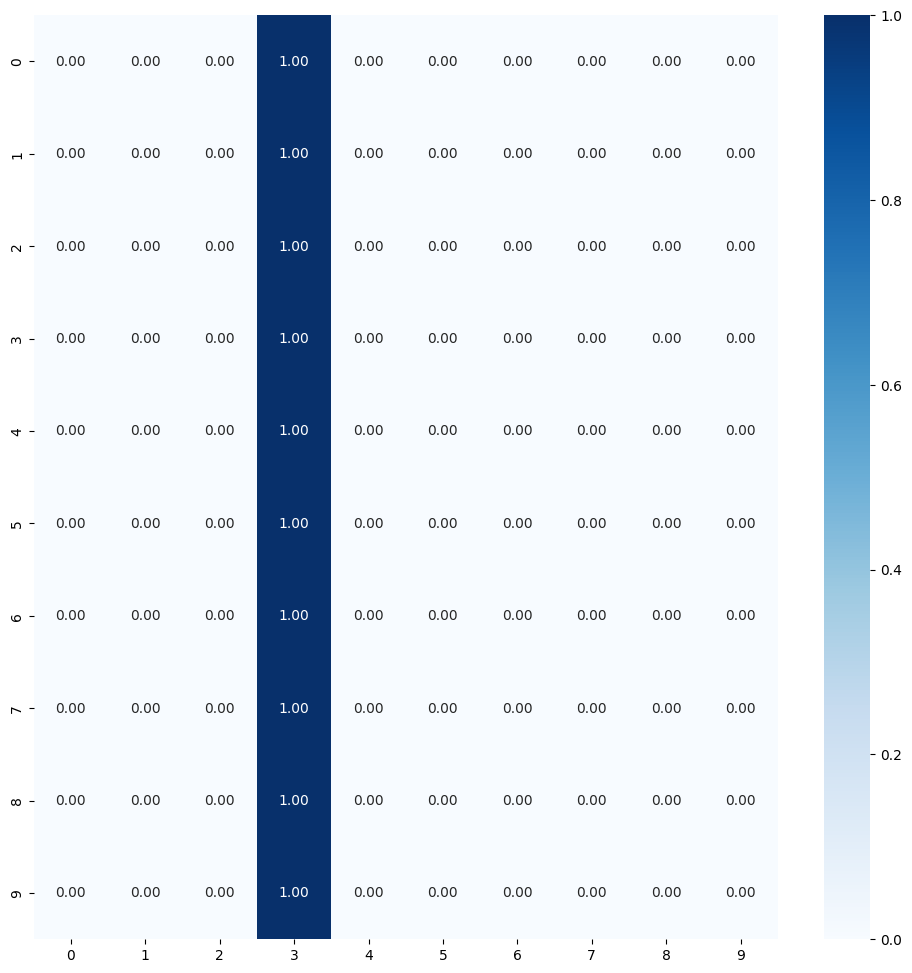

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3760842
Trainable params: 2119178
Non-trainable params: 1641664
Epoch 1/50
328/328 [==============================] - 60s 158ms/step - loss: 5.6391 - accuracy: 0.0998 - val_loss: 3.5243 - val_accuracy: 0.0991
Epoch 2/50
328/328 [==============================] - 47s 142ms/step - loss: 2.8355 - accuracy: 0.0954 - val_loss: 2.4542 - val_accuracy: 0.1004
Epoch 3/50
328/328 [==============================] - 45s 138ms/step - loss: 2.3596 - accuracy: 0.0933 - val_loss: 2.3139 - val_accuracy: 0.0996
Epoch 4/50
328/328 [==============================] - 51s 155ms/step - loss: 2.3064 - accuracy: 0.0951 - val_loss: 2.3030 - val_accuracy: 0.1004
Epoch 5/50
328/328 [==============================] - 42s 127ms/step - loss: 2.3030 - accuracy: 0.0991 - val_loss: 2.3026 - val_accuracy: 0.1004
Epoch 6/50
328/328 [==============================] - 50s 152ms/step - loss: 2.3028 - accuracy: 0.0952 - val_loss: 2.3026 - val_accuracy: 0.1004
Epoch 7/50
328

Model and History saved...
329/329 [==============================] - 40s 120ms/step - loss: 2.3026 - accuracy: 0.1000
Train Accuracy: 0.10000000149011612
Train Log Loss: 2.3025944232940674
71/71 [==============================] - 11s 149ms/step - loss: 2.3026 - accuracy: 0.1000
Validation Accuracy: 0.10000000149011612
Validation Log Loss: 2.3025941848754883
71/71 [==============================] - 11s 148ms/step - loss: 2.3026 - accuracy: 0.1000
Test Accuracy: 0.10000000149011612
Test Log Loss: 2.3025949001312256
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[  0   0 225   0   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0   0]
 [  0   0 225   0   0   0   0   0   0   0]
 [

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


71/71 [==============================] - 12s 148ms/step


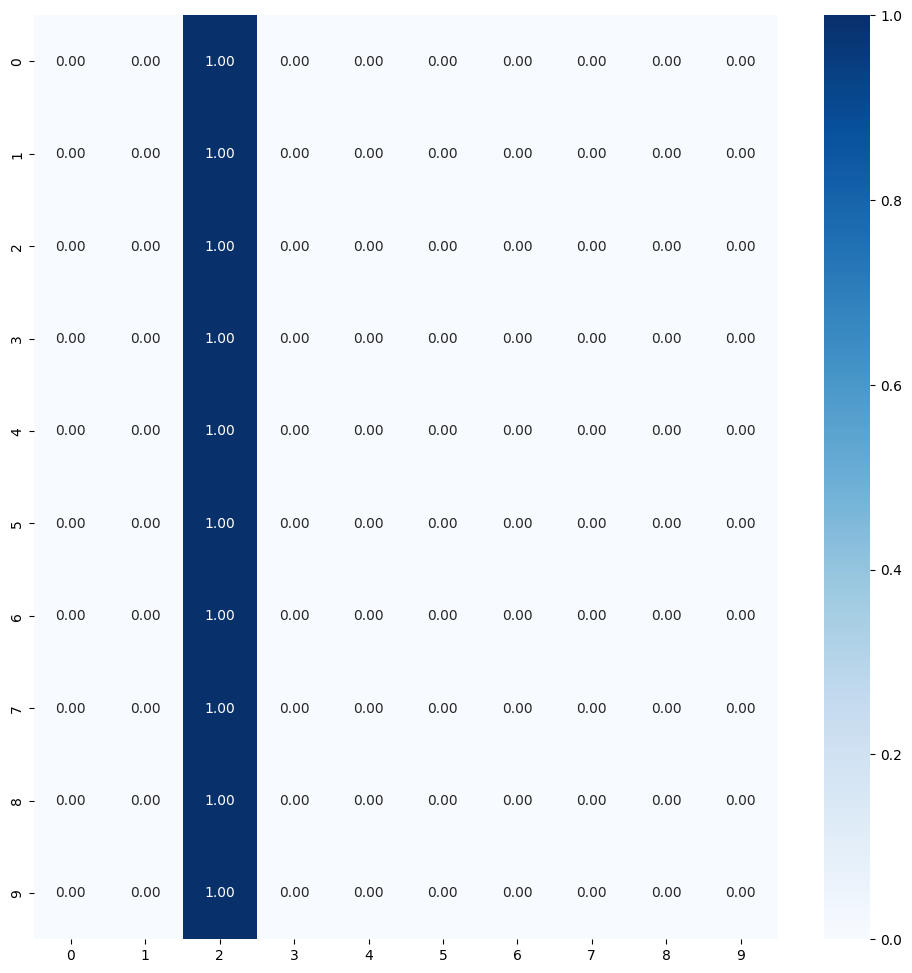

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3760842
Trainable params: 2119178
Non-trainable params: 1641664
Epoch 1/50
328/328 [==============================] - 62s 158ms/step - loss: 5.6371 - accuracy: 0.0974 - val_loss: 3.5212 - val_accuracy: 0.0996
Epoch 2/50
328/328 [==============================] - 60s 183ms/step - loss: 2.8344 - accuracy: 0.0937 - val_loss: 2.4538 - val_accuracy: 0.1004
Epoch 3/50
328/328 [==============================] - 60s 181ms/step - loss: 2.3594 - accuracy: 0.0917 - val_loss: 2.3139 - val_accuracy: 0.0996
Epoch 4/50
328/328 [==============================] - 62s 188ms/step - loss: 2.3063 - accuracy: 0.0940 - val_loss: 2.3031 - val_accuracy: 0.1004
Epoch 5/50
328/328 [==============================] - 70s 215ms/step - loss: 2.3029 - accuracy: 0.0968 - val_loss: 2.3026 - val_accuracy: 0.0996
Epoch 6/50
328/328 [==============================] - 50s 152ms/step - loss: 2.3028 - accuracy: 0.0924 - val_loss: 2.3026 - val_accuracy: 0.1000
Epoch 7/50
328

Model and History saved...
329/329 [==============================] - 46s 138ms/step - loss: 2.3026 - accuracy: 0.1000
Train Accuracy: 0.10000000149011612
Train Log Loss: 2.3025901317596436
71/71 [==============================] - 6s 87ms/step - loss: 2.3026 - accuracy: 0.1000
Validation Accuracy: 0.10000000149011612
Validation Log Loss: 2.3025906085968018
71/71 [==============================] - 6s 81ms/step - loss: 2.3026 - accuracy: 0.1000
Test Accuracy: 0.10000000149011612
Test Log Loss: 2.3025906085968018
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'ganelp': 4, 'mira': 5, 'sfone': 6, 'sillyp2p': 7, 'wabot': 8, 'wacatac': 9}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0 225   0]
 [  0 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


71/71 [==============================] - 7s 84ms/step


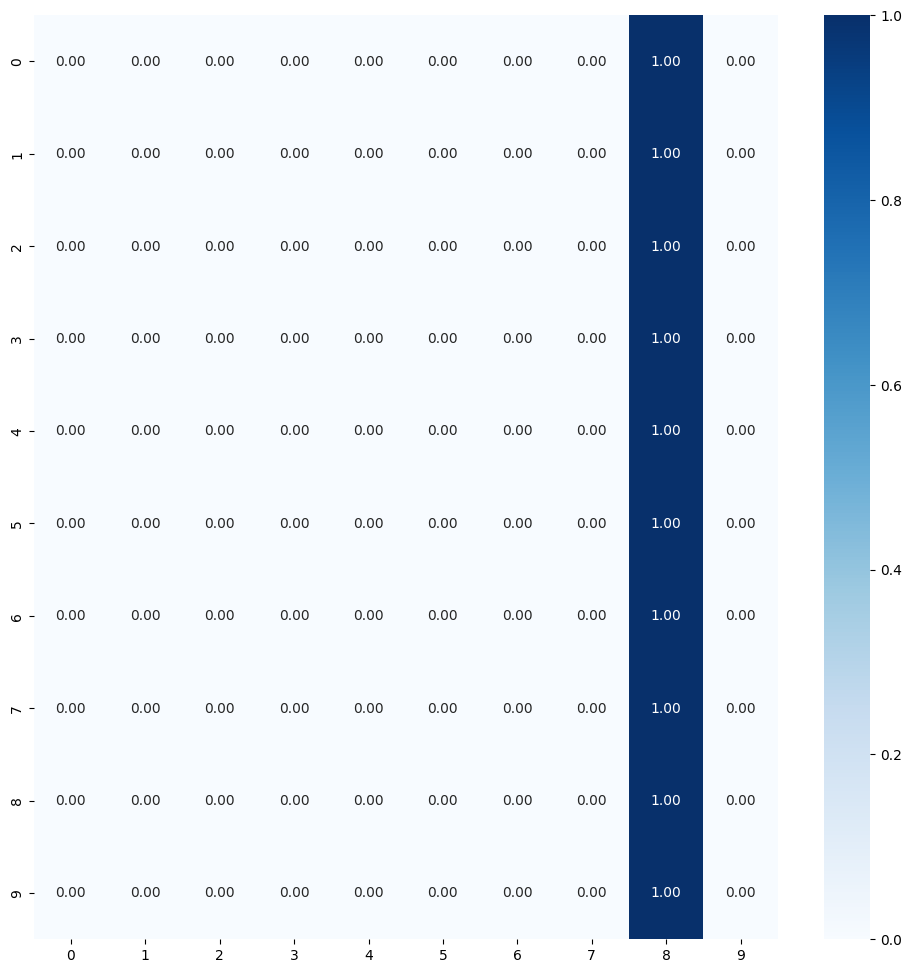

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.10257928669452668
Average validation precision in 5-fold: 0.1004464253783226
/nTest Metrics
test_acc_list: [0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612]
Average Test Accuracy with 5-fold: 0.10000000149011612
test_loss_list: [2.302595376968384, 2.3025920391082764, 2.30259370803833, 2.3025949001312256, 2.3025906085968018]
Average Test Log Loss with 5-fold: 2.3025933265686036

Precision List: [0.01, 0.01, 0.01, 0.01, 0.01]
Average Precision List with 5-fold: 0.01
Recall List: [0.1, 0.1, 0.1, 0.1, 0.1]
Average Recall List with 5-fold: 0.1
F1 Score List: [0.01818181818181818, 0.01818181818181818, 0.01818181818181818, 0.01818181818181818, 0.01818181818181818]
Average F1 Score List with 5-fold: 0.01818181818181818

Metrics List Store

test_acc_list_all = [0.5, 0.3333333432674408, 0.25, 0.20000000298023224, 0.1666666716337204, 0.1428571492433548, 0.125, 0.1111111119389534, 0.10000000149011612]
te

In [18]:
%%time

num_classes = 10
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/11
name_save_model: fusion_VGG16_basic_11
Found 11550 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Found 2475 images belonging to 11 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3761355
Trainable params: 2119691
Non-trainable params: 1641664
Epoch 1/50
360/360 [==============================] - 46s 112ms/step - loss: 5.5422 - accuracy: 0.0839 - val_loss: 3.4155 - val_accuracy: 0.0905
Epoch 2/50
360/360 [==============================] - 60s 166ms/step - loss: 2.8064 - accuracy: 0.0852 - val_loss: 2.4937 - val_accuracy: 0.0913
Epoch 3/50
360/360 [==============================] - 56s 156ms/step - loss: 2.4302 - accuracy: 0.0812 - val_loss: 2.4027 - val_accuracy: 0.0897
Epoch 4/50
360/360 [==============================] - 

Model and History saved...
361/361 [==============================] - 48s 131ms/step - loss: 2.3979 - accuracy: 0.0909
Train Accuracy: 0.09090909361839294
Train Log Loss: 2.39790678024292
78/78 [==============================] - 12s 148ms/step - loss: 2.3979 - accuracy: 0.0909
Validation Accuracy: 0.09090909361839294
Validation Log Loss: 2.3979063034057617
78/78 [==============================] - 9s 108ms/step - loss: 2.3979 - accuracy: 0.0909
Test Accuracy: 0.09090909361839294
Test Log Loss: 2.3979063034057617
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


78/78 [==============================] - 12s 132ms/step


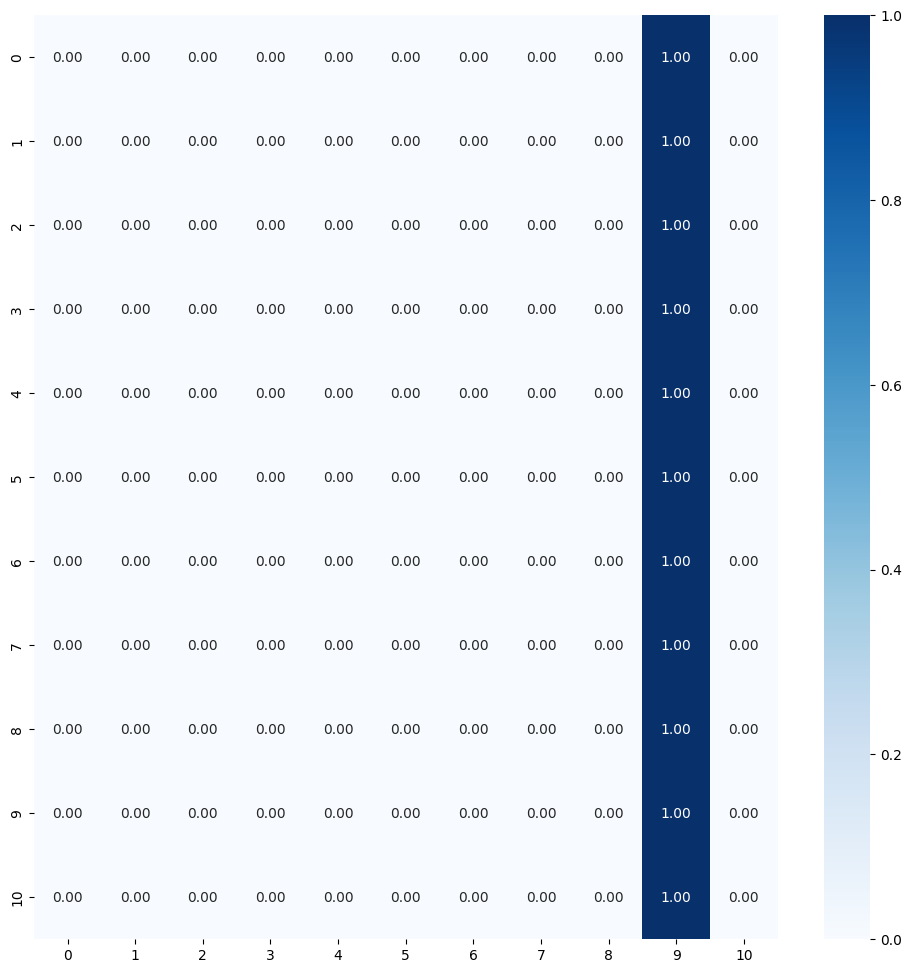

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3761355
Trainable params: 2119691
Non-trainable params: 1641664
Epoch 1/50
360/360 [==============================] - 69s 165ms/step - loss: 5.5326 - accuracy: 0.0839 - val_loss: 3.4119 - val_accuracy: 0.0909
Epoch 2/50
360/360 [==============================] - 46s 126ms/step - loss: 2.8047 - accuracy: 0.0852 - val_loss: 2.4932 - val_accuracy: 0.0913
Epoch 3/50
360/360 [==============================] - 36s 100ms/step - loss: 2.4300 - accuracy: 0.0867 - val_loss: 2.4026 - val_accuracy: 0.0913
Epoch 4/50
360/360 [==============================] - 42s 118ms/step - loss: 2.3993 - accuracy: 0.0885 - val_loss: 2.3980 - val_accuracy: 0.0909
Epoch 5/50
360/360 [==============================] - 61s 168ms/step - loss: 2.3981 - accuracy: 0.0868 - val_loss: 2.3979 - val_accuracy: 0.0913
Epoch 6/50
360/360 [==============================] - 51s 141ms/step - loss: 2.3981 - accuracy: 0.0834 - val_loss: 2.3979 - val_accuracy: 0.0913
Epoch 7/50
360

Model and History saved...
361/361 [==============================] - 49s 135ms/step - loss: 2.3979 - accuracy: 0.0909
Train Accuracy: 0.09090909361839294
Train Log Loss: 2.397899866104126
78/78 [==============================] - 11s 135ms/step - loss: 2.3979 - accuracy: 0.0909
Validation Accuracy: 0.09090909361839294
Validation Log Loss: 2.3978993892669678
78/78 [==============================] - 11s 134ms/step - loss: 2.3979 - accuracy: 0.0909
Test Accuracy: 0.09090909361839294
Test Log Loss: 2.397899627685547
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[  0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0]
 [  0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


78/78 [==============================] - 12s 131ms/step


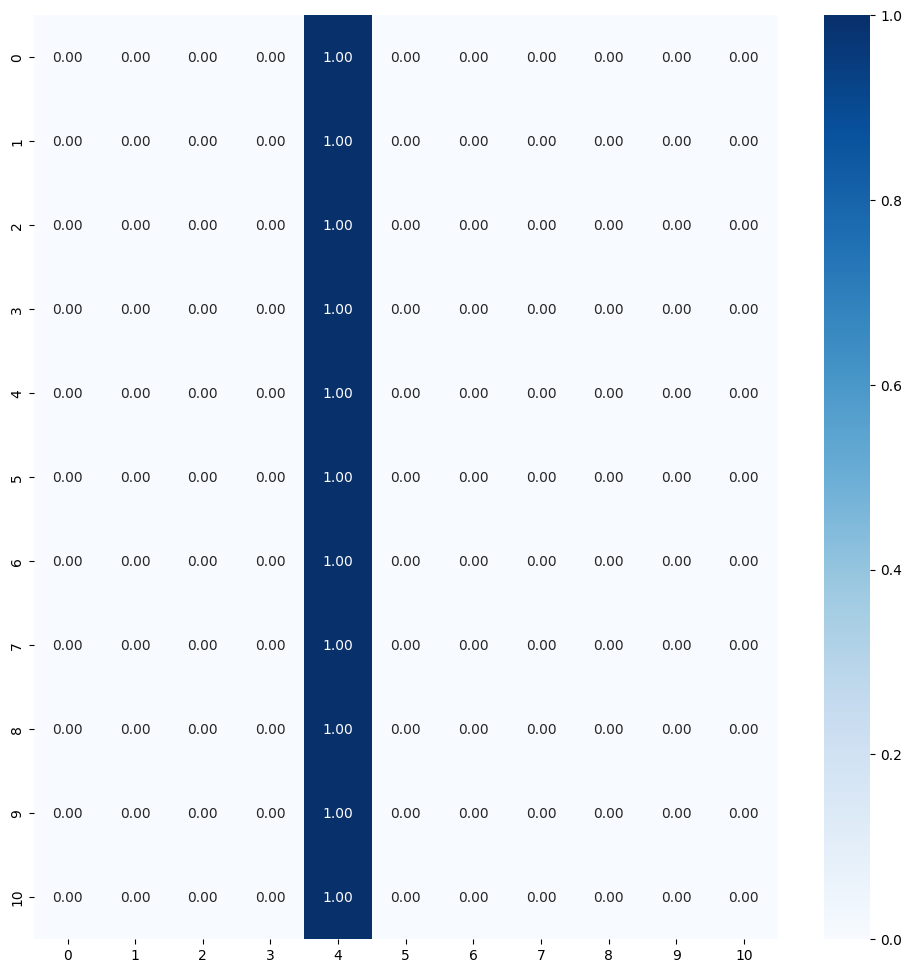

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3761355
Trainable params: 2119691
Non-trainable params: 1641664
Epoch 1/50
360/360 [==============================] - 62s 150ms/step - loss: 5.5450 - accuracy: 0.0896 - val_loss: 3.4173 - val_accuracy: 0.0913
Epoch 2/50
360/360 [==============================] - 58s 162ms/step - loss: 2.8072 - accuracy: 0.0886 - val_loss: 2.4939 - val_accuracy: 0.0909
Epoch 3/50
360/360 [==============================] - 51s 142ms/step - loss: 2.4303 - accuracy: 0.0886 - val_loss: 2.4027 - val_accuracy: 0.0901
Epoch 4/50
360/360 [==============================] - 58s 162ms/step - loss: 2.3994 - accuracy: 0.0850 - val_loss: 2.3980 - val_accuracy: 0.0913
Epoch 5/50
360/360 [==============================] - 37s 104ms/step - loss: 2.3982 - accuracy: 0.0844 - val_loss: 2.3979 - val_accuracy: 0.0905
Epoch 6/50
360/360 [==============================] - 42s 117ms/step - loss: 2.3981 - accuracy: 0.0859 - val_loss: 2.3979 - val_accuracy: 0.0913
Epoch 7/50
360

Model and History saved...
361/361 [==============================] - 43s 119ms/step - loss: 2.3979 - accuracy: 0.0909
Train Accuracy: 0.09090909361839294
Train Log Loss: 2.3979063034057617
78/78 [==============================] - 11s 142ms/step - loss: 2.3979 - accuracy: 0.0909
Validation Accuracy: 0.09090909361839294
Validation Log Loss: 2.3979058265686035
78/78 [==============================] - 11s 140ms/step - loss: 2.3979 - accuracy: 0.0909
Test Accuracy: 0.09090909361839294
Test Log Loss: 2.3979053497314453
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0   0   0   0   0   0   0   0   0 225   0]
 [  0  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


78/78 [==============================] - 12s 139ms/step


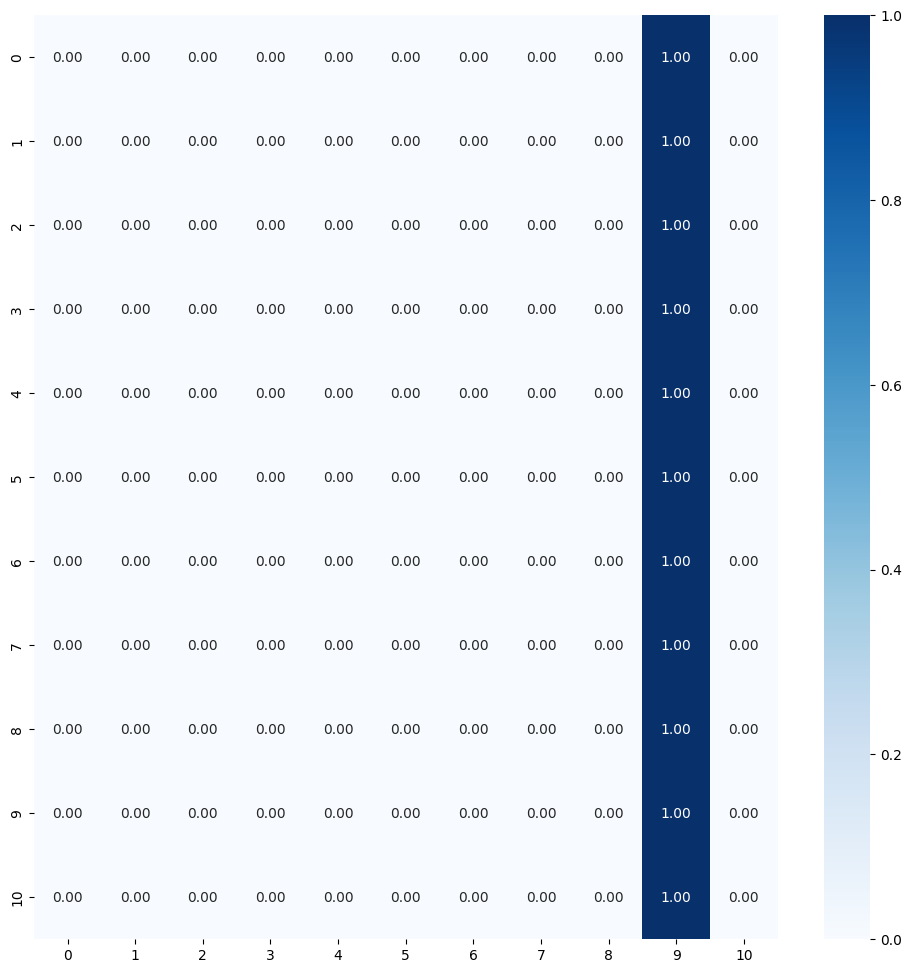

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3761355
Trainable params: 2119691
Non-trainable params: 1641664
Epoch 1/50
360/360 [==============================] - 65s 154ms/step - loss: 5.5351 - accuracy: 0.0828 - val_loss: 3.4128 - val_accuracy: 0.0897
Epoch 2/50
360/360 [==============================] - 63s 174ms/step - loss: 2.8051 - accuracy: 0.0836 - val_loss: 2.4933 - val_accuracy: 0.0913
Epoch 3/50
360/360 [==============================] - 56s 154ms/step - loss: 2.4300 - accuracy: 0.0879 - val_loss: 2.4026 - val_accuracy: 0.0913
Epoch 4/50
360/360 [==============================] - 60s 165ms/step - loss: 2.3993 - accuracy: 0.0882 - val_loss: 2.3980 - val_accuracy: 0.0909
Epoch 5/50
360/360 [==============================] - 62s 172ms/step - loss: 2.3982 - accuracy: 0.0881 - val_loss: 2.3979 - val_accuracy: 0.0909
Epoch 6/50
360/360 [==============================] - 55s 152ms/step - loss: 2.3981 - accuracy: 0.0862 - val_loss: 2.3979 - val_accuracy: 0.0905
Epoch 7/50
360

Model and History saved...
361/361 [==============================] - 48s 133ms/step - loss: 2.3979 - accuracy: 0.0909
Train Accuracy: 0.09090909361839294
Train Log Loss: 2.3979032039642334
78/78 [==============================] - 10s 131ms/step - loss: 2.3979 - accuracy: 0.0909
Validation Accuracy: 0.09090909361839294
Validation Log Loss: 2.3979034423828125
78/78 [==============================] - 11s 134ms/step - loss: 2.3979 - accuracy: 0.0909
Test Accuracy: 0.09090909361839294
Test Log Loss: 2.3979032039642334
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[  0 225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0]
 [  0 2

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


78/78 [==============================] - 12s 132ms/step


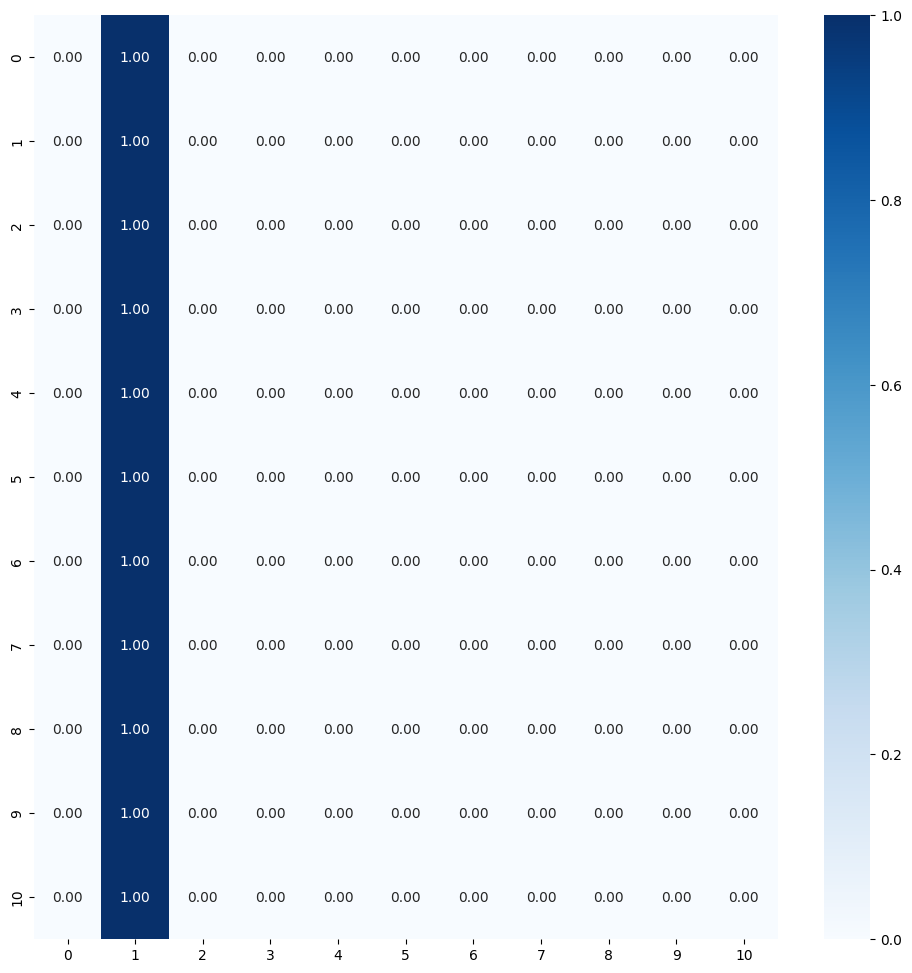

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3761355
Trainable params: 2119691
Non-trainable params: 1641664
Epoch 1/50
360/360 [==============================] - 63s 149ms/step - loss: 5.5339 - accuracy: 0.0859 - val_loss: 3.4122 - val_accuracy: 0.0905
Epoch 2/50
360/360 [==============================] - 56s 156ms/step - loss: 2.8047 - accuracy: 0.0897 - val_loss: 2.4933 - val_accuracy: 0.0905
Epoch 3/50
360/360 [==============================] - 59s 163ms/step - loss: 2.4300 - accuracy: 0.0872 - val_loss: 2.4027 - val_accuracy: 0.0905
Epoch 4/50
360/360 [==============================] - 51s 141ms/step - loss: 2.3994 - accuracy: 0.0892 - val_loss: 2.3980 - val_accuracy: 0.0913
Epoch 5/50
360/360 [==============================] - 58s 162ms/step - loss: 2.3981 - accuracy: 0.0909 - val_loss: 2.3979 - val_accuracy: 0.0913
Epoch 6/50
360/360 [==============================] - 52s 144ms/step - loss: 2.3980 - accuracy: 0.0882 - val_loss: 2.3979 - val_accuracy: 0.0913
Epoch 7/50
360

Model and History saved...
361/361 [==============================] - 53s 145ms/step - loss: 2.3979 - accuracy: 0.0909
Train Accuracy: 0.09090909361839294
Train Log Loss: 2.3979098796844482
78/78 [==============================] - 8s 94ms/step - loss: 2.3979 - accuracy: 0.0909
Validation Accuracy: 0.09090909361839294
Validation Log Loss: 2.3979098796844482
78/78 [==============================] - 7s 90ms/step - loss: 2.3979 - accuracy: 0.0909
Test Accuracy: 0.09090909361839294
Test Log Loss: 2.3979098796844482
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Ramnit': 3, 'dinwod': 4, 'ganelp': 5, 'mira': 6, 'sfone': 7, 'sillyp2p': 8, 'wabot': 9, 'wacatac': 10}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0]
 [  0   0  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


78/78 [==============================] - 13s 143ms/step


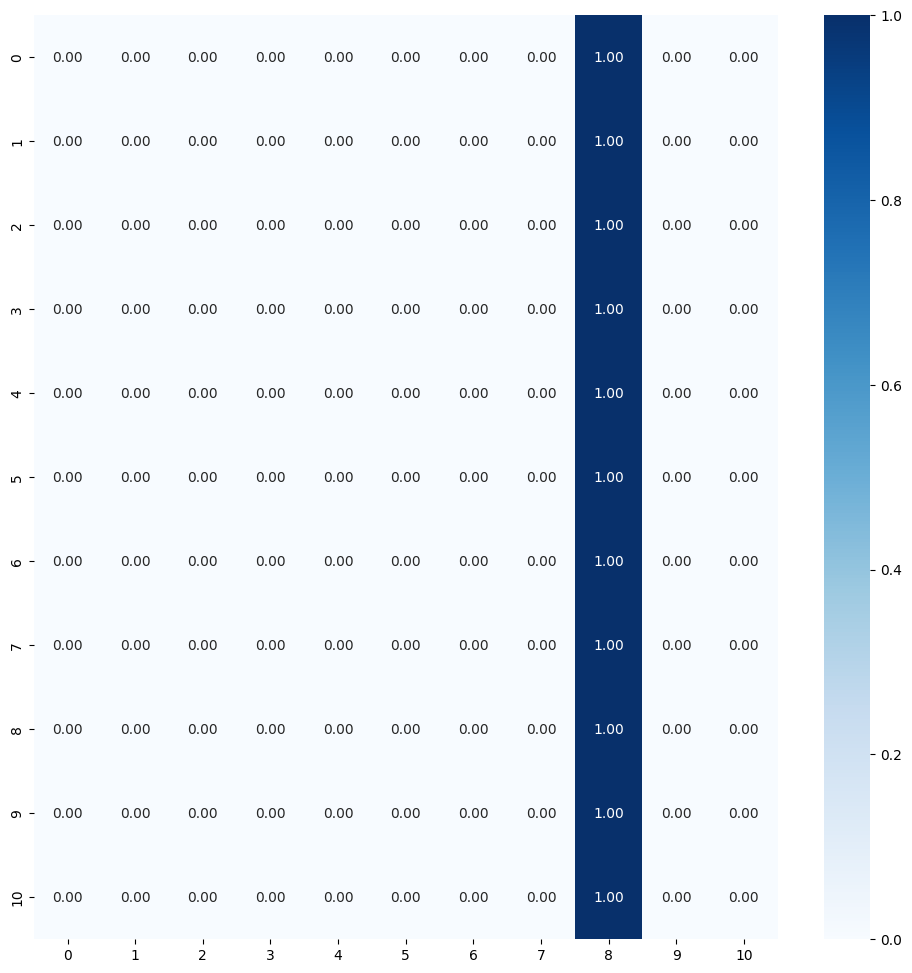

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.09319326281547546
Average validation precision in 5-fold: 0.09131493419408798
/nTest Metrics
test_acc_list: [0.09090909361839294, 0.09090909361839294, 0.09090909361839294, 0.09090909361839294, 0.09090909361839294]
Average Test Accuracy with 5-fold: 0.09090909361839294
test_loss_list: [2.3979063034057617, 2.397899627685547, 2.3979053497314453, 2.3979032039642334, 2.3979098796844482]
Average Test Log Loss with 5-fold: 2.397904872894287

Precision List: [0.008264462809917356, 0.008264462809917356, 0.008264462809917356, 0.008264462809917356, 0.008264462809917356]
Average Precision List with 5-fold: 0.008264462809917356
Recall List: [0.09090909090909091, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091]
Average Recall List with 5-fold: 0.09090909090909091
F1 Score List: [0.01515151515151515, 0.01515151515151515, 0.01515151515151515, 0.01515151515151515, 0.01515151515151515]
Average F1 Score List with 5-fold: 0.01515151

In [19]:
%%time

num_classes = 11
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/12
name_save_model: fusion_VGG16_basic_12
Found 12600 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Found 2700 images belonging to 12 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3761868
Trainable params: 2120204
Non-trainable params: 1641664
Epoch 1/50
393/393 [==============================] - 85s 189ms/step - loss: 5.4421 - accuracy: 0.0764 - val_loss: 3.3232 - val_accuracy: 0.0830
Epoch 2/50
393/393 [==============================] - 61s 155ms/step - loss: 2.7944 - accuracy: 0.0837 - val_loss: 2.5432 - val_accuracy: 0.0830
Epoch 3/50
393/393 [==============================] - 69s 175ms/step - loss: 2.5026 - accuracy: 0.0782 - val_loss: 2.4868 - val_accuracy: 0.0833
Epoch 4/50
393/393 [=======================

Model and History saved...
394/394 [==============================] - 57s 144ms/step - loss: 2.4849 - accuracy: 0.0833
Train Accuracy: 0.0833333358168602
Train Log Loss: 2.4849135875701904
85/85 [==============================] - 14s 157ms/step - loss: 2.4849 - accuracy: 0.0833
Validation Accuracy: 0.0833333358168602
Validation Log Loss: 2.4849131107330322
85/85 [==============================] - 10s 114ms/step - loss: 2.4849 - accuracy: 0.0833
Test Accuracy: 0.0833333358168602
Test Log Loss: 2.4849131107330322
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


85/85 [==============================] - 14s 143ms/step


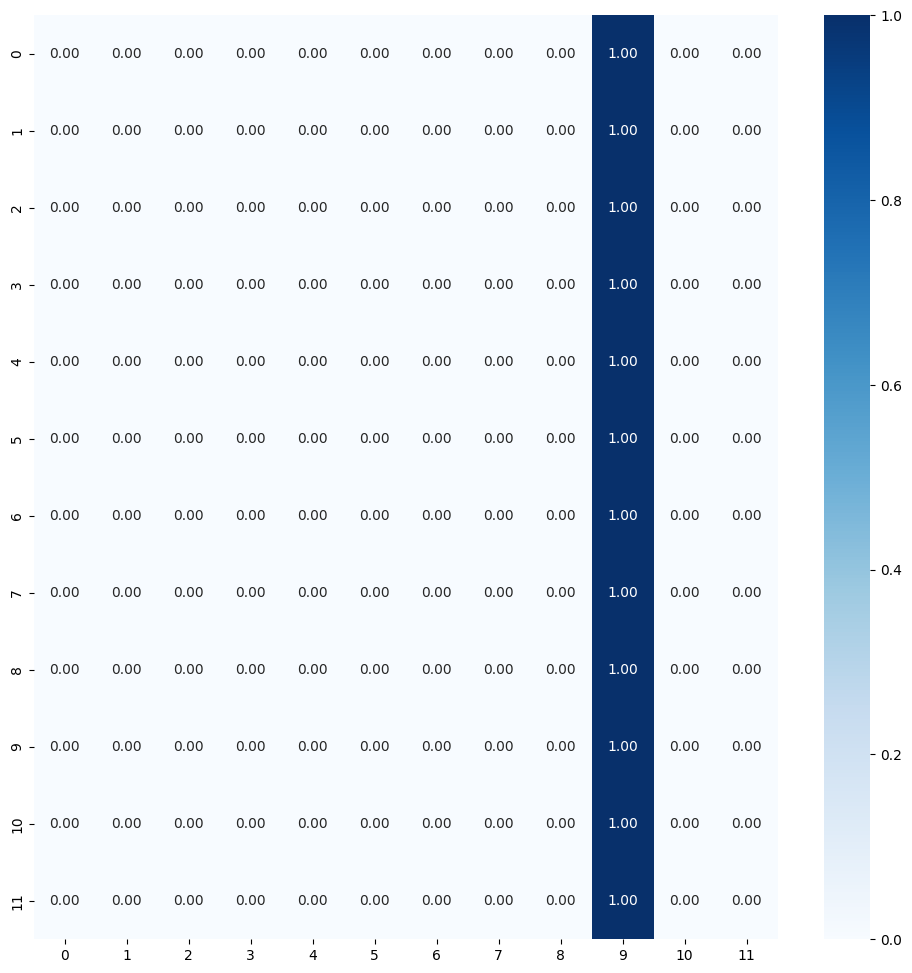

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3761868
Trainable params: 2120204
Non-trainable params: 1641664
Epoch 1/50
393/393 [==============================] - 80s 179ms/step - loss: 5.4288 - accuracy: 0.0794 - val_loss: 3.3189 - val_accuracy: 0.0837
Epoch 2/50
393/393 [==============================] - 60s 152ms/step - loss: 2.7925 - accuracy: 0.0789 - val_loss: 2.5428 - val_accuracy: 0.0833
Epoch 3/50
393/393 [==============================] - 67s 171ms/step - loss: 2.5023 - accuracy: 0.0821 - val_loss: 2.4867 - val_accuracy: 0.0830
Epoch 4/50
393/393 [==============================] - 64s 161ms/step - loss: 2.4856 - accuracy: 0.0812 - val_loss: 2.4849 - val_accuracy: 0.0830
Epoch 5/50
393/393 [==============================] - 73s 186ms/step - loss: 2.4852 - accuracy: 0.0764 - val_loss: 2.4849 - val_accuracy: 0.0833
Epoch 6/50
393/393 [==============================] - 70s 176ms/step - loss: 2.4851 - accuracy: 0.0807 - val_loss: 2.4849 - val_accuracy: 0.0837
Epoch 7/50
393

Model and History saved...
394/394 [==============================] - 47s 120ms/step - loss: 2.4849 - accuracy: 0.0833
Train Accuracy: 0.0833333358168602
Train Log Loss: 2.484916925430298
85/85 [==============================] - 7s 82ms/step - loss: 2.4849 - accuracy: 0.0833
Validation Accuracy: 0.0833333358168602
Validation Log Loss: 2.484917163848877
85/85 [==============================] - 12s 136ms/step - loss: 2.4849 - accuracy: 0.0833
Test Accuracy: 0.0833333358168602
Test Log Loss: 2.484917402267456
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0]
 [  0   0   0   0   0   0 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


85/85 [==============================] - 12s 129ms/step


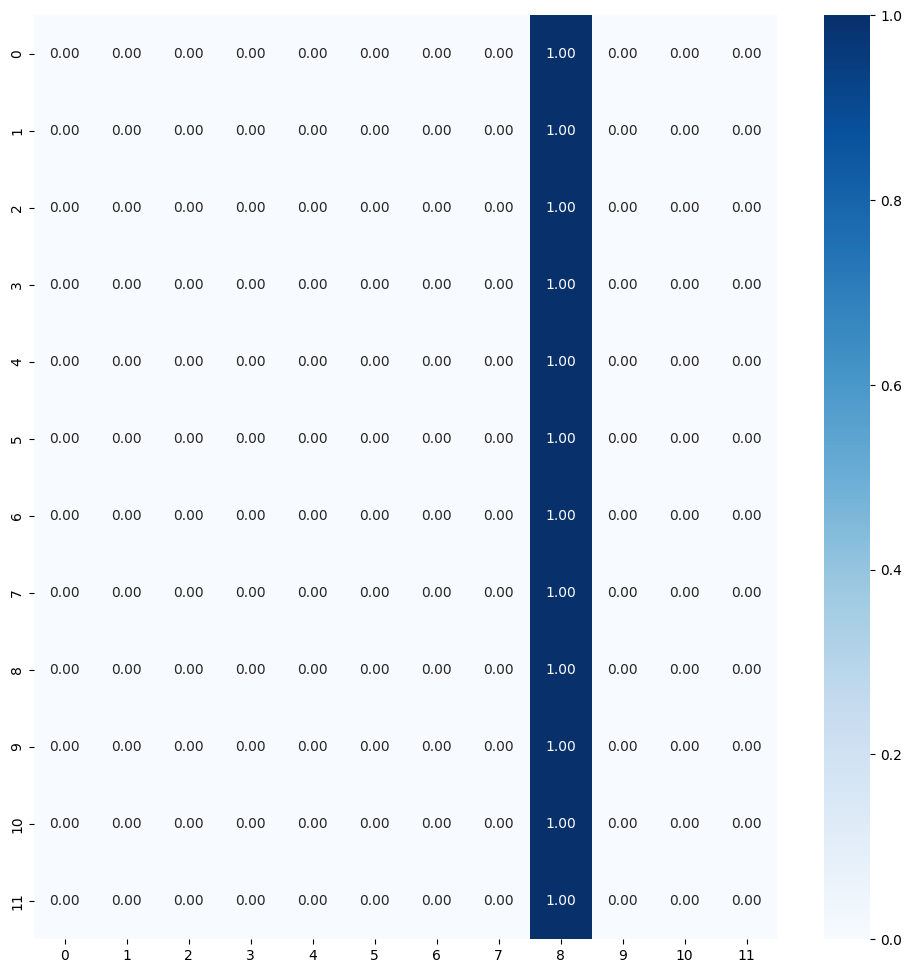

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3761868
Trainable params: 2120204
Non-trainable params: 1641664
Epoch 1/50
393/393 [==============================] - 86s 190ms/step - loss: 5.4439 - accuracy: 0.0769 - val_loss: 3.3231 - val_accuracy: 0.0830
Epoch 2/50
393/393 [==============================] - 59s 151ms/step - loss: 2.7942 - accuracy: 0.0827 - val_loss: 2.5431 - val_accuracy: 0.0833
Epoch 3/50
393/393 [==============================] - 64s 162ms/step - loss: 2.5025 - accuracy: 0.0802 - val_loss: 2.4868 - val_accuracy: 0.0833
Epoch 4/50
393/393 [==============================] - 64s 162ms/step - loss: 2.4856 - accuracy: 0.0769 - val_loss: 2.4849 - val_accuracy: 0.0830
Epoch 5/50
393/393 [==============================] - 63s 161ms/step - loss: 2.4852 - accuracy: 0.0776 - val_loss: 2.4849 - val_accuracy: 0.0837
Epoch 6/50
393/393 [==============================] - 54s 137ms/step - loss: 2.4851 - accuracy: 0.0825 - val_loss: 2.4849 - val_accuracy: 0.0833
Epoch 7/50
393

Model and History saved...
394/394 [==============================] - 48s 121ms/step - loss: 2.4849 - accuracy: 0.0833
Train Accuracy: 0.0833333358168602
Train Log Loss: 2.484912395477295
85/85 [==============================] - 11s 130ms/step - loss: 2.4849 - accuracy: 0.0833
Validation Accuracy: 0.0833333358168602
Validation Log Loss: 2.484912395477295
85/85 [==============================] - 11s 131ms/step - loss: 2.4849 - accuracy: 0.0833
Test Accuracy: 0.0833333358168602
Test Log Loss: 2.484912157058716
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


85/85 [==============================] - 13s 132ms/step


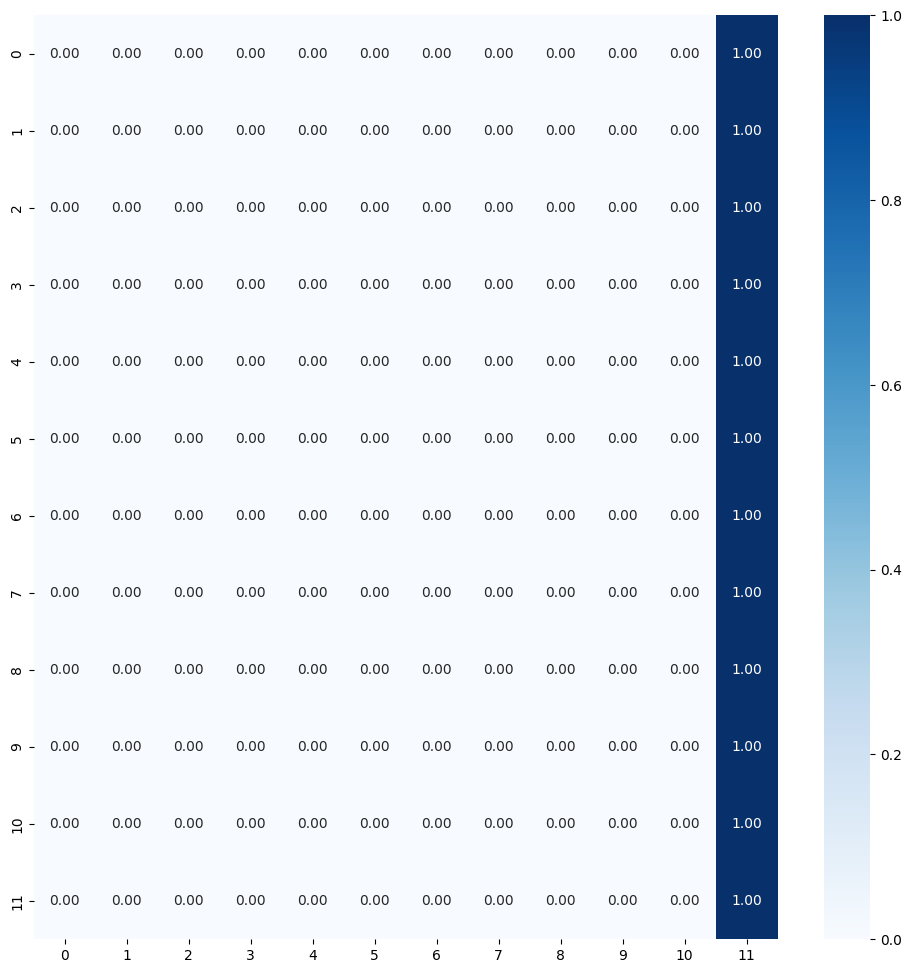

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3761868
Trainable params: 2120204
Non-trainable params: 1641664
Epoch 1/50
393/393 [==============================] - 66s 144ms/step - loss: 5.4411 - accuracy: 0.0769 - val_loss: 3.3223 - val_accuracy: 0.0837
Epoch 2/50
393/393 [==============================] - 63s 160ms/step - loss: 2.7938 - accuracy: 0.0812 - val_loss: 2.5430 - val_accuracy: 0.0837
Epoch 3/50
393/393 [==============================] - 64s 164ms/step - loss: 2.5026 - accuracy: 0.0777 - val_loss: 2.4867 - val_accuracy: 0.0833
Epoch 4/50
393/393 [==============================] - 63s 161ms/step - loss: 2.4855 - accuracy: 0.0790 - val_loss: 2.4849 - val_accuracy: 0.0833
Epoch 5/50
393/393 [==============================] - 56s 143ms/step - loss: 2.4851 - accuracy: 0.0789 - val_loss: 2.4849 - val_accuracy: 0.0837
Epoch 6/50
393/393 [==============================] - 64s 162ms/step - loss: 2.4851 - accuracy: 0.0785 - val_loss: 2.4849 - val_accuracy: 0.0837
Epoch 7/50
393

Model and History saved...
394/394 [==============================] - 63s 160ms/step - loss: 2.4849 - accuracy: 0.0833
Train Accuracy: 0.0833333358168602
Train Log Loss: 2.484914541244507
85/85 [==============================] - 14s 157ms/step - loss: 2.4849 - accuracy: 0.0833
Validation Accuracy: 0.0833333358168602
Validation Log Loss: 2.4849154949188232
85/85 [==============================] - 14s 159ms/step - loss: 2.4849 - accuracy: 0.0833
Test Accuracy: 0.0833333358168602
Test Log Loss: 2.484915256500244
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0   0   0   0   0   0   0   0]
 [  0 225   0   0   0  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


85/85 [==============================] - 12s 125ms/step


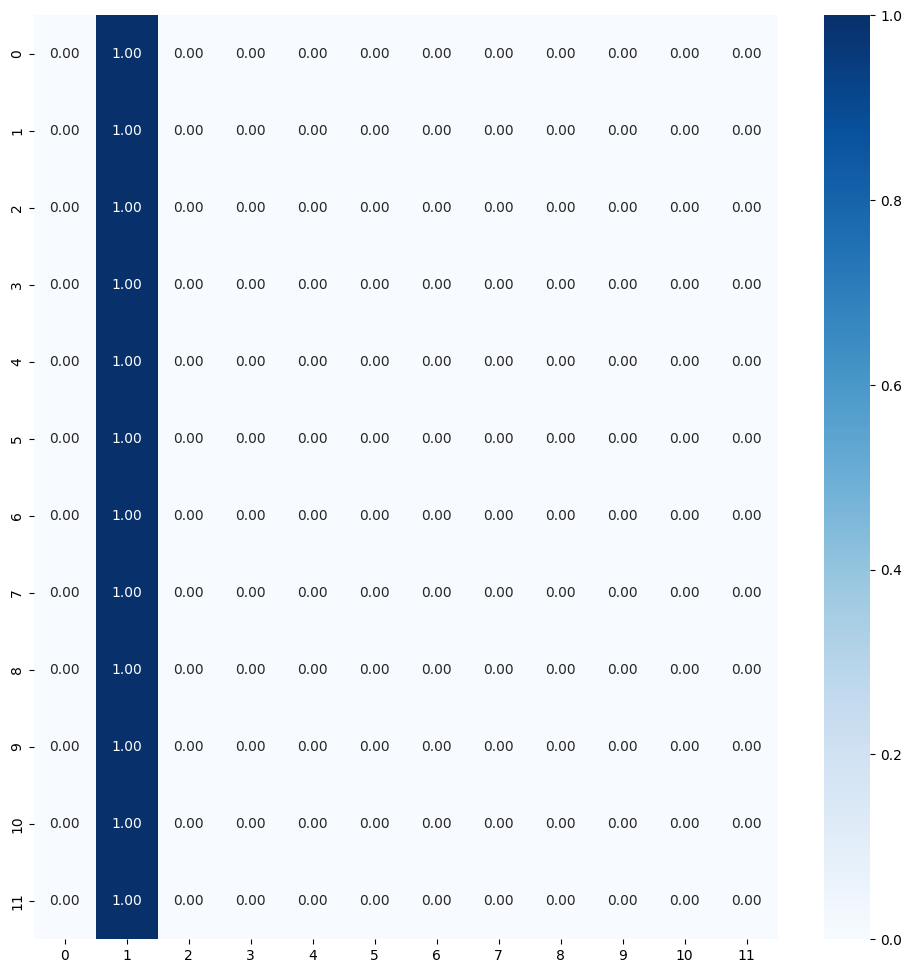

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3761868
Trainable params: 2120204
Non-trainable params: 1641664
Epoch 1/50
393/393 [==============================] - 73s 169ms/step - loss: 5.4398 - accuracy: 0.0771 - val_loss: 3.3226 - val_accuracy: 0.0837
Epoch 2/50
393/393 [==============================] - 63s 160ms/step - loss: 2.7937 - accuracy: 0.0813 - val_loss: 2.5430 - val_accuracy: 0.0830
Epoch 3/50
393/393 [==============================] - 64s 163ms/step - loss: 2.5025 - accuracy: 0.0777 - val_loss: 2.4867 - val_accuracy: 0.0837
Epoch 4/50
393/393 [==============================] - 63s 161ms/step - loss: 2.4856 - accuracy: 0.0792 - val_loss: 2.4849 - val_accuracy: 0.0833
Epoch 5/50
393/393 [==============================] - 55s 141ms/step - loss: 2.4851 - accuracy: 0.0805 - val_loss: 2.4849 - val_accuracy: 0.0830
Epoch 6/50
393/393 [==============================] - 63s 160ms/step - loss: 2.4851 - accuracy: 0.0799 - val_loss: 2.4849 - val_accuracy: 0.0837
Epoch 7/50
393

Model and History saved...
394/394 [==============================] - 35s 88ms/step - loss: 2.4849 - accuracy: 0.0833
Train Accuracy: 0.0833333358168602
Train Log Loss: 2.484915018081665
85/85 [==============================] - 8s 89ms/step - loss: 2.4849 - accuracy: 0.0833
Validation Accuracy: 0.0833333358168602
Validation Log Loss: 2.484915256500244
85/85 [==============================] - 7s 86ms/step - loss: 2.4849 - accuracy: 0.0833
Test Accuracy: 0.0833333358168602
Test Log Loss: 2.484914541244507
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'dinwod': 5, 'ganelp': 6, 'mira': 7, 'sfone': 8, 'sillyp2p': 9, 'wabot': 10, 'wacatac': 11}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


85/85 [==============================] - 8s 83ms/step


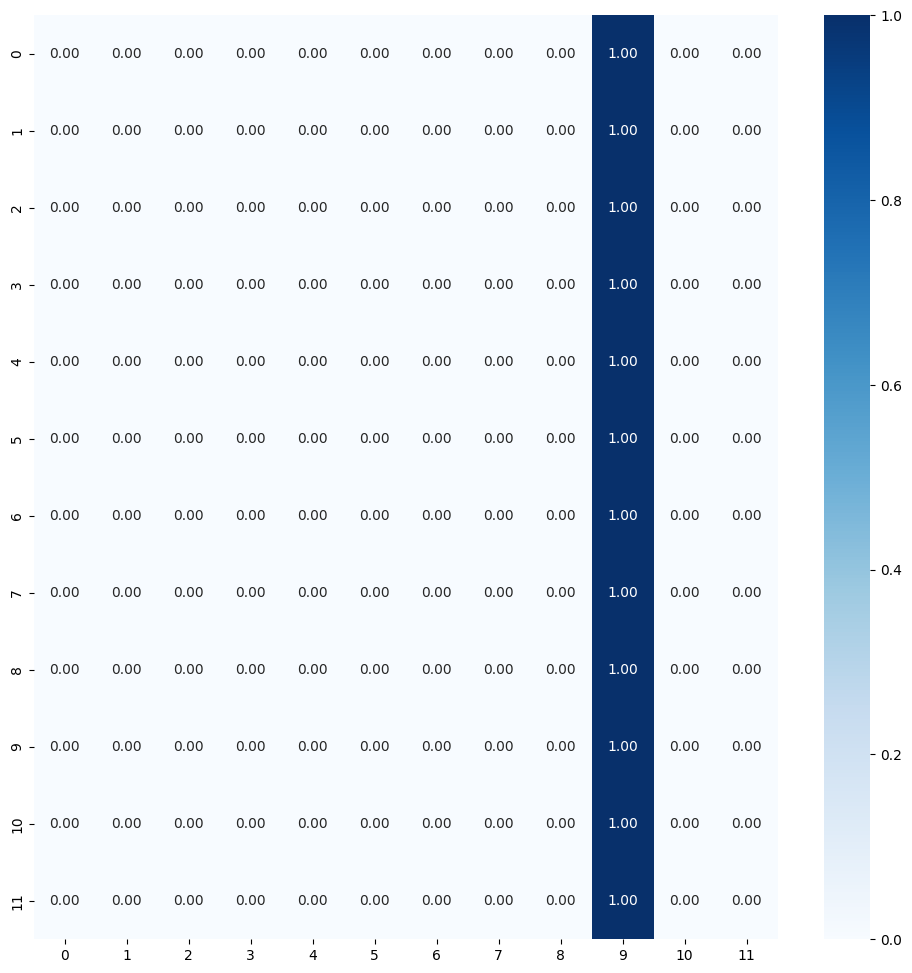

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.08465945124626159
Average validation precision in 5-fold: 0.0837053582072258
/nTest Metrics
test_acc_list: [0.0833333358168602, 0.0833333358168602, 0.0833333358168602, 0.0833333358168602, 0.0833333358168602]
Average Test Accuracy with 5-fold: 0.0833333358168602
test_loss_list: [2.4849131107330322, 2.484917402267456, 2.484912157058716, 2.484915256500244, 2.484914541244507]
Average Test Log Loss with 5-fold: 2.484914493560791

Precision List: [0.006944444444444444, 0.006944444444444444, 0.006944444444444444, 0.006944444444444444, 0.006944444444444444]
Average Precision List with 5-fold: 0.006944444444444445
Recall List: [0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333]
Average Recall List with 5-fold: 0.08333333333333333
F1 Score List: [0.012820512820512822, 0.012820512820512822, 0.012820512820512822, 0.012820512820512822, 0.012820512820512822]
Average F1 Score List with 5-fold: 0.0128205128205

In [20]:
%%time

num_classes = 12
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/13
name_save_model: fusion_VGG16_basic_13
Found 13650 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Found 2925 images belonging to 13 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3762381
Trainable params: 2120717
Non-trainable params: 1641664
Epoch 1/50
426/426 [==============================] - 88s 182ms/step - loss: 5.3501 - accuracy: 0.0724 - val_loss: 3.2504 - val_accuracy: 0.0773
Epoch 2/50
426/426 [==============================] - 63s 149ms/step - loss: 2.7974 - accuracy: 0.0727 - val_loss: 2.5994 - val_accuracy: 0.0769
Epoch 3/50
426/426 [==============================] - 74s 173ms/step - loss: 2.5744 - accuracy: 0.0683 - val_loss: 2.5656 - val_accuracy: 0.0766
Epoch 4/50
426/426 [==============

Model and History saved...
427/427 [==============================] - 56s 132ms/step - loss: 2.5650 - accuracy: 0.0769
Train Accuracy: 0.07692307978868484
Train Log Loss: 2.5649573802948
92/92 [==============================] - 14s 147ms/step - loss: 2.5650 - accuracy: 0.0769
Validation Accuracy: 0.07692307978868484
Validation Log Loss: 2.5649569034576416
92/92 [==============================] - 13s 135ms/step - loss: 2.5650 - accuracy: 0.0769
Test Accuracy: 0.07692307978868484
Test Log Loss: 2.5649573802948
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[225   0   0   0   0   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0   0   0   0   0]
 [225   0   0   0   0   0   0   0   0   0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


92/92 [==============================] - 10s 93ms/step


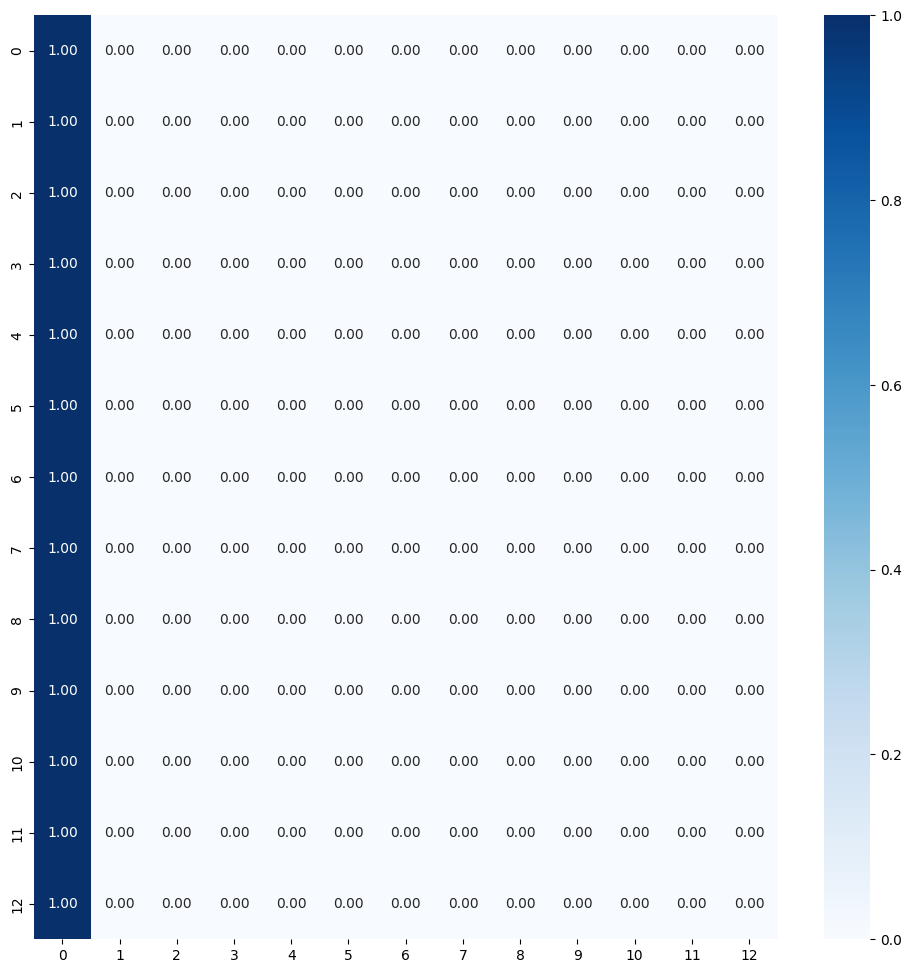

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3762381
Trainable params: 2120717
Non-trainable params: 1641664
Epoch 1/50
426/426 [==============================] - 83s 166ms/step - loss: 5.3526 - accuracy: 0.0750 - val_loss: 3.2522 - val_accuracy: 0.0769
Epoch 2/50
426/426 [==============================] - 65s 151ms/step - loss: 2.7982 - accuracy: 0.0736 - val_loss: 2.5996 - val_accuracy: 0.0769
Epoch 3/50
426/426 [==============================] - 45s 107ms/step - loss: 2.5745 - accuracy: 0.0726 - val_loss: 2.5656 - val_accuracy: 0.0766
Epoch 4/50
426/426 [==============================] - 46s 108ms/step - loss: 2.5653 - accuracy: 0.0731 - val_loss: 2.5650 - val_accuracy: 0.0762
Epoch 5/50
426/426 [==============================] - 68s 159ms/step - loss: 2.5651 - accuracy: 0.0716 - val_loss: 2.5650 - val_accuracy: 0.0769
Epoch 6/50
426/426 [==============================] - 68s 159ms/step - loss: 2.5651 - accuracy: 0.0724 - val_loss: 2.5650 - val_accuracy: 0.0766
Epoch 7/50
426

Model and History saved...
427/427 [==============================] - 55s 129ms/step - loss: 2.5650 - accuracy: 0.0769
Train Accuracy: 0.07692307978868484
Train Log Loss: 2.564959764480591
92/92 [==============================] - 12s 129ms/step - loss: 2.5650 - accuracy: 0.0769
Validation Accuracy: 0.07692307978868484
Validation Log Loss: 2.5649616718292236
92/92 [==============================] - 12s 125ms/step - loss: 2.5650 - accuracy: 0.0769
Test Accuracy: 0.07692307978868484
Test Log Loss: 2.5649611949920654
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[  0   0   0   0   0 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


92/92 [==============================] - 13s 123ms/step


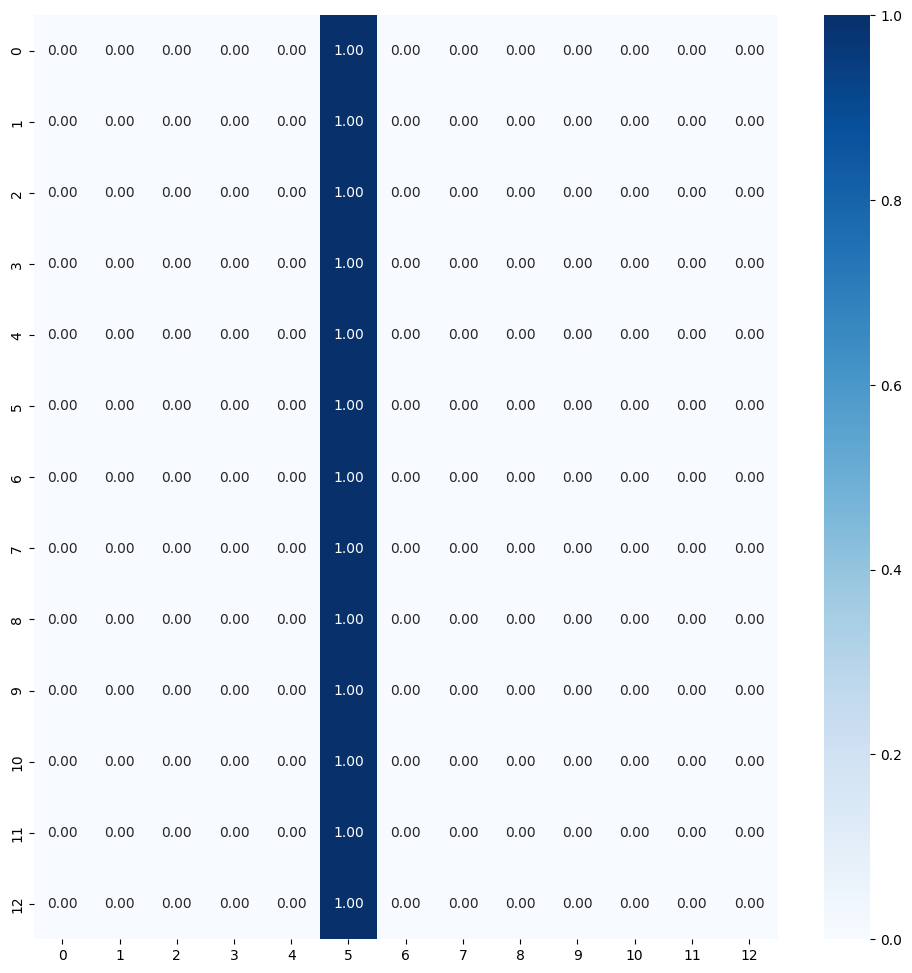

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3762381
Trainable params: 2120717
Non-trainable params: 1641664
Epoch 1/50
426/426 [==============================] - 81s 175ms/step - loss: 5.3452 - accuracy: 0.0726 - val_loss: 3.2495 - val_accuracy: 0.0769
Epoch 2/50
426/426 [==============================] - 71s 166ms/step - loss: 2.7974 - accuracy: 0.0711 - val_loss: 2.5994 - val_accuracy: 0.0773
Epoch 3/50
426/426 [==============================] - 70s 165ms/step - loss: 2.5744 - accuracy: 0.0726 - val_loss: 2.5656 - val_accuracy: 0.0773
Epoch 4/50
426/426 [==============================] - 72s 168ms/step - loss: 2.5652 - accuracy: 0.0739 - val_loss: 2.5650 - val_accuracy: 0.0769
Epoch 5/50
426/426 [==============================] - 67s 158ms/step - loss: 2.5652 - accuracy: 0.0735 - val_loss: 2.5650 - val_accuracy: 0.0773
Epoch 6/50
426/426 [==============================] - 68s 159ms/step - loss: 2.5652 - accuracy: 0.0749 - val_loss: 2.5650 - val_accuracy: 0.0766
Epoch 7/50
426

Model and History saved...
427/427 [==============================] - 52s 121ms/step - loss: 2.5650 - accuracy: 0.0769
Train Accuracy: 0.07692307978868484
Train Log Loss: 2.564957857131958
92/92 [==============================] - 12s 134ms/step - loss: 2.5650 - accuracy: 0.0769
Validation Accuracy: 0.07692307978868484
Validation Log Loss: 2.5649585723876953
92/92 [==============================] - 12s 131ms/step - loss: 2.5650 - accuracy: 0.0769
Test Accuracy: 0.07692307978868484
Test Log Loss: 2.5649588108062744
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[  0   0   0   0   0 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0   0   0   0   0]
 [  0   0   0   0   0 225   0   0   0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


92/92 [==============================] - 13s 130ms/step


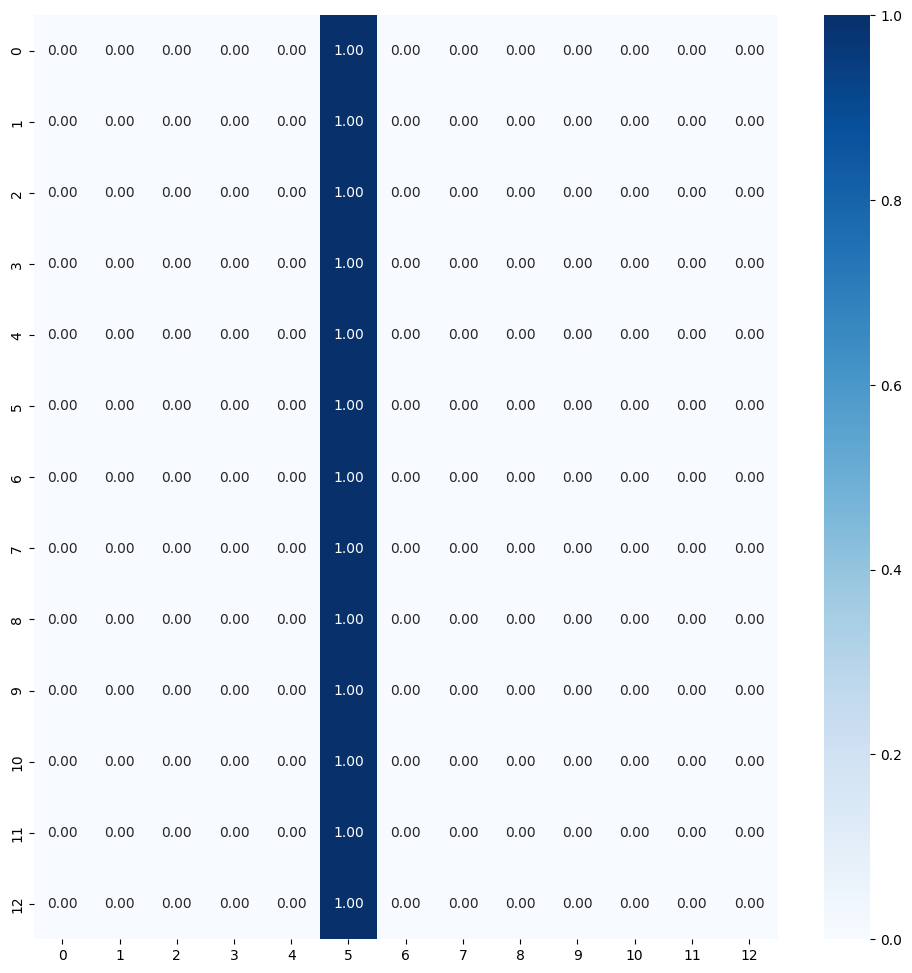

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3762381
Trainable params: 2120717
Non-trainable params: 1641664
Epoch 1/50
426/426 [==============================] - 73s 150ms/step - loss: 5.3468 - accuracy: 0.0718 - val_loss: 3.2503 - val_accuracy: 0.0773
Epoch 2/50
426/426 [==============================] - 69s 162ms/step - loss: 2.7977 - accuracy: 0.0745 - val_loss: 2.5994 - val_accuracy: 0.0773
Epoch 3/50
426/426 [==============================] - 59s 139ms/step - loss: 2.5744 - accuracy: 0.0739 - val_loss: 2.5656 - val_accuracy: 0.0773
Epoch 4/50
426/426 [==============================] - 72s 168ms/step - loss: 2.5653 - accuracy: 0.0704 - val_loss: 2.5650 - val_accuracy: 0.0769
Epoch 5/50
426/426 [==============================] - 71s 168ms/step - loss: 2.5651 - accuracy: 0.0753 - val_loss: 2.5650 - val_accuracy: 0.0769
Epoch 6/50
426/426 [==============================] - 65s 151ms/step - loss: 2.5653 - accuracy: 0.0692 - val_loss: 2.5650 - val_accuracy: 0.0773
Epoch 7/50
426

Model and History saved...
427/427 [==============================] - 59s 138ms/step - loss: 2.5650 - accuracy: 0.0769
Train Accuracy: 0.07692307978868484
Train Log Loss: 2.564964771270752
92/92 [==============================] - 12s 132ms/step - loss: 2.5650 - accuracy: 0.0769
Validation Accuracy: 0.07692307978868484
Validation Log Loss: 2.5649657249450684
92/92 [==============================] - 13s 134ms/step - loss: 2.5650 - accuracy: 0.0769
Test Accuracy: 0.07692307978868484
Test Log Loss: 2.5649659633636475
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0 225   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


92/92 [==============================] - 10s 94ms/step


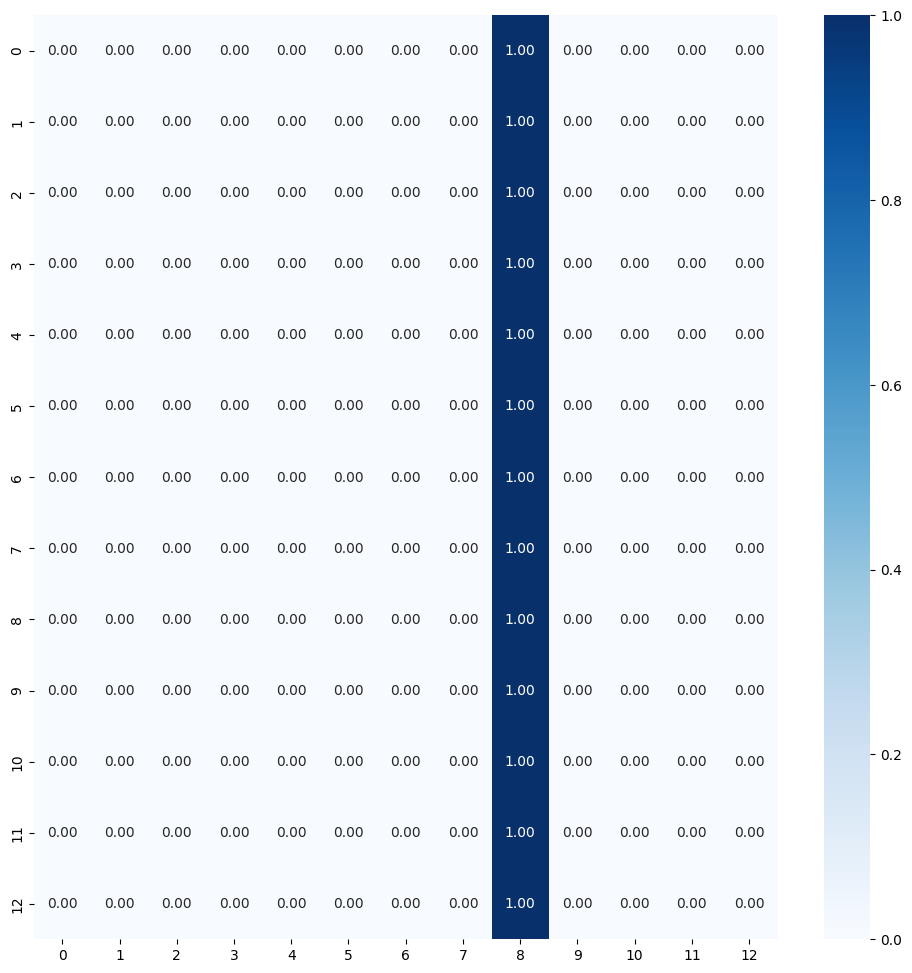

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3762381
Trainable params: 2120717
Non-trainable params: 1641664
Epoch 1/50
426/426 [==============================] - 76s 161ms/step - loss: 5.3555 - accuracy: 0.0742 - val_loss: 3.2522 - val_accuracy: 0.0773
Epoch 2/50
426/426 [==============================] - 67s 157ms/step - loss: 2.7980 - accuracy: 0.0725 - val_loss: 2.5995 - val_accuracy: 0.0773
Epoch 3/50
426/426 [==============================] - 71s 167ms/step - loss: 2.5744 - accuracy: 0.0744 - val_loss: 2.5656 - val_accuracy: 0.0773
Epoch 4/50
426/426 [==============================] - 66s 153ms/step - loss: 2.5653 - accuracy: 0.0749 - val_loss: 2.5650 - val_accuracy: 0.0769
Epoch 5/50
426/426 [==============================] - 70s 164ms/step - loss: 2.5652 - accuracy: 0.0707 - val_loss: 2.5650 - val_accuracy: 0.0769
Epoch 6/50
426/426 [==============================] - 69s 161ms/step - loss: 2.5652 - accuracy: 0.0730 - val_loss: 2.5650 - val_accuracy: 0.0773
Epoch 7/50
426

Model and History saved...
427/427 [==============================] - 56s 131ms/step - loss: 2.5650 - accuracy: 0.0769
Train Accuracy: 0.07692307978868484
Train Log Loss: 2.564962148666382
92/92 [==============================] - 12s 128ms/step - loss: 2.5650 - accuracy: 0.0769
Validation Accuracy: 0.07692307978868484
Validation Log Loss: 2.5649616718292236
92/92 [==============================] - 11s 116ms/step - loss: 2.5650 - accuracy: 0.0769
Test Accuracy: 0.07692307978868484
Test Log Loss: 2.564962148666382
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'wabot': 11, 'wacatac': 12}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


92/92 [==============================] - 13s 131ms/step


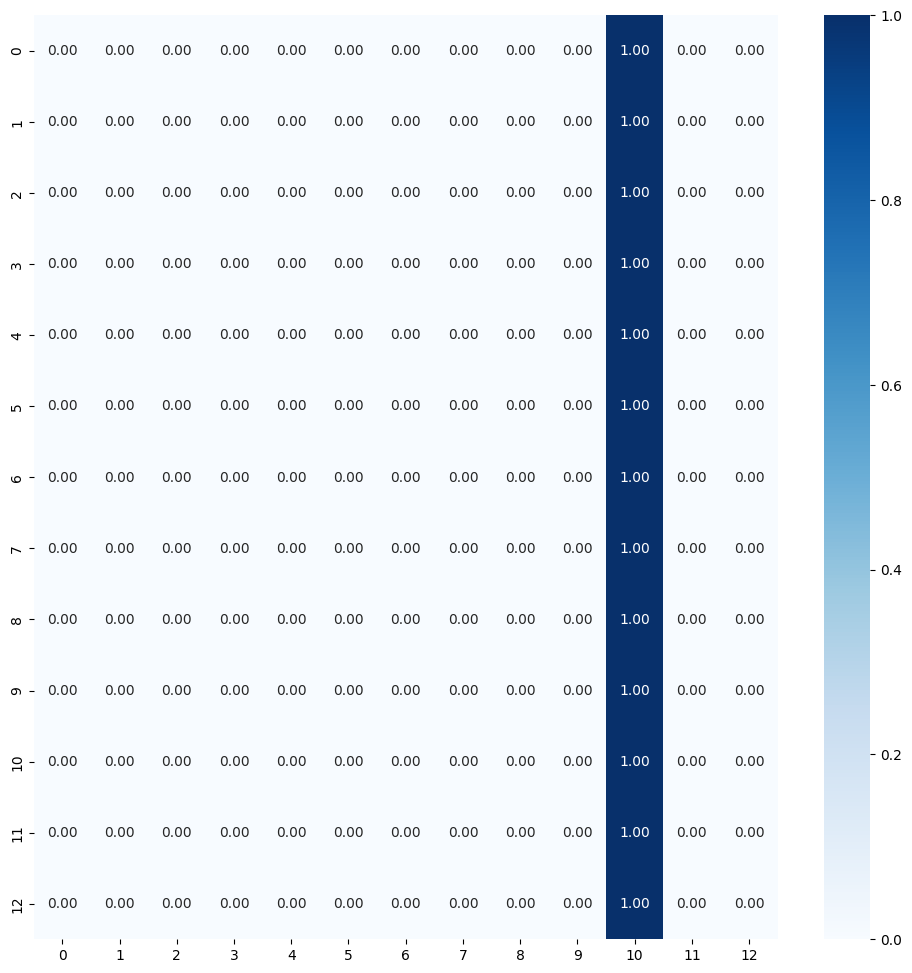

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.07910118848085404
Average validation precision in 5-fold: 0.07726648449897766
/nTest Metrics
test_acc_list: [0.07692307978868484, 0.07692307978868484, 0.07692307978868484, 0.07692307978868484, 0.07692307978868484]
Average Test Accuracy with 5-fold: 0.07692307978868484
test_loss_list: [2.5649573802948, 2.5649611949920654, 2.5649588108062744, 2.5649659633636475, 2.564962148666382]
Average Test Log Loss with 5-fold: 2.5649610996246337

Precision List: [0.00591715976331361, 0.00591715976331361, 0.00591715976331361, 0.00591715976331361, 0.00591715976331361]
Average Precision List with 5-fold: 0.00591715976331361
Recall List: [0.07692307692307693, 0.07692307692307693, 0.07692307692307693, 0.07692307692307693, 0.07692307692307693]
Average Recall List with 5-fold: 0.07692307692307693
F1 Score List: [0.010989010989010988, 0.010989010989010988, 0.010989010989010988, 0.010989010989010988, 0.010989010989010988]
Average F1 Score List with 5-fold: 0.01098901098

In [21]:
%%time

num_classes = 13
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/14
name_save_model: fusion_VGG16_basic_14
Found 14700 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Found 3150 images belonging to 14 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3762894
Trainable params: 2121230
Non-trainable params: 1641664
Epoch 1/50
459/459 [==============================] - 89s 167ms/step - loss: 5.2821 - accuracy: 0.0669 - val_loss: 3.2035 - val_accuracy: 0.0711
Epoch 2/50
459/459 [==============================] - 64s 140ms/step - loss: 2.8157 - accuracy: 0.0690 - val_loss: 2.6593 - val_accuracy: 0.0717
Epoch 3/50
459/459 [==============================] - 74s 160ms/step - loss: 2.6441 - accuracy: 0.0692 - val_loss: 2.6393 - val_accuracy: 0.0717
Epoch 4/50
459/459 [======

Model and History saved...
460/460 [==============================] - 64s 139ms/step - loss: 2.6391 - accuracy: 0.0714
Train Accuracy: 0.0714285746216774
Train Log Loss: 2.6390740871429443
99/99 [==============================] - 14s 142ms/step - loss: 2.6391 - accuracy: 0.0714
Validation Accuracy: 0.0714285746216774
Validation Log Loss: 2.6390743255615234
99/99 [==============================] - 13s 131ms/step - loss: 2.6391 - accuracy: 0.0714
Test Accuracy: 0.0714285746216774
Test Log Loss: 2.6390740871429443
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


99/99 [==============================] - 13s 123ms/step


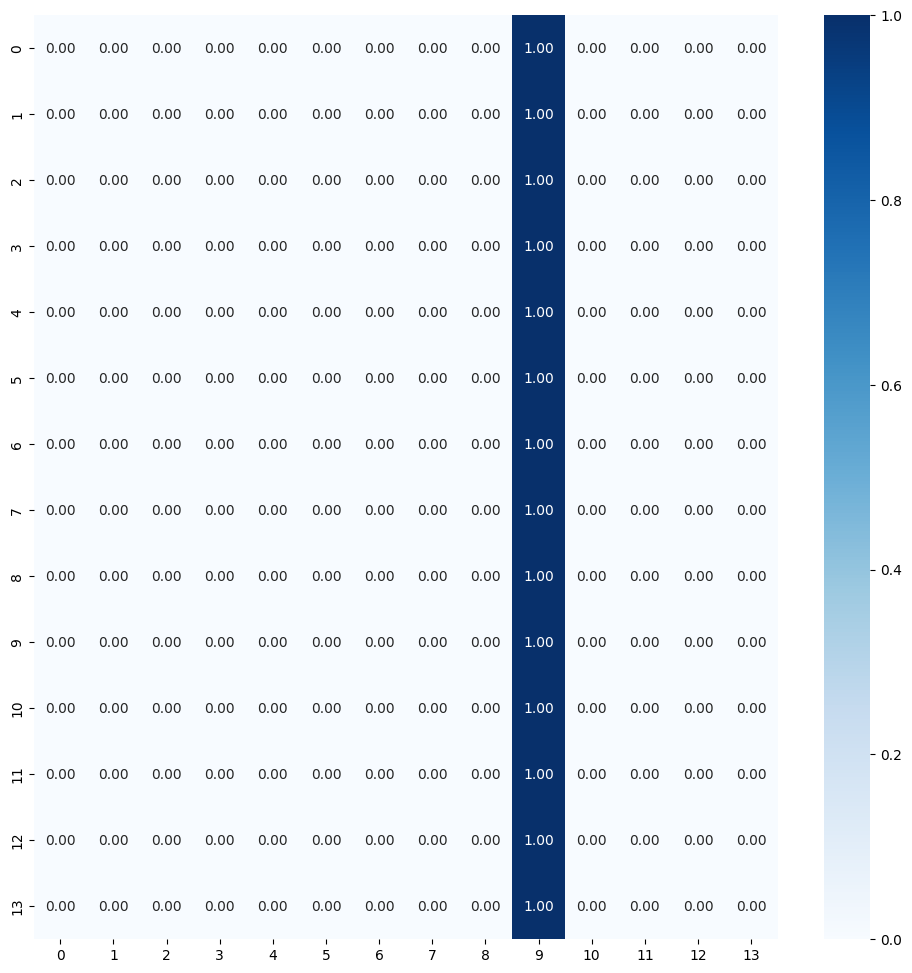

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3762894
Trainable params: 2121230
Non-trainable params: 1641664
Epoch 1/50
459/459 [==============================] - 85s 164ms/step - loss: 5.2747 - accuracy: 0.0654 - val_loss: 3.2008 - val_accuracy: 0.0714
Epoch 2/50
459/459 [==============================] - 68s 148ms/step - loss: 2.8148 - accuracy: 0.0707 - val_loss: 2.6592 - val_accuracy: 0.0717
Epoch 3/50
459/459 [==============================] - 80s 174ms/step - loss: 2.6441 - accuracy: 0.0674 - val_loss: 2.6393 - val_accuracy: 0.0717
Epoch 4/50
459/459 [==============================] - 76s 166ms/step - loss: 2.6393 - accuracy: 0.0662 - val_loss: 2.6391 - val_accuracy: 0.0717
Epoch 5/50
459/459 [==============================] - 67s 146ms/step - loss: 2.6392 - accuracy: 0.0702 - val_loss: 2.6391 - val_accuracy: 0.0708
Epoch 6/50
459/459 [==============================] - 77s 167ms/step - loss: 2.6393 - accuracy: 0.0673 - val_loss: 2.6391 - val_accuracy: 0.0717
Epoch 7/50
459

Model and History saved...
460/460 [==============================] - 61s 133ms/step - loss: 2.6391 - accuracy: 0.0714
Train Accuracy: 0.0714285746216774
Train Log Loss: 2.6390762329101562
99/99 [==============================] - 10s 102ms/step - loss: 2.6391 - accuracy: 0.0714
Validation Accuracy: 0.0714285746216774
Validation Log Loss: 2.6390764713287354
99/99 [==============================] - 9s 93ms/step - loss: 2.6391 - accuracy: 0.0714
Test Accuracy: 0.0714285746216774
Test Log Loss: 2.6390762329101562
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[  0   0   0   0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 225   0   0   0   0   0   0]
 [  0   0   0  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


99/99 [==============================] - 15s 140ms/step


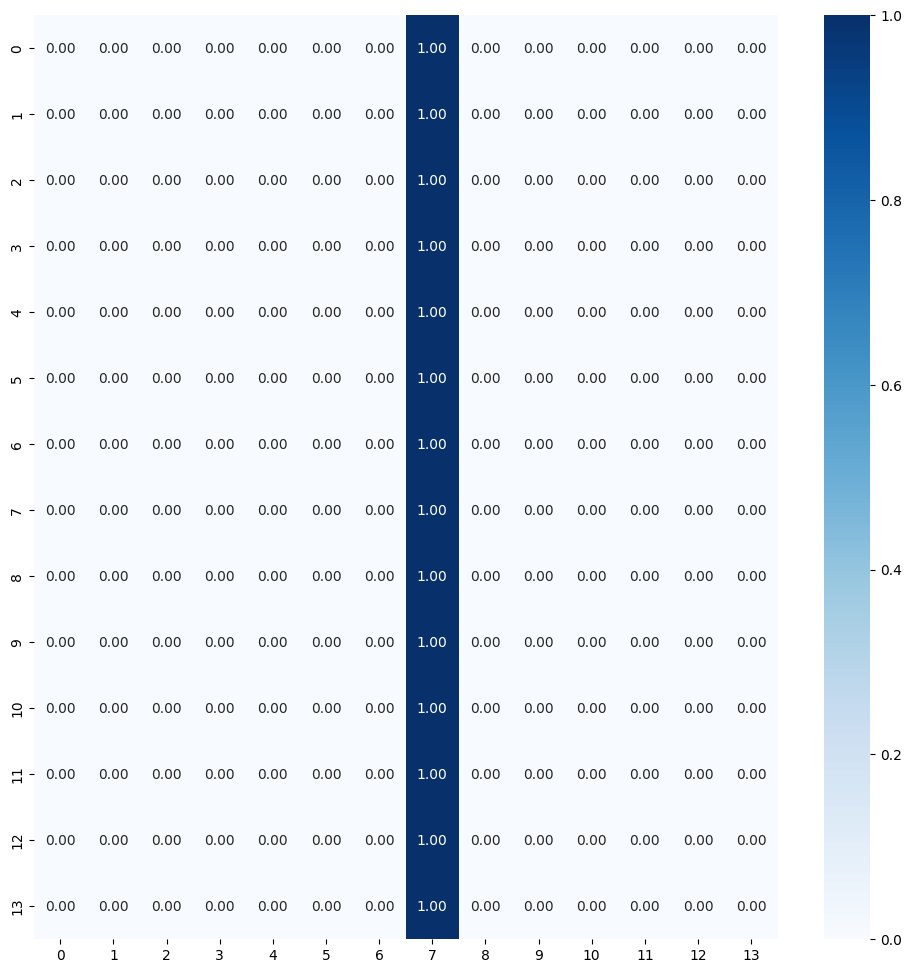

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3762894
Trainable params: 2121230
Non-trainable params: 1641664
Epoch 1/50
459/459 [==============================] - 89s 173ms/step - loss: 5.2685 - accuracy: 0.0682 - val_loss: 3.1999 - val_accuracy: 0.0711
Epoch 2/50
459/459 [==============================] - 74s 162ms/step - loss: 2.8142 - accuracy: 0.0667 - val_loss: 2.6591 - val_accuracy: 0.0714
Epoch 3/50
459/459 [==============================] - 88s 191ms/step - loss: 2.6441 - accuracy: 0.0673 - val_loss: 2.6393 - val_accuracy: 0.0717
Epoch 4/50
459/459 [==============================] - 85s 185ms/step - loss: 2.6393 - accuracy: 0.0704 - val_loss: 2.6391 - val_accuracy: 0.0711
Epoch 5/50
459/459 [==============================] - 75s 164ms/step - loss: 2.6393 - accuracy: 0.0687 - val_loss: 2.6391 - val_accuracy: 0.0717
Epoch 6/50
459/459 [==============================] - 84s 182ms/step - loss: 2.6394 - accuracy: 0.0668 - val_loss: 2.6391 - val_accuracy: 0.0714
Epoch 7/50
459

Model and History saved...
460/460 [==============================] - 61s 132ms/step - loss: 2.6391 - accuracy: 0.0714
Train Accuracy: 0.0714285746216774
Train Log Loss: 2.639069080352783
99/99 [==============================] - 9s 89ms/step - loss: 2.6391 - accuracy: 0.0714
Validation Accuracy: 0.0714285746216774
Validation Log Loss: 2.639069080352783
99/99 [==============================] - 11s 109ms/step - loss: 2.6391 - accuracy: 0.0714
Test Accuracy: 0.0714285746216774
Test Log Loss: 2.6390700340270996
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


99/99 [==============================] - 15s 133ms/step


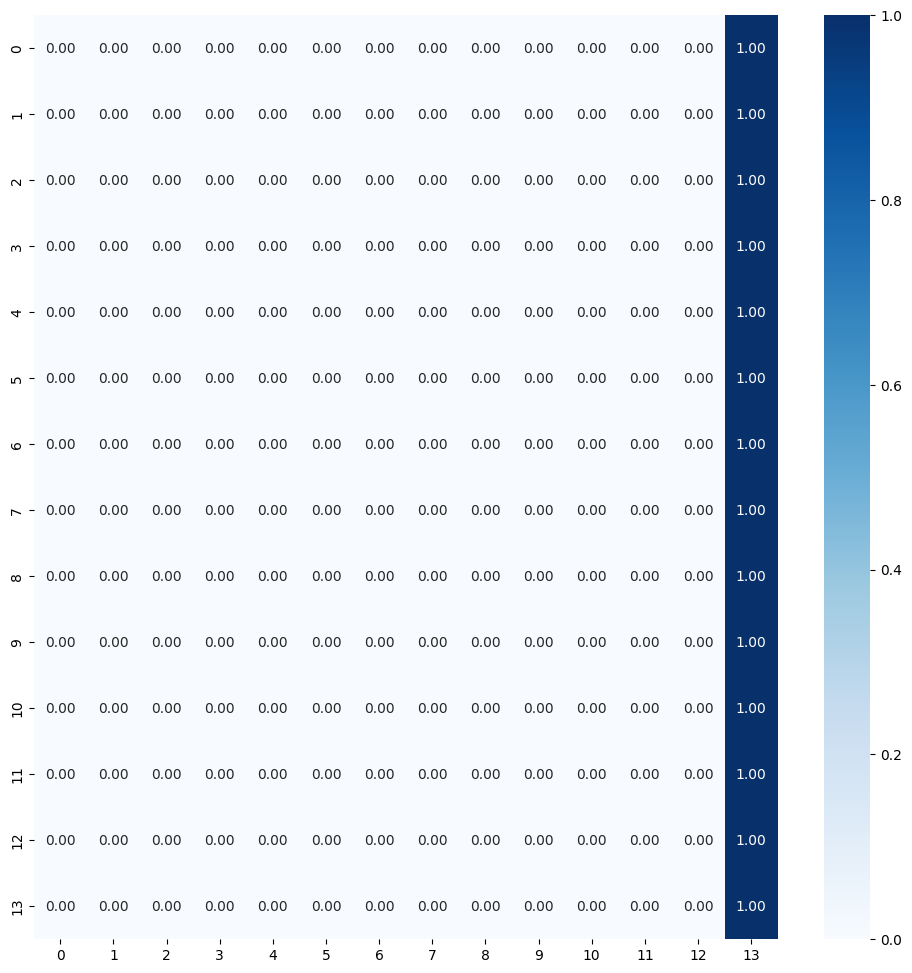

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3762894
Trainable params: 2121230
Non-trainable params: 1641664
Epoch 1/50
459/459 [==============================] - 85s 164ms/step - loss: 5.2621 - accuracy: 0.0639 - val_loss: 3.1991 - val_accuracy: 0.0714
Epoch 2/50
459/459 [==============================] - 65s 141ms/step - loss: 2.8136 - accuracy: 0.0672 - val_loss: 2.6591 - val_accuracy: 0.0714
Epoch 3/50
459/459 [==============================] - 75s 163ms/step - loss: 2.6441 - accuracy: 0.0676 - val_loss: 2.6393 - val_accuracy: 0.0714
Epoch 4/50
459/459 [==============================] - 68s 149ms/step - loss: 2.6393 - accuracy: 0.0693 - val_loss: 2.6391 - val_accuracy: 0.0711
Epoch 5/50
459/459 [==============================] - 73s 160ms/step - loss: 2.6393 - accuracy: 0.0680 - val_loss: 2.6391 - val_accuracy: 0.0711
Epoch 6/50
459/459 [==============================] - 70s 152ms/step - loss: 2.6393 - accuracy: 0.0680 - val_loss: 2.6391 - val_accuracy: 0.0714
Epoch 7/50
459

Model and History saved...
460/460 [==============================] - 56s 121ms/step - loss: 2.6391 - accuracy: 0.0714
Train Accuracy: 0.0714285746216774
Train Log Loss: 2.639061450958252
99/99 [==============================] - 14s 141ms/step - loss: 2.6391 - accuracy: 0.0714
Validation Accuracy: 0.0714285746216774
Validation Log Loss: 2.639061212539673
99/99 [==============================] - 14s 137ms/step - loss: 2.6391 - accuracy: 0.0714
Test Accuracy: 0.0714285746216774
Test Log Loss: 2.639061450958252
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


99/99 [==============================] - 16s 143ms/step


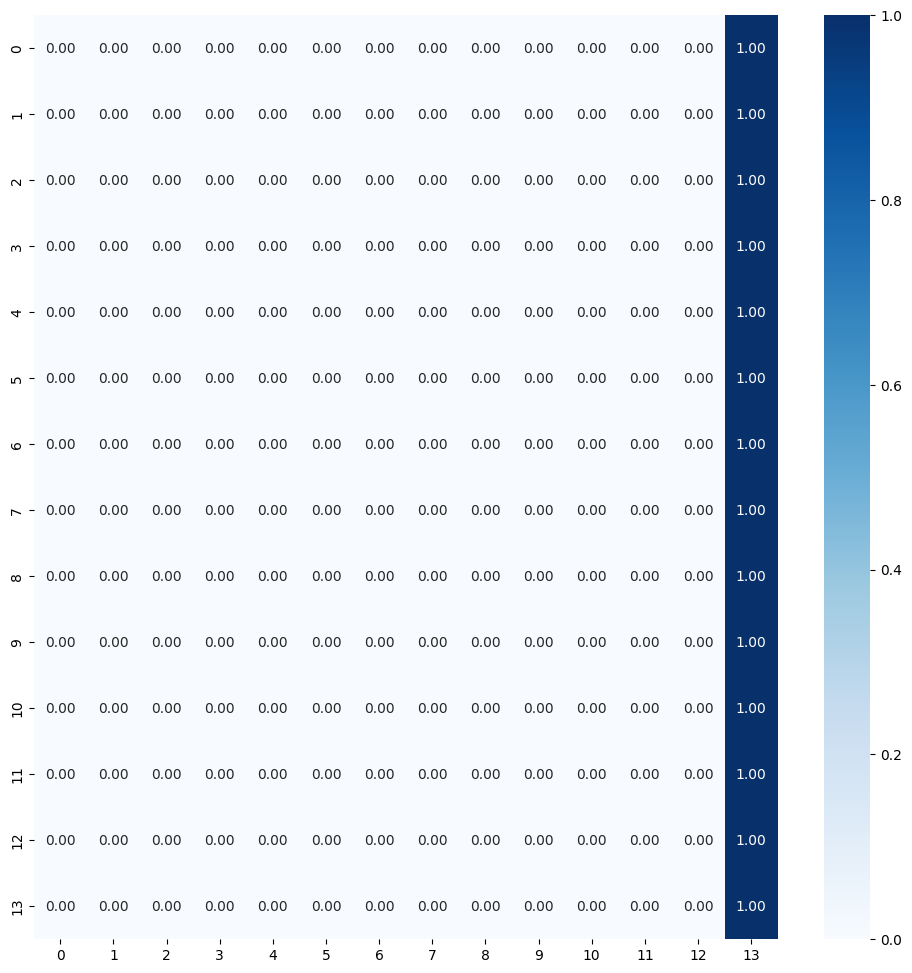

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3762894
Trainable params: 2121230
Non-trainable params: 1641664
Epoch 1/50
459/459 [==============================] - 81s 155ms/step - loss: 5.2711 - accuracy: 0.0672 - val_loss: 3.1999 - val_accuracy: 0.0714
Epoch 2/50
459/459 [==============================] - 84s 182ms/step - loss: 2.8145 - accuracy: 0.0680 - val_loss: 2.6591 - val_accuracy: 0.0717
Epoch 3/50
459/459 [==============================] - 68s 147ms/step - loss: 2.6441 - accuracy: 0.0699 - val_loss: 2.6393 - val_accuracy: 0.0714
Epoch 4/50
459/459 [==============================] - 79s 172ms/step - loss: 2.6393 - accuracy: 0.0659 - val_loss: 2.6391 - val_accuracy: 0.0717
Epoch 5/50
459/459 [==============================] - 68s 147ms/step - loss: 2.6393 - accuracy: 0.0665 - val_loss: 2.6391 - val_accuracy: 0.0714
Epoch 6/50
459/459 [==============================] - 77s 168ms/step - loss: 2.6393 - accuracy: 0.0700 - val_loss: 2.6391 - val_accuracy: 0.0717
Epoch 7/50
459

Model and History saved...
460/460 [==============================] - 58s 127ms/step - loss: 2.6391 - accuracy: 0.0714
Train Accuracy: 0.0714285746216774
Train Log Loss: 2.6390624046325684
99/99 [==============================] - 10s 104ms/step - loss: 2.6391 - accuracy: 0.0714
Validation Accuracy: 0.0714285746216774
Validation Log Loss: 2.6390621662139893
99/99 [==============================] - 13s 131ms/step - loss: 2.6391 - accuracy: 0.0714
Test Accuracy: 0.0714285746216774
Test Log Loss: 2.6390624046325684
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'wabot': 12, 'wacatac': 13}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0 225   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 225   0   0   0   0   0]
 [  0   0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


99/99 [==============================] - 15s 132ms/step


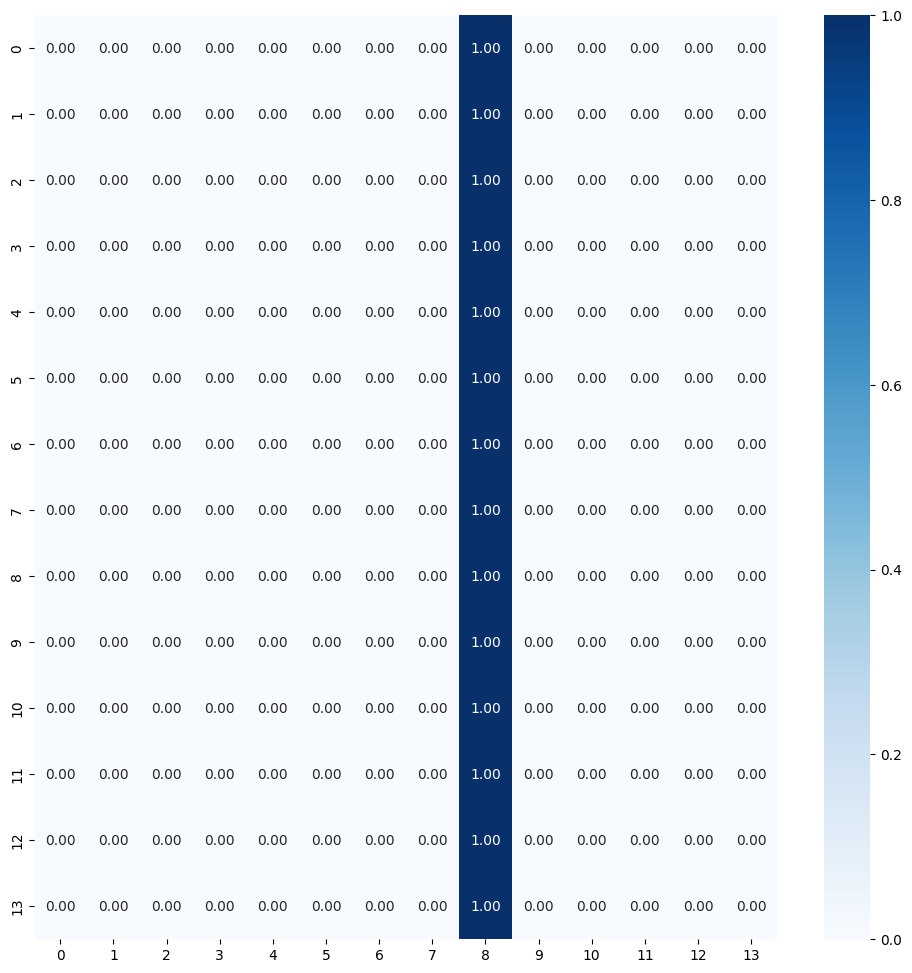

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.07320698201656342
Average validation precision in 5-fold: 0.07174745202064514
/nTest Metrics
test_acc_list: [0.0714285746216774, 0.0714285746216774, 0.0714285746216774, 0.0714285746216774, 0.0714285746216774]
Average Test Accuracy with 5-fold: 0.0714285746216774
test_loss_list: [2.6390740871429443, 2.6390762329101562, 2.6390700340270996, 2.639061450958252, 2.6390624046325684]
Average Test Log Loss with 5-fold: 2.639068841934204

Precision List: [0.00510204081632653, 0.00510204081632653, 0.00510204081632653, 0.00510204081632653, 0.00510204081632653]
Average Precision List with 5-fold: 0.00510204081632653
Recall List: [0.07142857142857142, 0.07142857142857142, 0.07142857142857142, 0.07142857142857142, 0.07142857142857142]
Average Recall List with 5-fold: 0.07142857142857142
F1 Score List: [0.009523809523809523, 0.009523809523809523, 0.009523809523809523, 0.009523809523809523, 0.009523809523809523]
Average F1 Score List with 5-fold: 0.009523809523809

In [22]:
%%time

num_classes = 14
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, precision_list_all, 
    recall_list_all, f1_score_list_all)

Familias de malware copiadas
source2: /notebooks/train3/all_malware/15
name_save_model: fusion_VGG16_basic_15
Found 15750 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Found 3375 images belonging to 15 classes.
Lista de clases de malware a ser analizadas:
- sfone
- sillyp2p
- Allaple.A
- Ramnit
- wabot
- mira
- Kelihos_ver3
- ganelp
- Allaple.L
- wacatac
- dinwod
- Lollipop
- berbew
- small
- upatre

TRAINING AND EVALUATING FOLD 1/5...

Total params: 3763407
Trainable params: 2121743
Non-trainable params: 1641664
Epoch 1/50
492/492 [==============================] - 86s 154ms/step - loss: 5.1991 - accuracy: 0.0625 - val_loss: 3.1639 - val_accuracy: 0.0667
Epoch 2/50
492/492 [==============================] - 80s 162ms/step - loss: 2.8397 - accuracy: 0.0630 - val_loss: 2.7194 - val_accuracy: 0.0664
Epoch 3/50
492/492 [==============================] - 78s 159ms/step - loss: 2.7107 - accuracy: 0.0620 - val_loss: 2.7081 - val_accuracy: 0.0664
Epoch 4/50
492/49

Model and History saved...
493/493 [==============================] - 60s 121ms/step - loss: 2.7081 - accuracy: 0.0667
Train Accuracy: 0.06666667014360428
Train Log Loss: 2.7080585956573486
106/106 [==============================] - 16s 148ms/step - loss: 2.7081 - accuracy: 0.0667
Validation Accuracy: 0.06666667014360428
Validation Log Loss: 2.708059787750244
106/106 [==============================] - 15s 137ms/step - loss: 2.7081 - accuracy: 0.0667
Test Accuracy: 0.06666667014360428
Test Log Loss: 2.708059787750244
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[  0   0   0   0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


106/106 [==============================] - 15s 131ms/step


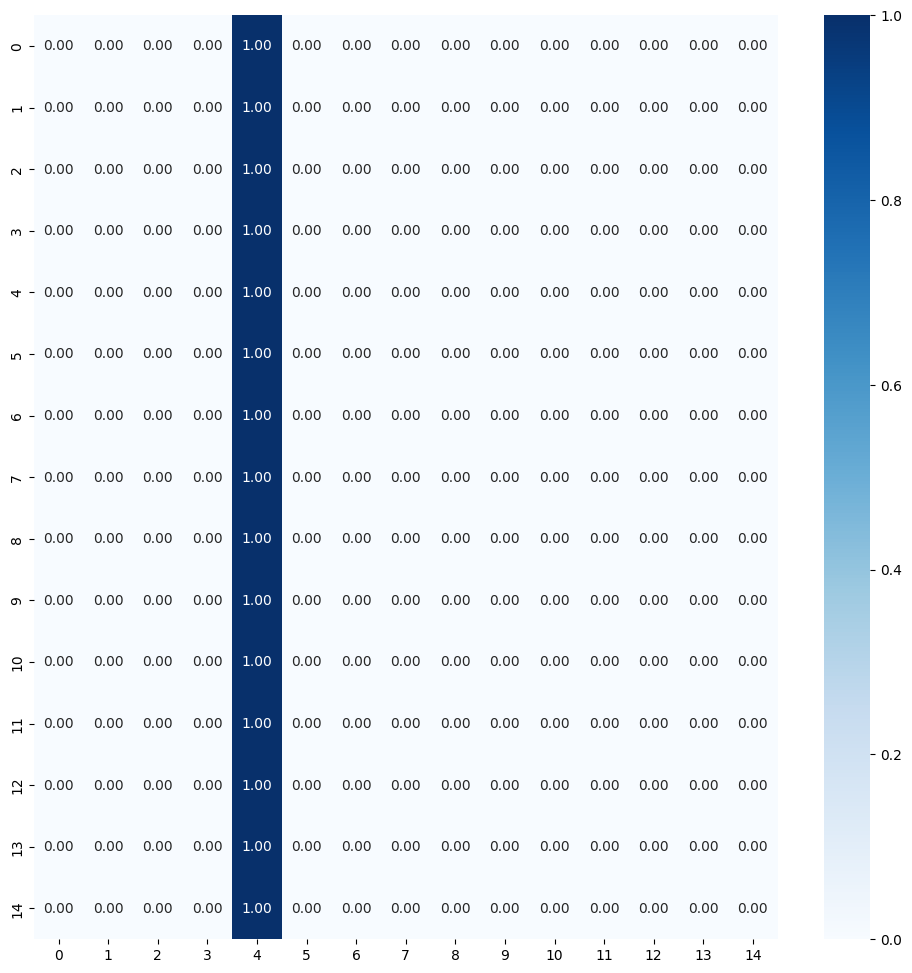

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 2/5...

Total params: 3763407
Trainable params: 2121743
Non-trainable params: 1641664
Epoch 1/50
492/492 [==============================] - 82s 149ms/step - loss: 5.1991 - accuracy: 0.0620 - val_loss: 3.1646 - val_accuracy: 0.0661
Epoch 2/50
492/492 [==============================] - 80s 163ms/step - loss: 2.8398 - accuracy: 0.0644 - val_loss: 2.7195 - val_accuracy: 0.0667
Epoch 3/50
492/492 [==============================] - 72s 146ms/step - loss: 2.7107 - accuracy: 0.0644 - val_loss: 2.7081 - val_accuracy: 0.0667
Epoch 4/50
492/492 [==============================] - 79s 161ms/step - loss: 2.7082 - accuracy: 0.0655 - val_loss: 2.7081 - val_accuracy: 0.0667
Epoch 5/50
492/492 [==============================] - 71s 145ms/step - loss: 2.7083 - accuracy: 0.0647 - val_loss: 2.7081 - val_accuracy: 0.0664
Epoch 6/50
492/492 [==============================] - 78s 159ms/step - loss: 2.7083 - accuracy: 0.0640 - val_loss: 2.7081 - val_accuracy: 0.0670
Epoch 7/50
492

Model and History saved...
493/493 [==============================] - 54s 110ms/step - loss: 2.7081 - accuracy: 0.0667
Train Accuracy: 0.06666667014360428
Train Log Loss: 2.708055019378662
106/106 [==============================] - 14s 127ms/step - loss: 2.7081 - accuracy: 0.0667
Validation Accuracy: 0.06666667014360428
Validation Log Loss: 2.7080557346343994
106/106 [==============================] - 13s 125ms/step - loss: 2.7081 - accuracy: 0.0667
Test Accuracy: 0.06666667014360428
Test Log Loss: 2.7080554962158203
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[  0   0   0   0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 225   0   0   0   0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


106/106 [==============================] - 15s 128ms/step


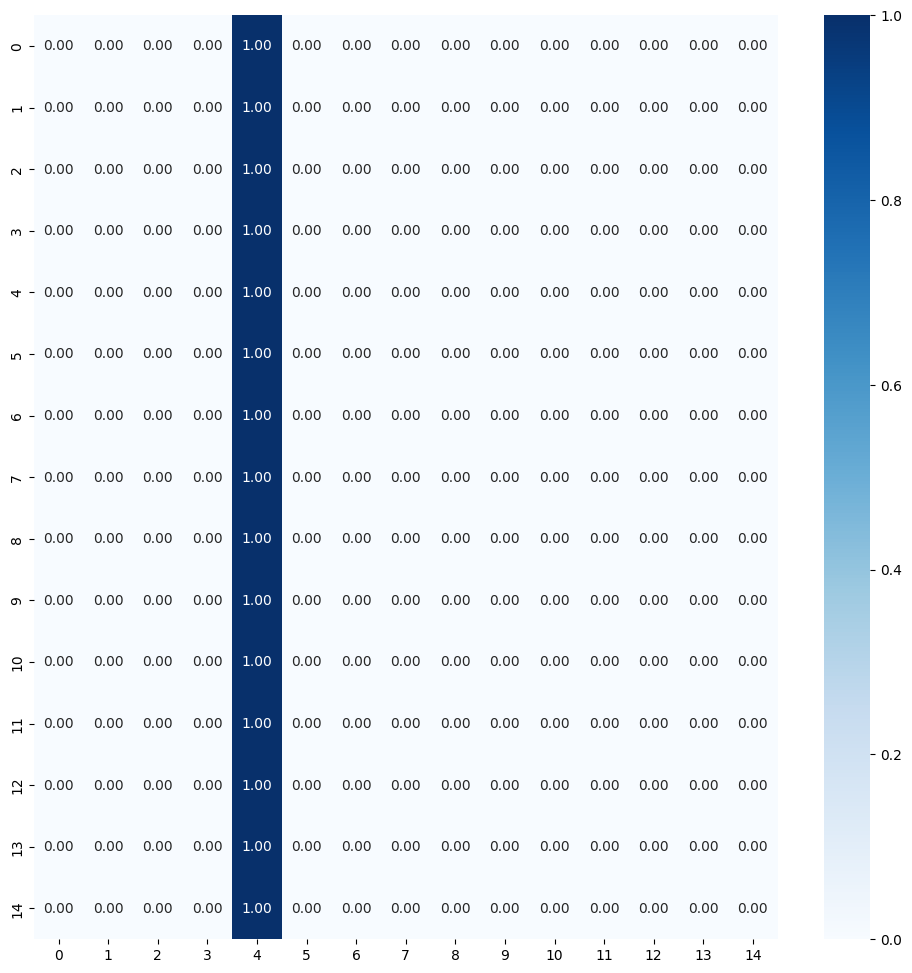

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 3/5...

Total params: 3763407
Trainable params: 2121743
Non-trainable params: 1641664
Epoch 1/50
492/492 [==============================] - 83s 150ms/step - loss: 5.2012 - accuracy: 0.0651 - val_loss: 3.1652 - val_accuracy: 0.0670
Epoch 2/50
492/492 [==============================] - 74s 150ms/step - loss: 2.8395 - accuracy: 0.0626 - val_loss: 2.7195 - val_accuracy: 0.0667
Epoch 3/50
492/492 [==============================] - 72s 146ms/step - loss: 2.7108 - accuracy: 0.0645 - val_loss: 2.7081 - val_accuracy: 0.0667
Epoch 4/50
492/492 [==============================] - 68s 138ms/step - loss: 2.7083 - accuracy: 0.0665 - val_loss: 2.7081 - val_accuracy: 0.0661
Epoch 5/50
492/492 [==============================] - 72s 147ms/step - loss: 2.7084 - accuracy: 0.0643 - val_loss: 2.7081 - val_accuracy: 0.0664
Epoch 6/50
492/492 [==============================] - 73s 148ms/step - loss: 2.7083 - accuracy: 0.0609 - val_loss: 2.7081 - val_accuracy: 0.0667
Epoch 7/50
492

Model and History saved...
493/493 [==============================] - 73s 148ms/step - loss: 2.7081 - accuracy: 0.0667
Train Accuracy: 0.06666667014360428
Train Log Loss: 2.708057403564453
106/106 [==============================] - 16s 148ms/step - loss: 2.7081 - accuracy: 0.0667
Validation Accuracy: 0.06666667014360428
Validation Log Loss: 2.7080581188201904
106/106 [==============================] - 16s 150ms/step - loss: 2.7081 - accuracy: 0.0667
Test Accuracy: 0.06666667014360428
Test Log Loss: 2.7080578804016113
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 225   0   0]
 [  0   0   0   0   0   0   0   0   0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


106/106 [==============================] - 15s 135ms/step


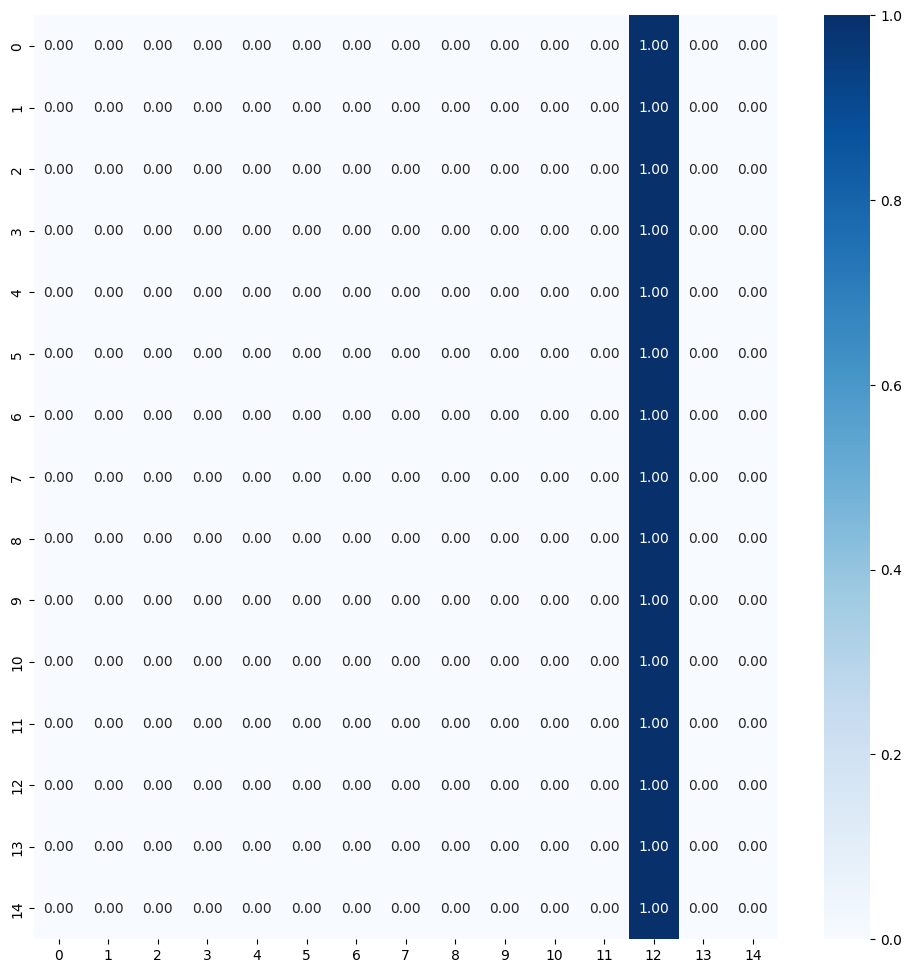

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 4/5...

Total params: 3763407
Trainable params: 2121743
Non-trainable params: 1641664
Epoch 1/50
492/492 [==============================] - 101s 185ms/step - loss: 5.2056 - accuracy: 0.0632 - val_loss: 3.1656 - val_accuracy: 0.0667
Epoch 2/50
492/492 [==============================] - 88s 179ms/step - loss: 2.8402 - accuracy: 0.0592 - val_loss: 2.7195 - val_accuracy: 0.0667
Epoch 3/50
492/492 [==============================] - 79s 161ms/step - loss: 2.7107 - accuracy: 0.0655 - val_loss: 2.7081 - val_accuracy: 0.0664
Epoch 4/50
492/492 [==============================] - 89s 180ms/step - loss: 2.7083 - accuracy: 0.0644 - val_loss: 2.7081 - val_accuracy: 0.0670
Epoch 5/50
492/492 [==============================] - 78s 159ms/step - loss: 2.7083 - accuracy: 0.0635 - val_loss: 2.7081 - val_accuracy: 0.0664
Epoch 6/50
492/492 [==============================] - 88s 179ms/step - loss: 2.7083 - accuracy: 0.0616 - val_loss: 2.7081 - val_accuracy: 0.0670
Epoch 7/50
49

Model and History saved...
493/493 [==============================] - 66s 133ms/step - loss: 2.7081 - accuracy: 0.0667
Train Accuracy: 0.06666667014360428
Train Log Loss: 2.7080609798431396
106/106 [==============================] - 14s 134ms/step - loss: 2.7081 - accuracy: 0.0667
Validation Accuracy: 0.06666667014360428
Validation Log Loss: 2.7080607414245605
106/106 [==============================] - 15s 137ms/step - loss: 2.7081 - accuracy: 0.0667
Test Accuracy: 0.06666667014360428
Test Log Loss: 2.708061695098877
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 225]
 [  0   0   0   0   0   0   0   0   0   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


106/106 [==============================] - 10s 89ms/step


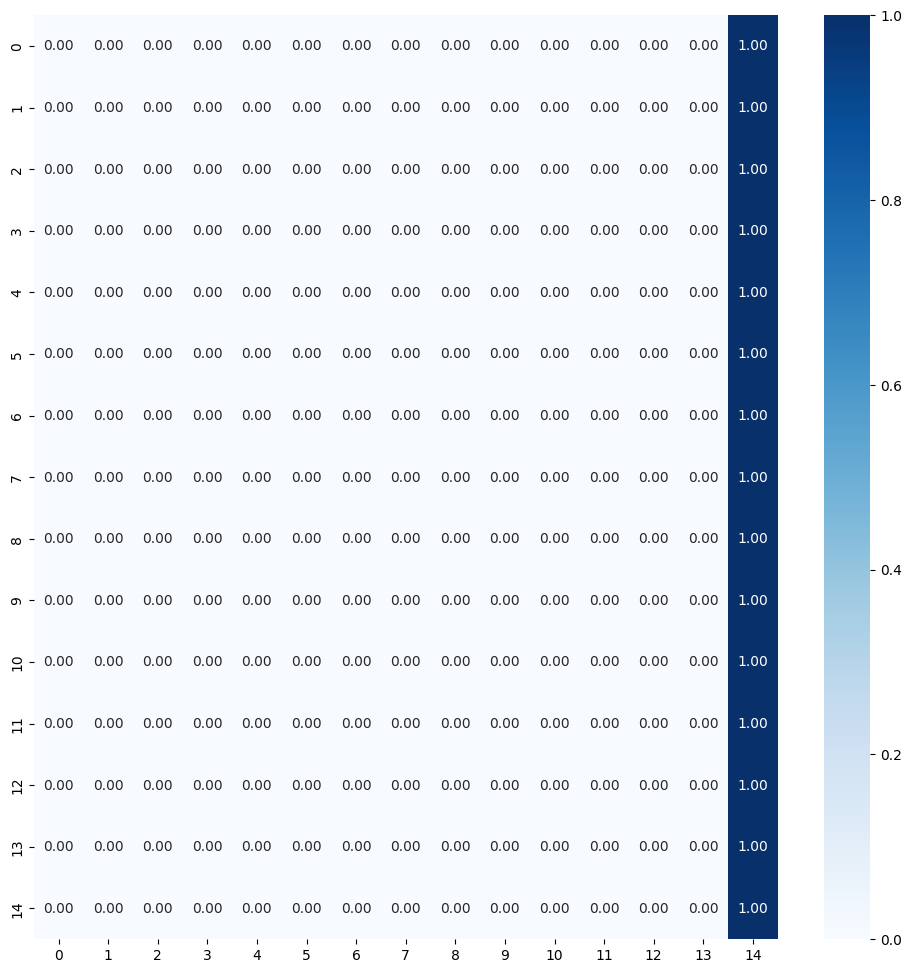

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



TRAINING AND EVALUATING FOLD 5/5...

Total params: 3763407
Trainable params: 2121743
Non-trainable params: 1641664
Epoch 1/50
492/492 [==============================] - 89s 169ms/step - loss: 5.1963 - accuracy: 0.0632 - val_loss: 3.1633 - val_accuracy: 0.0667
Epoch 2/50
492/492 [==============================] - 80s 163ms/step - loss: 2.8394 - accuracy: 0.0620 - val_loss: 2.7194 - val_accuracy: 0.0667
Epoch 3/50
492/492 [==============================] - 72s 147ms/step - loss: 2.7107 - accuracy: 0.0662 - val_loss: 2.7081 - val_accuracy: 0.0670
Epoch 4/50
492/492 [==============================] - 82s 166ms/step - loss: 2.7083 - accuracy: 0.0669 - val_loss: 2.7081 - val_accuracy: 0.0667
Epoch 5/50
492/492 [==============================] - 77s 156ms/step - loss: 2.7083 - accuracy: 0.0625 - val_loss: 2.7081 - val_accuracy: 0.0667
Epoch 6/50
492/492 [==============================] - 84s 170ms/step - loss: 2.7082 - accuracy: 0.0674 - val_loss: 2.7081 - val_accuracy: 0.0667
Epoch 7/50
492

Model and History saved...
493/493 [==============================] - 58s 118ms/step - loss: 2.7081 - accuracy: 0.0667
Train Accuracy: 0.06666667014360428
Train Log Loss: 2.7080626487731934
106/106 [==============================] - 11s 107ms/step - loss: 2.7081 - accuracy: 0.0667
Validation Accuracy: 0.06666667014360428
Validation Log Loss: 2.7080628871917725
106/106 [==============================] - 13s 125ms/step - loss: 2.7081 - accuracy: 0.0667
Test Accuracy: 0.06666667014360428
Test Log Loss: 2.7080636024475098
Test labels: {'Allaple.A': 0, 'Allaple.L': 1, 'Kelihos_ver3': 2, 'Lollipop': 3, 'Ramnit': 4, 'berbew': 5, 'dinwod': 6, 'ganelp': 7, 'mira': 8, 'sfone': 9, 'sillyp2p': 10, 'small': 11, 'upatre': 12, 'wabot': 13, 'wacatac': 14}

Matriz de Confusión:
[[  0   0   0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 225   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


106/106 [==============================] - 15s 125ms/step


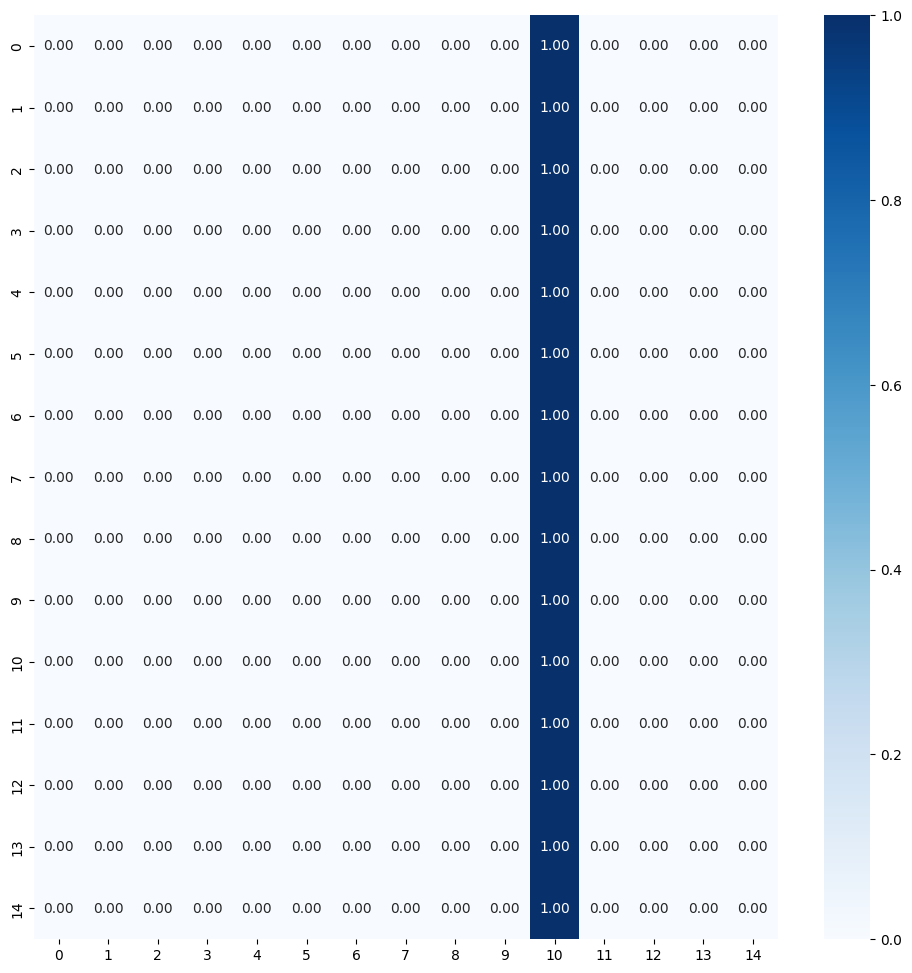

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Average training accuracy in 5-fold: 0.06778216063976288
Average validation precision in 5-fold: 0.0669642835855484
/nTest Metrics
test_acc_list: [0.06666667014360428, 0.06666667014360428, 0.06666667014360428, 0.06666667014360428, 0.06666667014360428]
Average Test Accuracy with 5-fold: 0.06666667014360428
test_loss_list: [2.708059787750244, 2.7080554962158203, 2.7080578804016113, 2.708061695098877, 2.7080636024475098]
Average Test Log Loss with 5-fold: 2.7080596923828124

Precision List: [0.0044444444444444444, 0.0044444444444444444, 0.0044444444444444444, 0.0044444444444444444, 0.0044444444444444444]
Average Precision List with 5-fold: 0.0044444444444444444
Recall List: [0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667, 0.06666666666666667]
Average Recall List with 5-fold: 0.06666666666666667
F1 Score List: [0.008333333333333333, 0.008333333333333333, 0.008333333333333333, 0.008333333333333333, 0.008333333333333333]
Average F1 Score List with 5-fold: 

In [23]:
%%time

num_classes = 15
test_acc_list_all, test_loss_list_all, precision_list_all, recall_list_all, f1_score_list_all = exp(
    num_classes, nombre_modelo, source, save_model, test_acc_list_all, test_loss_list_all, 
    precision_list_all, recall_list_all, f1_score_list_all)

In [24]:
print(f"test_acc_list_all = {test_acc_list_all}")
print(f"test_loss_list_all = {test_loss_list_all}")
print(f"precision_list_all = {precision_list_all}")
print(f"recall_list_all = {recall_list_all}")
print(f"f1_score_list_all = {f1_score_list_all}")

test_acc_list_all = [0.5, 0.3333333432674408, 0.25, 0.20000000298023224, 0.1666666716337204, 0.1428571492433548, 0.125, 0.1111111119389534, 0.10000000149011612, 0.09090909361839294, 0.0833333358168602, 0.07692307978868484, 0.0714285746216774, 0.06666667014360428]
test_loss_list_all = [0.6931522369384766, 1.098618984222412, 1.3862980842590331, 1.609458827972412, 1.7917638540267944, 1.9459159135818482, 2.07944974899292, 2.1972311973571776, 2.3025933265686036, 2.397904872894287, 2.484914493560791, 2.5649610996246337, 2.639068841934204, 2.7080596923828124]
precision_list_all = [0.25, 0.11111111111111112, 0.0625, 0.04, 0.02777777777777778, 0.02040816326530612, 0.015625, 0.012345679012345678, 0.01, 0.008264462809917356, 0.006944444444444445, 0.00591715976331361, 0.00510204081632653, 0.0044444444444444444]
recall_list_all = [0.5, 0.3333333333333333, 0.25, 0.2, 0.16666666666666666, 0.14285714285714285, 0.125, 0.11111111111111112, 0.1, 0.09090909090909091, 0.08333333333333333, 0.076923076923076

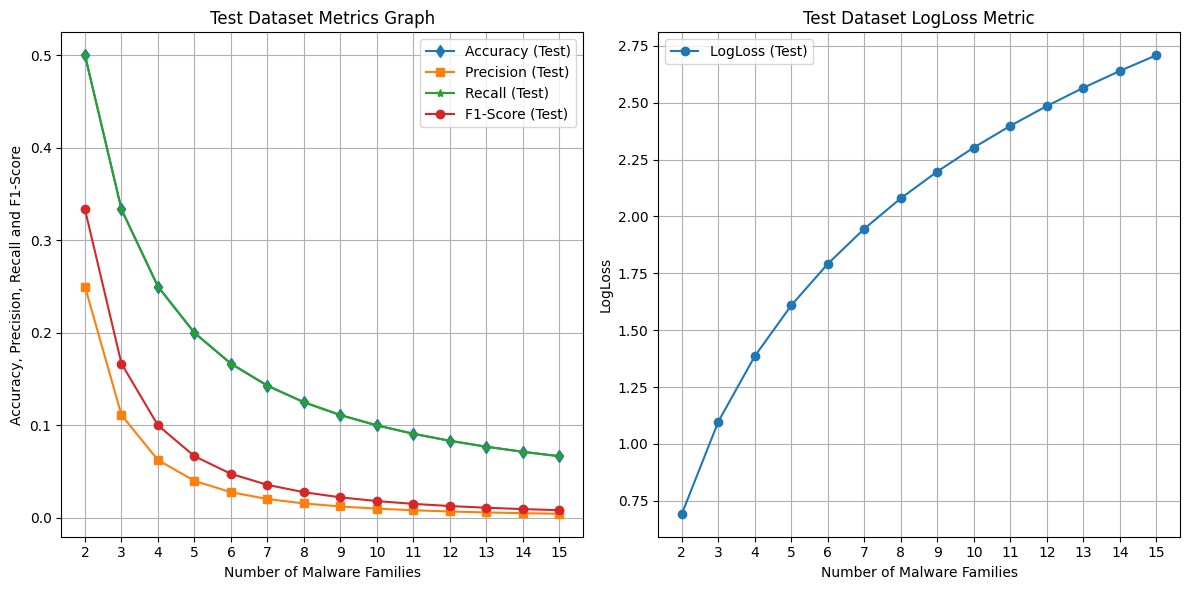

In [25]:
import matplotlib.pyplot as plt

# Datos históricos
strategies = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]

# Crear gráfico para Test Accuracy y Test LogLoss en una fila con dos columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico para Test Accuracy, Precision, Recall and F1-Score
axes[0].plot(strategies, test_acc_list_all, marker='d', label='Accuracy (Test)')
axes[0].plot(strategies, precision_list_all, marker='s', label='Precision (Test)')
axes[0].plot(strategies, recall_list_all, marker='*', label='Recall (Test)')
axes[0].plot(strategies, f1_score_list_all, marker='o', label='F1-Score (Test)')
axes[0].set_title('Test Dataset Metrics Graph')
axes[0].set_xlabel('Number of Malware Families')
axes[0].set_ylabel('Accuracy, Precision, Recall and F1-Score')
axes[0].legend()
axes[0].grid(True)

# Gráfico para Test LogLoss
axes[1].plot(strategies, test_loss_list_all, marker='o', label='LogLoss (Test)')
axes[1].set_title('Test Dataset LogLoss Metric')
axes[1].set_xlabel('Number of Malware Families')
axes[1].set_ylabel('LogLoss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
